In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_cleaned.csv")

print("Shape:", df.shape)
df.head()

Shape: (7155, 70)


,order_line_id,order_id,order_date,customer_id,customer_name,customer_segment,region,city_tier,channel,product_id,...,customer_orders,customer_revenue,customer_profit,customer_return_rate,customer_avg_rating,order_revenue,order_profit,order_lines,order_quantity,order_return_flag
0,LINE0000001,ORD000001,2025-05-21,CUST00001,Ayaan Sharma,At-Risk,East,Tier 2,Website,P020,...,4,210322.91,34832.98,0.0,5.0000,21530.08,6765.54,1,4,0
1,LINE0000002,ORD000002,2025-04-14,CUST00002,Aditya Sharma,Returning,North,Tier 1,Website,P016,...,12,583775.75,141180.10,0.0,4.1000,3971.10,827.22,1,1,0
2,LINE0000003,ORD000003,2025-08-08,CUST00003,Amit Chopra,New,North,Tier 2,Website,P016,...,3,72340.80,22355.04,0.0,4.7500,4890.56,1934.46,1,1,0
3,LINE0000004,ORD000004,2025-07-31,CUST00004,Reyansh Gupta,Returning,West,Tier 3,Mobile App,P018,...,11,338613.95,57294.91,0.0,4.0625,19886.98,6831.20,3,5,0
4,LINE0000005,ORD000004,2025-07-31,CUST00004,Reyansh Gupta,Returning,West,Tier 3,Mobile App,P017,...,11,338613.95,57294.91,0.0,4.0625,19886.98,6831.20,3,5,0


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,7155.0,1.948567,1.148170,1.000000,1.000000,2.000000,3.000000,8.000000e+00
unit_price,7155.0,14020.975542,19585.489107,1840.000000,4420.000000,6320.000000,13270.000000,1.025900e+05
gross_sales,7155.0,21438.125786,27342.185469,1840.000000,5880.000000,12750.000000,25305.000000,6.865600e+05
discount_pct,7155.0,0.100493,0.033426,0.050000,0.075000,0.094000,0.125000,2.000000e-01
discount_amount,7155.0,2150.914046,2937.100571,96.390000,577.880000,1208.880000,2550.495000,5.767104e+04
net_revenue,7155.0,19287.211740,24672.612362,1516.570000,5353.110000,11482.240000,22869.215000,6.288890e+05
product_cost,7155.0,14021.132075,20147.644241,900.000000,3500.000000,7000.000000,14400.000000,5.040000e+05
shipping_cost,7155.0,103.843481,57.357132,1.600000,52.435000,110.410000,147.535000,6.572400e+02
delivery_days,7155.0,3.687072,1.283557,2.000000,3.000000,4.000000,4.000000,8.000000e+00
delivery_delay,7155.0,0.058700,0.235079,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [3]:
total_revenue = df["net_revenue"].sum()
total_profit = df["profit"].sum()
total_cost = df["total_cost"].sum()

orders = df["order_id"].nunique()
customers = df["customer_id"].nunique()
order_lines = df["order_line_id"].nunique()

total_quantity = df["quantity"].sum()

avg_order_value = total_revenue / orders
avg_customer_value = total_revenue / customers
overall_margin = total_profit / total_revenue

In [4]:
print("========== BUSINESS KPIs ==========")

print("Revenue:", round(total_revenue, 2))
print("Profit:", round(total_profit, 2))
print("Total Cost:", round(total_cost, 2))
print("Orders:", orders)
print("Customers:", customers)
print("Order Lines:", order_lines)
print("Quantity Sold:", total_quantity)
print("Average Order Value:", round(avg_order_value, 2))
print("Revenue per Customer:", round(avg_customer_value, 2))
print("Profit Margin:", round(overall_margin * 100, 2), "%")

========== BUSINESS KPIs ==========
Revenue: 138000000.0
Profit: 32904667.71
Total Cost: 105095332.29
Orders: 4312
Customers: 2580
Order Lines: 7155
Quantity Sold: 13942
Average Order Value: 32003.71
Revenue per Customer: 53488.37
Profit Margin: 23.84 %


In [5]:
monthly = (
    df.groupby(["year", "month"])
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique")
      )
      .reset_index()
)

monthly["month_name"] = pd.to_datetime(
    monthly["month"], format="%m"
).dt.month_name().str[:3]

monthly

,year,month,revenue,profit,orders,customers,month_name
0,2025,1,11450100.30,2838490.12,333,305,Jan
1,2025,2,10038555.36,2603621.17,327,300,Feb
2,2025,3,11837540.56,3047353.38,341,317,Mar
3,2025,4,13046278.03,3306142.72,369,344,Apr
4,2025,5,11373592.68,2971110.44,380,355,May
5,2025,6,13789319.22,3479493.31,432,393,Jun
6,2025,7,12762732.89,3310707.32,383,347,Jul
7,2025,8,11919421.15,3062705.27,398,367,Aug
8,2025,9,13966721.99,3049328.59,381,349,Sep
9,2025,10,9632123.96,1949367.73,341,316,Oct


In [6]:
monthly["month_date"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" +
    monthly["month"].astype(str) + "-01"
)

monthly = monthly.sort_values("month_date")

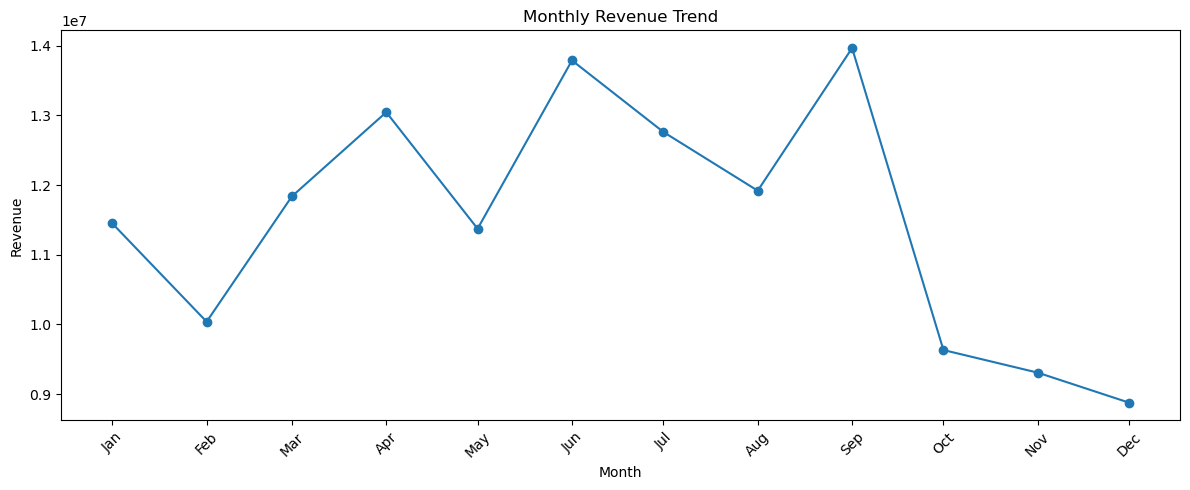

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly["month_date"],
    monthly["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(
    monthly["month_date"],
    monthly["month_name"],
    rotation=45
)

plt.tight_layout()
plt.show()

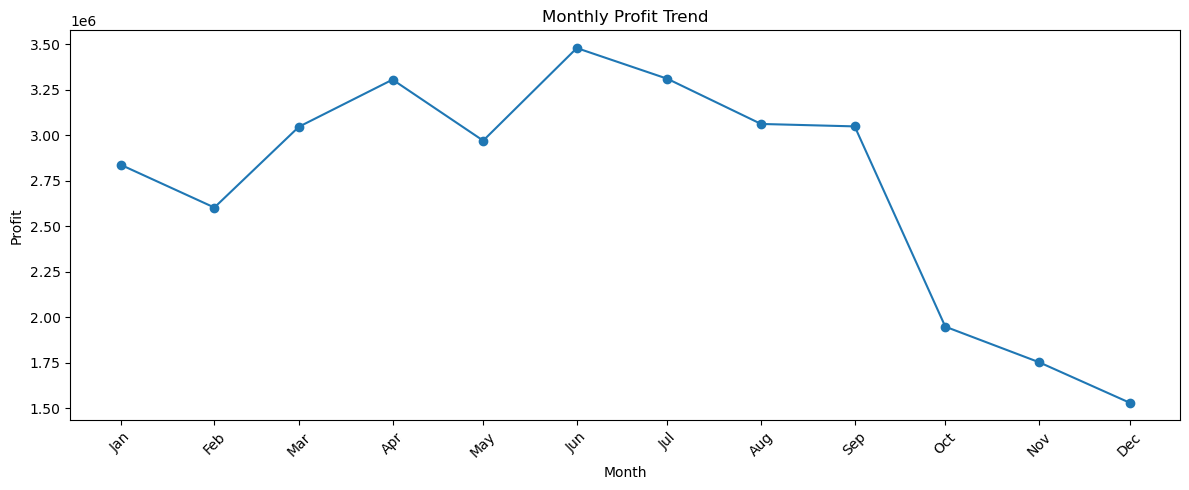

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly["month_date"],
    monthly["profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(
    monthly["month_date"],
    monthly["month_name"],
    rotation=45
)

plt.tight_layout()
plt.show()

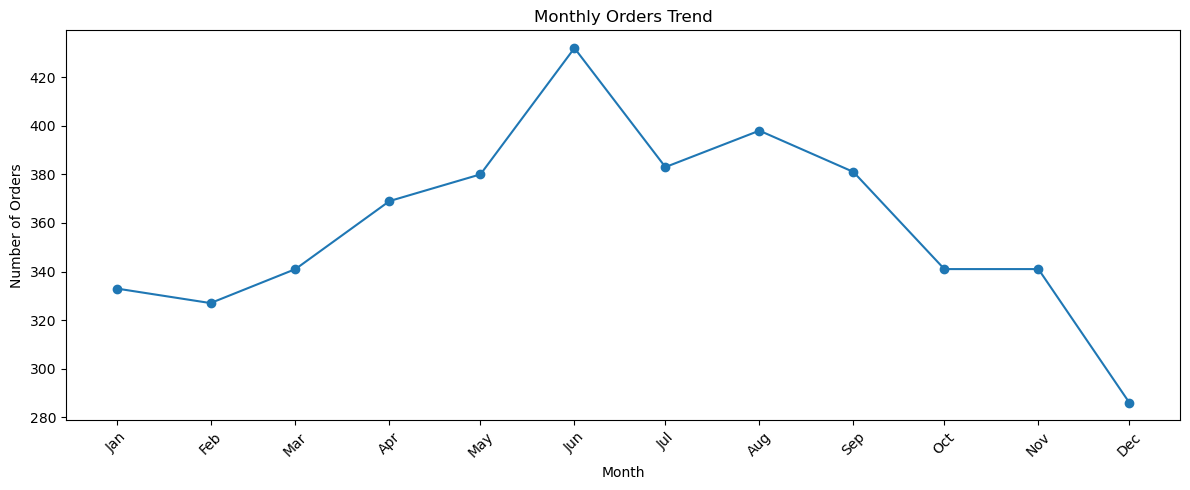

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly["month_date"],
    monthly["orders"],
    marker="o"
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(
    monthly["month_date"],
    monthly["month_name"],
    rotation=45
)

plt.tight_layout()
plt.show()

In [10]:
category_analysis = (
    df.groupby("category")
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum"),
          avg_discount=("discount_pct", "mean"),
          return_rate=("return_flag", "mean")
      )
      .reset_index()
)

category_analysis["return_rate"] *= 100

category_analysis = category_analysis.sort_values(
    "revenue",
    ascending=False
)

category_analysis

,category,revenue,profit,orders,quantity,avg_discount,return_rate
0,Accessories,49780180.43,16249801.86,3103,9592,0.101642,0.0
2,Electronics,30941582.25,4751672.87,415,505,0.102671,0.0
1,Computing,28870819.04,7631267.05,1713,3173,0.097887,0.0
3,Mobile,28407418.28,4271925.93,557,672,0.099375,0.0


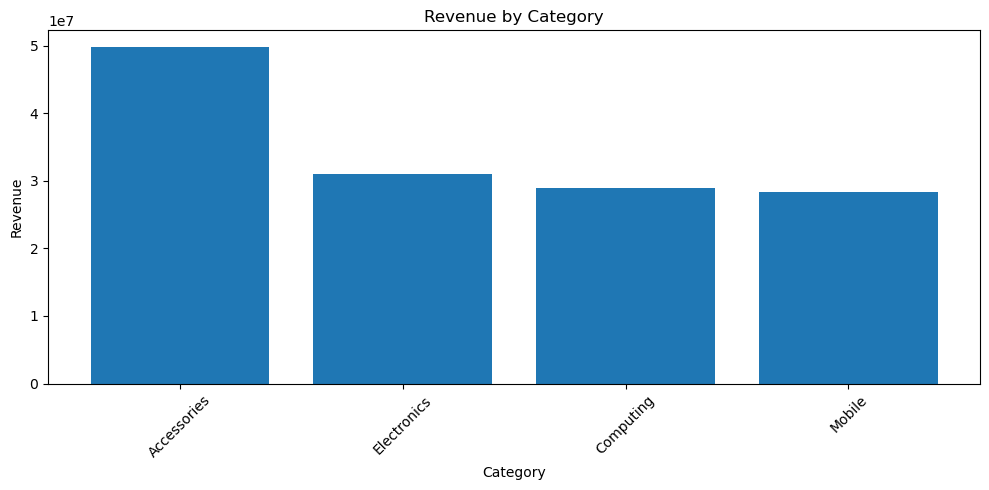

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_analysis["category"],
    category_analysis["revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
product_analysis = (
    df.groupby(["product_id", "product_name"])
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          quantity=("quantity", "sum"),
          orders=("order_id", "nunique"),
          avg_discount=("discount_pct", "mean"),
          return_rate=("return_flag", "mean"),
          avg_rating=("customer_rating", "mean")
      )
      .reset_index()
)

product_analysis["return_rate"] *= 100

product_analysis.sort_values(
    "revenue",
    ascending=False
).head(10)

,product_id,product_name,revenue,profit,quantity,orders,avg_discount,return_rate,avg_rating
17,P018,Smart Watch,15261949.34,4908245.13,1409,599,0.097982,0.0,4.068581
10,P011,Monitor 27,12268934.76,2818457.73,645,394,0.096866,0.0,4.095122
2,P003,Gaming Laptop,12126491.54,1428363.50,143,114,0.113198,0.0,3.956897
8,P009,Phone Ultra,11519757.22,1580023.05,177,150,0.100623,0.0,4.066667
15,P016,Wireless Earbuds,10732698.31,3549847.64,2408,944,0.110982,0.0,3.769971
14,P015,Headphones,10141992.65,3037430.68,1406,602,0.100380,0.0,4.091054
9,P010,Monitor 24,9000286.92,2263686.05,714,432,0.099868,0.0,4.065760
19,P020,Webcam,7614695.92,2423845.55,1404,588,0.096413,0.0,4.014682
7,P008,Phone Pro,7566150.88,1057799.96,153,131,0.096977,0.0,4.045455
0,P001,Laptop Pro 14,7024569.88,1171213.94,91,71,0.094452,0.0,4.013699


In [13]:
product_analysis.sort_values(
    "profit"
).head(10)

,product_id,product_name,revenue,profit,quantity,orders,avg_discount,return_rate,avg_rating
3,P004,Tablet X,2519572.89,522881.50,87,72,0.099556,0.0,3.888889
12,P013,Mouse Pro,1365733.11,571544.25,607,354,0.097722,0.0,4.061111
5,P006,Phone A,3753008.99,633674.65,166,143,0.099731,0.0,4.179310
4,P005,Tablet Pro,3680048.15,702160.54,92,82,0.105988,0.0,4.012048
11,P012,Keyboard Pro,2517795.39,868166.96,619,373,0.096910,0.0,4.208443
1,P002,Laptop Air 13,5590899.79,927053.39,92,84,0.094667,0.0,4.059524
6,P007,Phone B,5568501.19,1000428.27,176,149,0.099888,0.0,4.065789
7,P008,Phone Pro,7566150.88,1057799.96,153,131,0.096977,0.0,4.045455
13,P014,Ssd 1Tb,3718068.86,1109412.06,588,359,0.097817,0.0,4.090164
16,P017,Power Bank,3385697.47,1124330.31,1504,646,0.099509,0.0,4.131268


In [14]:
region_analysis = (
    df.groupby("region")
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          shipping_cost=("shipping_cost", "sum"),
          avg_delivery_days=("delivery_days", "mean"),
          return_rate=("return_flag", "mean"),
          avg_rating=("customer_rating", "mean")
      )
      .reset_index()
)

region_analysis["return_rate"] *= 100

region_analysis

,region,revenue,profit,orders,shipping_cost,avg_delivery_days,return_rate,avg_rating
0,East,31458350.87,7320442.54,956,177819.62,4.011292,0.0,4.168758
1,North,40309143.05,9570681.83,1232,184215.63,3.013069,0.0,4.106486
2,South,30672204.13,7469100.37,1019,162812.33,2.989808,0.0,4.151079
3,West,35560301.95,8544442.97,1105,218152.53,4.802956,0.0,3.712096


In [15]:
region_analysis.sort_values(
    "shipping_cost",
    ascending=False
)

,region,revenue,profit,orders,shipping_cost,avg_delivery_days,return_rate,avg_rating
3,West,35560301.95,8544442.97,1105,218152.53,4.802956,0.0,3.712096
1,North,40309143.05,9570681.83,1232,184215.63,3.013069,0.0,4.106486
0,East,31458350.87,7320442.54,956,177819.62,4.011292,0.0,4.168758
2,South,30672204.13,7469100.37,1019,162812.33,2.989808,0.0,4.151079


In [16]:
channel_analysis = (
    df.groupby("channel")
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          payment_failures=("payment_failure_flag", "sum"),
          return_rate=("return_flag", "mean")
      )
      .reset_index()
)

channel_analysis["return_rate"] *= 100

channel_analysis

,channel,revenue,profit,orders,payment_failures,return_rate
0,Marketplace,29200955.83,6987416.49,926,27,0.0
1,Mobile App,48718122.91,11514684.55,1522,85,0.0
2,Website,60080921.26,14402566.67,1864,55,0.0


In [17]:
discount_analysis = (
    df.groupby("discount_pct")
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique")
      )
      .reset_index()
      .sort_values("discount_pct")
)



df["discount_band"] = pd.cut(
    df["discount_pct"],
    bins=[-0.01, 0.05, 0.10, 0.15, 0.20, 1],
    labels=[
        "0-5%",
        "5-10%",
        "10-15%",
        "15-20%",
        "20%+"
    ]
)




discount_band_analysis = (
    df.groupby("discount_band", observed=True)
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          avg_margin=("profit_margin", "mean")
      )
      .reset_index()
)

discount_band_analysis

,discount_band,revenue,profit,orders,avg_margin
0,0-5%,710362.50,204097.78,40,0.344470
1,5-10%,84593004.15,22139502.73,2879,0.322482
2,10-15%,42940458.89,8929349.11,1826,0.276555
3,15-20%,9756174.46,1631718.09,422,0.240903


In [18]:
return_analysis = (
    df.groupby("return_status")
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum")
      )
      .reset_index()
)



overall_return_rate = df["return_flag"].mean() * 100

print(
    "Overall Return Rate:",
    round(overall_return_rate, 2),
    "%"
)




df[df["return_flag"] == 1]["return_reason"].value_counts()

Overall Return Rate: 0.0 %


Series([], Name: count, dtype: int64)

In [19]:
shipping_analysis = (
    df.groupby("region")
      .agg(
          revenue=("net_revenue", "sum"),
          shipping_cost=("shipping_cost", "sum"),
          avg_shipping=("shipping_cost", "mean"),
          avg_delivery_days=("delivery_days", "mean"),
          delay_rate=("delivery_delay_flag", "mean")
      )
      .reset_index()
)

shipping_analysis["delay_rate"] *= 100

shipping_analysis

,region,revenue,shipping_cost,avg_shipping,avg_delivery_days,delay_rate
0,East,31458350.87,177819.62,111.555596,4.011292,0.000000
1,North,40309143.05,184215.63,89.165358,3.013069,0.000000
2,South,30672204.13,162812.33,97.609311,2.989808,0.000000
3,West,35560301.95,218152.53,119.404778,4.802956,22.988506


In [20]:
payment_analysis = (
    df.groupby(["channel", "payment_method"])
      .agg(
          attempts=("payment_attempted", "sum"),
          failures=("payment_failed", "sum")
      )
      .reset_index()
)

payment_analysis["failure_rate"] = (
    payment_analysis["failures"] /
    payment_analysis["attempts"]
) * 100

payment_analysis.sort_values(
    "failure_rate",
    ascending=False
)

,channel,payment_method,attempts,failures,failure_rate
9,Mobile App,Net Banking,501,28,5.588822
5,Marketplace,Wallet,263,10,3.802281
11,Mobile App,Wallet,367,13,3.542234
8,Mobile App,Debit Card,851,22,2.585194
10,Mobile App,Upi,1771,45,2.540937
17,Website,Wallet,478,12,2.510460
2,Marketplace,Debit Card,537,10,1.862197
7,Mobile App,Credit Card,986,17,1.724138
1,Marketplace,Credit Card,630,10,1.587302
0,Marketplace,Cash On Delivery,319,5,1.567398


In [21]:
marketing_analysis = (
    df.groupby(["marketing_source", "campaign"])
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          ad_spend=("ad_spend", "sum"),
          sessions=("sessions", "sum"),
          orders=("order_id", "nunique")
      )
      .reset_index()
)

In [22]:
marketing_analysis["ROAS"] = (
    marketing_analysis["revenue"] /
    marketing_analysis["ad_spend"].replace(0, np.nan)
)

marketing_analysis.sort_values(
    "ROAS"
).head(10)

,marketing_source,campaign,revenue,profit,ad_spend,sessions,orders,ROAS
19,Unknown,G01,84863.42,21311.55,4325.73,50,7,19.618289
24,Unknown,M03,98126.34,16260.18,4877.00,38,5,20.120226
22,Unknown,M01,64385.65,15875.17,3007.81,46,6,21.406156
23,Unknown,M02,162709.43,38837.45,7258.59,58,8,22.416121
7,Google Ads,Unknown,262541.95,44742.65,11630.60,75,10,22.573380
8,Meta Ads,M01,13640196.65,3131712.21,596887.69,5261,436,22.852200
5,Google Ads,G02,15510633.44,3379459.42,674617.64,5849,473,22.991740
11,Meta Ads,Unknown,429575.10,66513.47,18178.39,82,12,23.631086
4,Google Ads,G01,13934335.98,3202531.92,552759.69,5571,454,25.208669
9,Meta Ads,M02,13702722.06,3086118.04,539169.62,5317,426,25.414492


In [23]:
customer_analysis = (
    df.groupby("customer_id")
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum"),
          return_rate=("return_flag", "mean"),
          avg_rating=("customer_rating", "mean")
      )
      .reset_index()
)

customer_analysis["return_rate"] *= 100

customer_analysis.head()

,customer_id,revenue,profit,orders,quantity,return_rate,avg_rating
0,CUST00001,210322.91,34832.98,4,16,0.0,5.000000
1,CUST00002,583775.75,141180.10,12,36,0.0,4.100000
2,CUST00003,72340.80,22355.04,3,7,0.0,4.750000
3,CUST00004,338613.95,57294.91,11,27,0.0,4.062500
4,CUST00005,593318.45,147803.93,14,56,0.0,4.130435


In [24]:
customer_analysis.sort_values(
    "revenue",
    ascending=False
).head(10)

,customer_id,revenue,profit,orders,quantity,return_rate,avg_rating
13,CUST00014,1059636.93,221828.42,20,74,0.0,4.236842
1104,CUST01105,628888.96,109429.95,1,7,0.0,2.000000
4,CUST00005,593318.45,147803.93,14,56,0.0,4.130435
1,CUST00002,583775.75,141180.10,12,36,0.0,4.100000
261,CUST00262,581398.05,135935.90,1,8,0.0,5.000000
43,CUST00044,553515.55,104757.47,14,45,0.0,4.636364
376,CUST00377,505872.52,124182.16,5,24,0.0,3.777778
236,CUST00237,505484.22,85994.27,7,38,0.0,4.333333
7,CUST00008,494799.68,107433.61,12,42,0.0,4.611111
33,CUST00034,485061.80,86897.52,9,35,0.0,3.187500


In [25]:
numeric_cols = [
    "quantity",
    "unit_price",
    "gross_sales",
    "discount_pct",
    "discount_amount",
    "net_revenue",
    "product_cost",
    "shipping_cost",
    "delivery_days",
    "ad_spend",
    "sessions",
    "product_views",
    "add_to_cart",
    "checkout_started",
    "total_cost",
    "profit",
    "profit_margin",
    "customer_rating",
    "satisfaction_score"
]

corr = df[numeric_cols].corr()

corr["profit"].sort_values()

profit_margin        -0.222574
discount_pct         -0.182811
delivery_days        -0.030175
sessions             -0.014714
checkout_started     -0.012459
add_to_cart          -0.001660
product_views         0.012776
customer_rating       0.040103
satisfaction_score    0.044160
quantity              0.334154
shipping_cost         0.334913
ad_spend              0.467876
unit_price            0.530565
discount_amount       0.635557
total_cost            0.778766
product_cost          0.784276
gross_sales           0.832775
net_revenue           0.847223
profit                1.000000
Name: profit, dtype: float64

In [26]:
# Check actual return values
print(df["return_status"].value_counts(dropna=False))



df["return_flag"] = (
    df["return_status"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("yes")
    .astype(int)
)

print("\nReturn Flag:")
print(df["return_flag"].value_counts())


overall_return_rate = df["return_flag"].mean() * 100

print(f"Overall Return Rate: {overall_return_rate:.2f}%")

return_status
No     6663
Yes     492
Name: count, dtype: int64

Return Flag:
return_flag
0    6663
1     492
Name: count, dtype: int64
Overall Return Rate: 6.88%


In [27]:
# Make sure date is datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Create month
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")

# Monthly aggregation
monthly = (
    df.groupby(["month", "month_name"])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
        quantity=("quantity", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        ad_spend=("ad_spend", "sum"),
        discount=("discount_amount", "sum"),
        returns=("return_flag", "sum"),
        payment_failures=("payment_failed", "sum")
    )
    .reset_index()
    .sort_values("month")
)

monthly["aov"] = monthly["revenue"] / monthly["orders"]

monthly["profit_margin"] = (
    monthly["profit"] / monthly["revenue"] * 100
)

monthly["return_rate"] = (
    monthly["returns"] / monthly["orders"] * 100
)

monthly["payment_failure_rate"] = (
    monthly["payment_failures"] /
    monthly["orders"] * 100
)

monthly["roas"] = (
    monthly["revenue"] / monthly["ad_spend"]
)

monthly

,month,month_name,revenue,profit,orders,customers,quantity,shipping_cost,ad_spend,discount,returns,payment_failures,aov,profit_margin,return_rate,payment_failure_rate,roas
0,1,Jan,11450100.30,2838490.12,333,305,1057,56078.58,294931.60,1047249.70,29,20,34384.685586,24.790090,8.708709,6.006006,38.822901
1,2,Feb,10038555.36,2603621.17,327,300,1081,55282.70,269451.49,943154.64,27,21,30698.946055,25.936214,8.256881,6.422018,37.255520
2,3,Mar,11837540.56,3047353.38,341,317,1129,57888.73,302498.45,1086679.44,31,10,34714.195191,25.743129,9.090909,2.932551,39.132566
3,4,Apr,13046278.03,3306142.72,369,344,1277,62740.40,343494.91,1225121.97,36,18,35355.767019,25.341655,9.756098,4.878049,37.980994
4,5,May,11373592.68,2971110.44,380,355,1176,62217.74,280764.50,1078167.32,28,24,29930.507053,26.122884,7.368421,6.315789,40.509369
5,6,Jun,13789319.22,3479493.31,432,393,1387,72511.08,365914.83,1320040.78,39,28,31919.720417,25.233249,9.027778,6.481481,37.684505
6,7,Jul,12762732.89,3310707.32,383,347,1263,65111.41,348014.16,1173367.11,37,28,33323.062376,25.940426,9.660574,7.310705,36.673028
7,8,Aug,11919421.15,3062705.27,398,367,1257,66501.35,300514.53,1149518.85,39,20,29948.294347,25.695084,9.798995,5.025126,39.663377
8,9,Sep,13966721.99,3049328.59,381,349,1274,69769.23,486824.17,1635018.01,59,17,36658.062966,21.832815,15.485564,4.461942,28.689459
9,10,Oct,9632123.96,1949367.73,341,316,1033,60851.40,352804.83,1400186.04,51,14,28246.697830,20.238192,14.956012,4.105572,27.301565


In [28]:
monthly[
    [
        "month_name",
        "revenue",
        "profit",
        "orders",
        "aov",
        "profit_margin",
        "discount",
        "shipping_cost",
        "return_rate",
        "payment_failure_rate",
        "roas"
    ]
]

,month_name,revenue,profit,orders,aov,profit_margin,discount,shipping_cost,return_rate,payment_failure_rate,roas
0,Jan,11450100.30,2838490.12,333,34384.685586,24.790090,1047249.70,56078.58,8.708709,6.006006,38.822901
1,Feb,10038555.36,2603621.17,327,30698.946055,25.936214,943154.64,55282.70,8.256881,6.422018,37.255520
2,Mar,11837540.56,3047353.38,341,34714.195191,25.743129,1086679.44,57888.73,9.090909,2.932551,39.132566
3,Apr,13046278.03,3306142.72,369,35355.767019,25.341655,1225121.97,62740.40,9.756098,4.878049,37.980994
4,May,11373592.68,2971110.44,380,29930.507053,26.122884,1078167.32,62217.74,7.368421,6.315789,40.509369
5,Jun,13789319.22,3479493.31,432,31919.720417,25.233249,1320040.78,72511.08,9.027778,6.481481,37.684505
6,Jul,12762732.89,3310707.32,383,33323.062376,25.940426,1173367.11,65111.41,9.660574,7.310705,36.673028
7,Aug,11919421.15,3062705.27,398,29948.294347,25.695084,1149518.85,66501.35,9.798995,5.025126,39.663377
8,Sep,13966721.99,3049328.59,381,36658.062966,21.832815,1635018.01,69769.23,15.485564,4.461942,28.689459
9,Oct,9632123.96,1949367.73,341,28246.697830,20.238192,1400186.04,60851.40,14.956012,4.105572,27.301565


In [29]:
monthly["revenue_change_pct"] = (
    monthly["revenue"].pct_change() * 100
)

monthly["profit_change_pct"] = (
    monthly["profit"].pct_change() * 100
)

monthly["orders_change_pct"] = (
    monthly["orders"].pct_change() * 100
)

monthly[
    [
        "month_name",
        "revenue_change_pct",
        "profit_change_pct",
        "orders_change_pct"
    ]
]

,month_name,revenue_change_pct,profit_change_pct,orders_change_pct
0,Jan,NaN,NaN,NaN
1,Feb,-12.327795,-8.274433,-1.801802
2,Mar,17.920758,17.042887,4.281346
3,Apr,10.211052,8.492266,8.211144
4,May,-12.821169,-10.133630,2.981030
5,Jun,21.239784,17.110871,13.684211
6,Jul,-7.444793,-4.850878,-11.342593
7,Aug,-6.607611,-7.490908,3.916449
8,Sep,17.176177,-0.436760,-4.271357
9,Oct,-31.035185,-36.072231,-10.498688


In [30]:
# September vs Q4 comparison

q4 = df[df["order_date"].dt.month >= 10]

sep = df[df["order_date"].dt.month == 9]

comparison = pd.DataFrame({
    "September": [
        sep["net_revenue"].sum(),
        sep["profit"].sum(),
        sep["order_id"].nunique(),
        sep["quantity"].sum(),
        sep["discount_amount"].sum(),
        sep["shipping_cost"].sum(),
        sep["ad_spend"].sum(),
        sep["return_flag"].sum(),
        sep["payment_failed"].sum()
    ],
    
    "Q4": [
        q4["net_revenue"].sum(),
        q4["profit"].sum(),
        q4["order_id"].nunique(),
        q4["quantity"].sum(),
        q4["discount_amount"].sum(),
        q4["shipping_cost"].sum(),
        q4["ad_spend"].sum(),
        q4["return_flag"].sum(),
        q4["payment_failed"].sum()
    ]
}, index=[
    "Revenue",
    "Profit",
    "Orders",
    "Quantity",
    "Discount",
    "Shipping Cost",
    "Ad Spend",
    "Returns",
    "Payment Failures"
])

comparison

,September,Q4
Revenue,13966721.99,27815737.82
Profit,3049328.59,5235715.39
Orders,381.00,968.00
Quantity,1274.00,3041.00
Discount,1635018.01,4731472.18
Shipping Cost,69769.23,174898.89
Ad Spend,486824.17,1038723.54
Returns,59.00,167.00
Payment Failures,17.00,63.00


In [31]:
product_month = (
    df[df["order_date"].dt.month >= 9]
    .groupby(["product_name", df["order_date"].dt.month])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum"),
        returns=("return_flag", "sum"),
        discount=("discount_amount", "sum")
    )
    .reset_index()
)

product_month["return_rate"] = (
    product_month["returns"] /
    product_month["orders"] * 100
)

product_month

,product_name,order_date,revenue,profit,orders,quantity,returns,discount,return_rate
0,Gaming Laptop,9,2657572.48,329653.19,22,31,4,302387.52,18.181818
1,Gaming Laptop,10,1322767.55,115446.84,13,16,2,192812.45,15.384615
2,Gaming Laptop,11,1177427.17,49382.79,14,15,2,207962.83,14.285714
3,Gaming Laptop,12,1378122.65,102244.66,13,17,2,269587.35,15.384615
4,Headphones,9,1101710.88,325485.89,57,153,2,135129.12,3.508772
...,...,...,...,...,...,...,...,...,...
75,Webcam,12,357228.31,100433.22,32,69,1,63771.69,3.125000
76,Wireless Earbuds,9,1455561.30,479739.11,122,324,26,168258.70,21.311475
77,Wireless Earbuds,10,1367648.95,427102.45,131,313,25,199741.05,19.083969
78,Wireless Earbuds,11,1385810.12,412193.37,122,326,25,239709.88,20.491803


In [32]:
product_sep_q4 = (
    df[df["order_date"].dt.month >= 9]
    .assign(
        period=lambda x: np.where(
            x["order_date"].dt.month == 9,
            "September",
            "Q4"
        )
    )
    .groupby(["product_name", "period"])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum"),
        returns=("return_flag", "sum"),
        discount=("discount_amount", "sum")
    )
    .reset_index()
)

product_sep_q4

,product_name,period,revenue,profit,orders,quantity,returns,discount
0,Gaming Laptop,Q4,3878317.37,267074.29,40,48,6,670362.63
1,Gaming Laptop,September,2657572.48,329653.19,22,31,4,302387.52
2,Headphones,Q4,1600262.77,401165.48,113,236,10,282437.23
3,Headphones,September,1101710.88,325485.89,57,153,2,135129.12
4,Keyboard Pro,Q4,402089.68,118024.62,64,105,5,70530.32
5,Keyboard Pro,September,190654.36,61747.21,32,48,4,22275.64
6,Laptop Air 13,Q4,977520.30,111629.84,15,17,1,162459.70
7,Laptop Air 13,September,422602.09,70700.84,7,7,0,45317.91
8,Laptop Pro 14,Q4,718259.95,54429.09,8,10,3,125310.05
9,Laptop Pro 14,September,1052737.13,150940.37,11,14,1,125742.87


In [33]:
region_month = (
    df[df["order_date"].dt.month >= 9]
    .groupby(["region", df["order_date"].dt.month])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        shipping_cost=("shipping_cost", "sum"),
        delivery_days=("delivery_days", "mean"),
        returns=("return_flag", "sum"),
        rating=("customer_rating", "mean")
    )
    .reset_index()
)

region_month["return_rate"] = (
    region_month["returns"] /
    region_month["orders"] * 100
)

region_month

,region,order_date,revenue,profit,orders,shipping_cost,delivery_days,returns,rating,return_rate
0,East,9,3483634.97,750985.03,89,16536.28,4.200000,15,3.993103,16.853933
1,East,10,2196615.62,442276.52,78,14112.92,3.820896,8,4.149254,10.256410
2,East,11,2206053.75,418535.34,75,14513.35,4.060606,14,4.159091,18.666667
3,East,12,1889723.84,282349.72,58,10752.94,3.860000,13,3.800000,22.413793
4,North,9,3916699.44,847299.28,109,16267.27,2.994475,15,4.049724,13.761468
5,North,10,2924779.23,567836.34,98,14229.61,3.000000,7,4.140000,7.142857
6,North,11,2677032.28,463805.90,94,13578.03,2.965517,15,4.089655,15.957447
7,North,12,2248464.19,463328.88,80,12480.24,2.924658,17,3.780822,21.250000
8,South,9,3252986.80,714819.69,93,15105.59,2.980645,11,4.006452,11.827957
9,South,10,2134363.59,453957.67,76,11991.95,3.109375,11,3.976562,14.473684


In [34]:
channel_month = (
    df[df["order_date"].dt.month >= 9]
    .groupby(["channel", df["order_date"].dt.month])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        payment_failures=("payment_failed", "sum"),
        sessions=("sessions", "sum"),
        checkout_started=("checkout_started", "sum")
    )
    .reset_index()
)

channel_month["payment_failure_rate"] = (
    channel_month["payment_failures"] /
    channel_month["orders"] * 100
)

channel_month

,channel,order_date,revenue,profit,orders,payment_failures,sessions,checkout_started,payment_failure_rate
0,Marketplace,9,3249687.13,763694.51,92,2,1179,303,2.173913
1,Marketplace,10,1928375.10,375108.86,73,0,957,210,0.000000
2,Marketplace,11,1801142.18,328554.15,62,0,769,192,0.000000
3,Marketplace,12,2408802.12,413277.40,74,3,798,240,4.054054
4,Mobile App,9,4550385.63,1015451.87,127,6,1484,378,4.724409
5,Mobile App,10,3191824.17,711924.85,121,7,1437,413,5.785124
6,Mobile App,11,3855775.98,661703.97,122,13,1540,369,10.655738
7,Mobile App,12,2803101.86,484436.71,103,10,1253,329,9.708738
8,Website,9,6166649.23,1270182.21,162,9,2099,510,5.555556
9,Website,10,4511924.69,862334.02,147,7,1779,460,4.761905


In [35]:
product_region = (
    df[df["order_date"].dt.month >= 9]
    .groupby(["product_name", "region"])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum"),
        returns=("return_flag", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        delivery_days=("delivery_days", "mean"),
        rating=("customer_rating", "mean")
    )
    .reset_index()
)

product_region["return_rate"] = (
    product_region["returns"] /
    product_region["orders"] * 100
)

product_region["profit_margin"] = (
    product_region["profit"] /
    product_region["revenue"] * 100
)

product_region.sort_values(
    "return_rate",
    ascending=False
).head(20)

,product_name,region,revenue,profit,orders,quantity,returns,shipping_cost,delivery_days,rating,return_rate,profit_margin
19,Laptop Pro 14,West,521171.85,62761.40,5,7,2,1009.40,6.600000,2.400000,40.000000,12.042362
17,Laptop Pro 14,North,432405.25,43576.42,5,6,2,636.72,2.400000,3.800000,40.000000,10.077681
0,Gaming Laptop,East,1942484.10,213402.94,14,23,4,2256.78,3.733333,3.866667,28.571429,10.986084
32,Phone A,East,142307.45,10323.53,7,7,2,789.49,3.857143,3.857143,28.571429,7.254385
79,Wireless Earbuds,West,1541735.94,471171.81,127,356,34,20599.89,6.563758,2.389262,26.771654,30.561123
42,Phone Pro,South,484254.46,51430.42,8,10,2,980.77,3.000000,3.750000,25.000000,10.620536
3,Gaming Laptop,West,1227651.38,91099.25,13,15,3,2795.98,6.846154,2.076923,23.076923,7.420612
78,Wireless Earbuds,South,1393065.45,425810.65,124,321,27,13235.94,3.041379,3.613793,21.774194,30.566450
66,Tablet X,South,138984.77,24132.55,5,5,1,634.06,2.800000,3.400000,20.000000,17.363449
43,Phone Pro,West,274314.58,23168.12,5,6,1,1056.09,6.600000,2.800000,20.000000,8.445822


In [36]:
df_suspicious = df[
    (df["order_date"].dt.month >= 9) &
    (df["product_name"].isin([
        "Wireless Earbuds",
        "Gaming Laptop"
    ]))
]

suspicious_analysis = (
    df_suspicious
    .groupby(["product_name", "region"])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        returns=("return_flag", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_rating=("customer_rating", "mean"),
        discount=("discount_amount", "sum")
    )
    .reset_index()
)

suspicious_analysis["return_rate"] = (
    suspicious_analysis["returns"] /
    suspicious_analysis["orders"] * 100
)

suspicious_analysis["profit_margin"] = (
    suspicious_analysis["profit"] /
    suspicious_analysis["revenue"] * 100
)

suspicious_analysis.sort_values(
    ["product_name", "return_rate"],
    ascending=[True, False]
)

,product_name,region,revenue,profit,orders,returns,shipping_cost,avg_delivery_days,avg_rating,discount,return_rate,profit_margin
0,Gaming Laptop,East,1942484.10,213402.94,14,4,2256.78,3.733333,3.866667,263785.90,28.571429,10.986084
3,Gaming Laptop,West,1227651.38,91099.25,13,3,2795.98,6.846154,2.076923,214068.62,23.076923,7.420612
2,Gaming Laptop,South,1565266.23,133225.82,17,2,2314.35,3.294118,4.000000,229233.77,11.764706,8.511384
1,Gaming Laptop,North,1800488.14,158999.47,18,1,2265.45,3.111111,4.055556,265661.86,5.555556,8.830909
7,Wireless Earbuds,West,1541735.94,471171.81,127,34,20599.89,6.563758,2.389262,239794.06,26.771654,30.561123
6,Wireless Earbuds,South,1393065.45,425810.65,124,27,13235.94,3.041379,3.613793,214224.55,21.774194,30.566450
5,Wireless Earbuds,North,1414646.87,437429.39,128,24,11869.86,3.042553,3.765957,228403.13,18.750000,30.921455
4,Wireless Earbuds,East,1104433.24,341394.23,101,18,12220.38,4.008403,3.899160,164796.76,17.821782,30.911260


In [37]:
mobile_payment = (
    df[
        (df["order_date"].dt.month >= 9) &
        (df["channel"] == "Mobile App")
    ]
    .groupby(["order_date", "payment_method"])
    .agg(
        orders=("order_id", "nunique"),
        payment_failures=("payment_failed", "sum"),
        revenue=("net_revenue", "sum")
    )
    .reset_index()
)

mobile_payment["failure_rate"] = (
    mobile_payment["payment_failures"] /
    mobile_payment["orders"] * 100
)

mobile_payment

,order_date,payment_method,orders,payment_failures,revenue,failure_rate
0,2025-09-01,Credit Card,1,0,14777.54,0.0
1,2025-09-01,Upi,3,0,102381.82,0.0
2,2025-09-02,Upi,1,0,89935.15,0.0
3,2025-09-02,Wallet,1,0,8038.44,0.0
4,2025-09-03,Cash On Delivery,2,0,130549.04,0.0
...,...,...,...,...,...,...
319,2025-12-30,Cash On Delivery,1,0,9948.81,0.0
320,2025-12-30,Upi,1,0,26632.80,0.0
321,2025-12-30,Wallet,1,0,4305.92,0.0
322,2025-12-31,Cash On Delivery,2,1,23045.30,50.0


In [38]:
df["month_num"] = df["order_date"].dt.month

mobile_payment_monthly = (
    df[
        (df["month_num"] >= 9) &
        (df["channel"] == "Mobile App")
    ]
    .groupby(["month_num", "payment_method"])
    .agg(
        orders=("order_id", "nunique"),
        payment_failures=("payment_failed", "sum"),
        revenue=("net_revenue", "sum")
    )
    .reset_index()
)

mobile_payment_monthly["failure_rate"] = (
    mobile_payment_monthly["payment_failures"] /
    mobile_payment_monthly["orders"] * 100
)

mobile_payment_monthly.sort_values(
    "failure_rate",
    ascending=False
)

,month_num,payment_method,orders,payment_failures,revenue,failure_rate
14,11,Debit Card,22,6,770943.88,27.272727
5,9,Wallet,10,2,198378.81,20.000000
15,11,Net Banking,10,2,286786.49,20.000000
19,12,Credit Card,15,3,402217.74,20.000000
9,10,Net Banking,8,1,167795.30,12.500000
18,12,Cash On Delivery,8,1,121261.35,12.500000
20,12,Debit Card,18,2,576620.21,11.111111
16,11,Upi,38,4,1162716.80,10.526316
10,10,Upi,45,4,1149350.66,8.888889
22,12,Upi,49,4,1445808.82,8.163265


In [39]:


# Revenue and profit associated with returned items
df["returned_revenue"] = np.where(
    df["return_flag"] == 1,
    df["net_revenue"],
    0
)

df["returned_profit"] = np.where(
    df["return_flag"] == 1,
    df["profit"],
    0
)

# Shipping cost associated with returned items
df["returned_shipping_cost"] = np.where(
    df["return_flag"] == 1,
    df["shipping_cost"],
    0
)

print("Returned Revenue:", df["returned_revenue"].sum())
print("Profit associated with returned items:", df["returned_profit"].sum())
print("Shipping cost on returned items:", df["returned_shipping_cost"].sum())

Returned Revenue: 9375705.11
Profit associated with returned items: 2091481.2
Shipping cost on returned items: 52633.490000000005


In [40]:
leakage_summary = pd.DataFrame({
    "leakage_area": [
        "Discount",
        "Returns",
        "Shipping",
        "Marketing",
        "Payment Failure"
    ],
    
    "financial_exposure": [
        df["discount_amount"].sum(),
        df["returned_revenue"].sum(),
        df["shipping_cost"].sum(),
        df["ad_spend"].sum(),
        np.nan
    ]
})

leakage_summary

,leakage_area,financial_exposure
0,Discount,15389790.00
1,Returns,9375705.11
2,Shipping,743000.11
3,Marketing,4031132.18
4,Payment Failure,NaN


In [41]:
discount_analysis = (
    df.groupby("discount_pct")
      .agg(
          orders=("order_id", "nunique"),
          revenue=("net_revenue", "sum"),
          discount_amount=("discount_amount", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
      .sort_values("discount_pct")
)

discount_analysis

,discount_pct,orders,revenue,discount_amount,profit
0,0.050,40,710362.50,37387.50,204097.78
1,0.051,87,2116753.99,113756.01,584184.94
2,0.052,51,914592.48,50167.52,257936.82
3,0.053,56,1807576.78,101163.22,487596.37
4,0.054,84,1951210.14,111379.86,537081.26
...,...,...,...,...,...
147,0.196,4,33583.08,8186.92,7360.03
148,0.197,6,112291.52,27548.48,16542.95
149,0.198,6,185414.38,45775.62,-1186.48
150,0.199,5,74380.86,18479.14,12870.40


In [42]:
df["discount_band"] = pd.cut(
    df["discount_pct"],
    bins=[-0.01, 0.05, 0.10, 0.15, 0.20, 1],
    labels=[
        "0-5%",
        "5-10%",
        "10-15%",
        "15-20%",
        "20%+"
    ]
)

discount_band_analysis = (
    df.groupby("discount_band", observed=False)
      .agg(
          orders=("order_id", "nunique"),
          revenue=("net_revenue", "sum"),
          discount=("discount_amount", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

discount_band_analysis

,discount_band,orders,revenue,discount,profit
0,0-5%,40,710362.50,37387.50,204097.78
1,5-10%,2879,84593004.15,7142575.85,22139502.73
2,10-15%,1826,42940458.89,6200681.11,8929349.11
3,15-20%,422,9756174.46,2009145.54,1631718.09
4,20%+,0,0.00,0.00,0.00


In [43]:
product_return_leakage = (
    df.groupby("product_name")
      .agg(
          orders=("order_id", "nunique"),
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          returns=("return_flag", "sum"),
          returned_revenue=("returned_revenue", "sum"),
          returned_profit=("returned_profit", "sum")
      )
      .reset_index()
)

product_return_leakage["return_rate"] = (
    product_return_leakage["returns"]
    / product_return_leakage["orders"]
    * 100
)

product_return_leakage = product_return_leakage.sort_values(
    "returned_revenue",
    ascending=False
)

product_return_leakage

,product_name,orders,revenue,profit,returns,returned_revenue,returned_profit,return_rate
0,Gaming Laptop,114,12126491.54,1428363.50,11,1604012.01,175944.57,9.649123
19,Wireless Earbuds,944,10732698.31,3549847.64,136,1286539.82,409861.73,14.406780
13,Smart Watch,599,15261949.34,4908245.13,39,1013150.33,320177.19,6.510851
11,Phone Ultra,150,11519757.22,1580023.05,11,701948.62,84105.55,7.333333
6,Monitor 27,394,12268934.76,2818457.73,21,608821.78,138941.41,5.329949
5,Monitor 24,432,9000286.92,2263686.05,27,560828.26,135180.78,6.250000
1,Headphones,602,10141992.65,3037430.68,38,538937.41,157185.18,6.312292
4,Laptop Pro 14,71,7024569.88,1171213.94,6,525990.23,70802.15,8.450704
10,Phone Pro,131,7566150.88,1057799.96,8,479448.89,55946.10,6.106870
18,Webcam,588,7614695.92,2423845.55,29,417243.61,133511.15,4.931973


In [44]:
region_return_leakage = (
    df.groupby("region")
      .agg(
          orders=("order_id", "nunique"),
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          returns=("return_flag", "sum"),
          returned_revenue=("returned_revenue", "sum"),
          returned_profit=("returned_profit", "sum"),
          shipping_cost=("shipping_cost", "sum"),
          delivery_days=("delivery_days", "mean"),
          rating=("customer_rating", "mean")
      )
      .reset_index()
)

region_return_leakage["return_rate"] = (
    region_return_leakage["returns"]
    / region_return_leakage["orders"]
    * 100
)

region_return_leakage.sort_values(
    "returned_revenue",
    ascending=False
)

,region,orders,revenue,profit,returns,returned_revenue,returned_profit,shipping_cost,delivery_days,rating,return_rate
3,West,1105,35560301.95,8544442.97,142,2733011.60,609043.23,218152.53,4.802956,3.712096,12.850679
0,East,956,31458350.87,7320442.54,108,2646848.14,552609.68,177819.62,4.011292,4.168758,11.297071
1,North,1232,40309143.05,9570681.83,139,2355595.84,519650.41,184215.63,3.013069,4.106486,11.282468
2,South,1019,30672204.13,7469100.37,103,1640249.53,410177.88,162812.33,2.989808,4.151079,10.107949


In [45]:
product_region_leakage = (
    df.groupby(["product_name", "region"])
      .agg(
          orders=("order_id", "nunique"),
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          returns=("return_flag", "sum"),
          returned_revenue=("returned_revenue", "sum"),
          returned_profit=("returned_profit", "sum"),
          shipping_cost=("shipping_cost", "sum"),
          delivery_days=("delivery_days", "mean"),
          rating=("customer_rating", "mean")
      )
      .reset_index()
)

product_region_leakage["return_rate"] = (
    product_region_leakage["returns"]
    / product_region_leakage["orders"]
    * 100
)

# Focus on meaningful sample sizes
priority = product_region_leakage[
    product_region_leakage["orders"] >= 20
].copy()

priority = priority.sort_values(
    "returned_revenue",
    ascending=False
)

priority.head(20)

,product_name,region,orders,revenue,profit,returns,returned_revenue,returned_profit,shipping_cost,delivery_days,rating,return_rate
0,Gaming Laptop,East,29,3460389.97,394084.17,4,943223.57,121520.50,4633.34,3.806452,4.193548,13.793103
79,Wireless Earbuds,West,257,3036597.95,1002062.84,41,435175.29,137164.25,35684.69,5.334507,3.278169,15.953307
78,Wireless Earbuds,South,230,2587774.12,844560.88,35,348926.25,111434.07,23142.14,2.976378,3.893701,15.217391
52,Smart Watch,East,134,3247904.56,1062038.69,11,297214.91,90177.40,17193.94,4.007353,4.308824,8.208955
77,Wireless Earbuds,North,258,2866729.47,960267.17,33,282808.13,90633.45,23370.01,3.050360,3.946043,12.790698
53,Smart Watch,North,162,4258477.59,1361634.79,11,271685.70,80230.39,18589.01,2.960000,4.194286,6.790123
55,Smart Watch,West,157,4099129.04,1295613.77,8,266480.29,88123.75,22378.87,4.620482,3.662651,5.095541
20,Monitor 24,East,99,1934925.47,470328.71,12,261145.28,63545.21,12386.06,3.990099,3.782178,12.121212
27,Monitor 27,West,106,3406453.83,773416.23,9,258404.70,52371.94,14513.86,4.477064,3.844037,8.490566
45,Phone Ultra,North,48,3725375.25,508030.11,4,257975.36,30348.74,5968.05,3.250000,4.083333,8.333333


In [46]:
priority["return_rate_score"] = (
    priority["return_rate"] / 100
)

priority["volume_score"] = (
    priority["orders"] / priority["orders"].max()
)

priority["financial_score"] = (
    priority["returned_revenue"]
    / priority["returned_revenue"].max()
)

priority["priority_score"] = (
    priority["return_rate_score"] *
    priority["volume_score"] *
    priority["financial_score"]
)

priority = priority.sort_values(
    "priority_score",
    ascending=False
)

priority[
    [
        "product_name",
        "region",
        "orders",
        "returns",
        "return_rate",
        "returned_revenue",
        "delivery_days",
        "rating",
        "priority_score"
    ]
].head(15)

,product_name,region,orders,returns,return_rate,returned_revenue,delivery_days,rating,priority_score
79,Wireless Earbuds,West,257,41,15.953307,435175.29,5.334507,3.278169,0.073319
78,Wireless Earbuds,South,230,35,15.217391,348926.25,2.976378,3.893701,0.050184
77,Wireless Earbuds,North,258,33,12.790698,282808.13,3.050360,3.946043,0.038351
76,Wireless Earbuds,East,199,27,13.567839,219630.15,4.035874,4.035874,0.024368
0,Gaming Laptop,East,29,4,13.793103,943223.57,3.806452,4.193548,0.015504
52,Smart Watch,East,134,11,8.208955,297214.91,4.007353,4.308824,0.013435
20,Monitor 24,East,99,12,12.121212,261145.28,3.990099,3.782178,0.012877
53,Smart Watch,North,162,11,6.790123,271685.70,2.960000,4.194286,0.012281
5,Headphones,North,173,14,8.092486,201897.08,3.016760,4.061453,0.011615
75,Webcam,West,148,13,8.783784,205456.49,4.832258,3.619355,0.010976


In [47]:
return_reason_analysis = (
    df[df["return_flag"] == 1]
    .groupby("return_reason")
    .agg(
        returns=("return_flag", "sum"),
        returned_revenue=("returned_revenue", "sum"),
        returned_profit=("returned_profit", "sum")
    )
    .reset_index()
)

return_reason_analysis["return_share"] = (
    return_reason_analysis["returns"]
    / return_reason_analysis["returns"].sum()
    * 100
)

return_reason_analysis = return_reason_analysis.sort_values(
    "returns",
    ascending=False
)

return_reason_analysis

,return_reason,returns,returned_revenue,returned_profit,return_share
3,Quality Issue,163,3188965.78,676160.61,33.130081
1,Damaged,105,1693745.49,416502.35,21.341463
0,Changed Mind,100,1552626.89,374295.21,20.325203
2,Late Delivery,87,2128301.01,468010.30,17.682927
4,Wrong Item,37,812065.94,156512.73,7.520325


In [48]:
product_reason = (
    df[df["return_flag"] == 1]
    .groupby(["product_name", "return_reason"])
    .agg(
        returns=("return_flag", "sum"),
        returned_revenue=("returned_revenue", "sum")
    )
    .reset_index()
)

product_reason = product_reason.sort_values(
    "returns",
    ascending=False
)

product_reason.head(30)

,product_name,return_reason,returns,returned_revenue
84,Wireless Earbuds,Quality Issue,54,526608.57
82,Wireless Earbuds,Damaged,44,387253.69
83,Wireless Earbuds,Late Delivery,22,258574.29
74,Usb Hub,Quality Issue,16,64967.78
81,Wireless Earbuds,Changed Mind,16,114103.27
71,Usb Hub,Changed Mind,15,62264.05
51,Power Bank,Quality Issue,13,73249.46
56,Smart Watch,Quality Issue,12,279887.46
5,Headphones,Damaged,12,156388.28
77,Webcam,Damaged,10,128376.47


In [49]:
west_return_reason = (
    df[
        (df["region"] == "West") &
        (df["return_flag"] == 1)
    ]
    .groupby("return_reason")
    .agg(
        returns=("return_flag", "sum"),
        returned_revenue=("returned_revenue", "sum")
    )
    .reset_index()
)

west_return_reason["return_share"] = (
    west_return_reason["returns"]
    / west_return_reason["returns"].sum()
    * 100
)

west_return_reason.sort_values(
    "returns",
    ascending=False
)

,return_reason,returns,returned_revenue,return_share
3,Quality Issue,45,894838.31,31.690141
2,Late Delivery,34,704248.09,23.943662
1,Damaged,28,401846.32,19.718310
0,Changed Mind,26,459772.01,18.309859
4,Wrong Item,9,272306.87,6.338028


In [50]:
earbuds_west = df[
    (df["product_name"] == "Wireless Earbuds") &
    (df["region"] == "West")
]

earbuds_west_reason = (
    earbuds_west[earbuds_west["return_flag"] == 1]
    .groupby("return_reason")
    .agg(
        returns=("return_flag", "sum"),
        returned_revenue=("returned_revenue", "sum"),
        returned_profit=("returned_profit", "sum")
    )
    .reset_index()
)

earbuds_west_reason["return_share"] = (
    earbuds_west_reason["returns"]
    / earbuds_west_reason["returns"].sum()
    * 100
)

earbuds_west_reason.sort_values(
    "returns",
    ascending=False
)

,return_reason,returns,returned_revenue,returned_profit,return_share
3,Quality Issue,19,217133.90,68331.01,46.341463
1,Damaged,14,137805.45,44413.15,34.146341
0,Changed Mind,4,30514.92,8663.32,9.756098
2,Late Delivery,4,49721.02,15756.77,9.756098


In [51]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
delay_return_table = pd.crosstab(
    df["delivery_delay"],
    df["return_flag"]
)

print(delay_return_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(delay_return_table)

print("Chi-square:", chi2)
print("p-value:", p_value)

return_flag        0    1
delivery_delay           
0               6309  426
1                354   66
Chi-square: 52.97022937728347
p-value: 3.386423054573113e-13


In [52]:
df["is_west"] = (
    df["region"]
    .eq("West")
    .astype(int)
)

west_return_table = pd.crosstab(
    df["is_west"],
    df["return_flag"]
)

print(west_return_table)

chi2, p_value, dof, expected = chi2_contingency(
    west_return_table
)

print("Chi-square:", chi2)
print("p-value:", p_value)

return_flag     0    1
is_west               
0            4978  350
1            1685  142
Chi-square: 2.8909112653457916
p-value: 0.08908052705211324


In [53]:
df["is_earbuds"] = (
    df["product_name"]
    .eq("Wireless Earbuds")
    .astype(int)
)

earbuds_return_table = pd.crosstab(
    df["is_earbuds"],
    df["return_flag"]
)

print(earbuds_return_table)

chi2, p_value, dof, expected = chi2_contingency(
    earbuds_return_table
)

print("Chi-square:", chi2)
print("p-value:", p_value)

return_flag     0    1
is_earbuds            
0            5760  356
1             903  136
Chi-square: 72.14710228982987
p-value: 1.997387933382537e-17


In [54]:
df["delivery_band"] = pd.cut(
    df["delivery_days"],
    bins=[0, 3, 5, 7, 100],
    labels=[
        "1-3 Days",
        "4-5 Days",
        "6-7 Days",
        "8+ Days"
    ]
)

delivery_return = (
    df.groupby("delivery_band", observed=False)
    .agg(
        order_lines=("order_line_id", "count"),
        returns=("return_flag", "sum"),
        returned_revenue=("returned_revenue", "sum")
    )
    .reset_index()
)

delivery_return["return_rate"] = (
    delivery_return["returns"] /
    delivery_return["order_lines"] *
    100
)

delivery_return

,delivery_band,order_lines,returns,returned_revenue,return_rate
0,1-3 Days,3377,208,4342070.77,6.159313
1,4-5 Days,3360,219,3749067.67,6.517857
2,6-7 Days,266,40,764533.58,15.037594
3,8+ Days,152,25,520033.09,16.447368


In [55]:
root_cause_financial = (
    df[df["return_flag"] == 1]
    .groupby("return_reason")
    .agg(
        returns=("return_flag", "sum"),
        returned_revenue=("returned_revenue", "sum"),
        returned_profit=("returned_profit", "sum"),
        shipping_cost=("returned_shipping_cost", "sum")
    )
    .reset_index()
)

root_cause_financial["return_share"] = (
    root_cause_financial["returns"]
    / root_cause_financial["returns"].sum()
    * 100
)

root_cause_financial["revenue_share"] = (
    root_cause_financial["returned_revenue"]
    / root_cause_financial["returned_revenue"].sum()
    * 100
)

root_cause_financial["avg_revenue_per_return"] = (
    root_cause_financial["returned_revenue"]
    / root_cause_financial["returns"]
)

root_cause_financial = root_cause_financial.sort_values(
    "returned_revenue",
    ascending=False
)

root_cause_financial

,return_reason,returns,returned_revenue,returned_profit,shipping_cost,return_share,revenue_share,avg_revenue_per_return
3,Quality Issue,163,3188965.78,676160.61,17624.87,33.130081,34.013077,19564.207239
2,Late Delivery,87,2128301.01,468010.30,10721.06,17.682927,22.700170,24463.230000
1,Damaged,105,1693745.49,416502.35,10423.57,21.341463,18.065260,16130.909429
0,Changed Mind,100,1552626.89,374295.21,10130.30,20.325203,16.560108,15526.268900
4,Wrong Item,37,812065.94,156512.73,3733.69,7.520325,8.661385,21947.728108


In [56]:
# Total order lines
total_lines = len(df)

# Returned order lines
returned_lines = df["return_flag"].sum()

# Line-level return rate
line_return_rate = (
    returned_lines / total_lines * 100
)

print("Total order lines:", total_lines)
print("Returned order lines:", returned_lines)
print("Line return rate:", round(line_return_rate, 2), "%")

Total order lines: 7155
Returned order lines: 492
Line return rate: 6.88 %


In [57]:
# Determine whether an order contains at least one returned line
# Determine whether an order contains at least one returned line

order_return_flag = (
    df.groupby("order_id")["return_flag"]
    .max()
)

df["order_return_flag"] = df["order_id"].map(order_return_flag)

print(df[["order_id", "return_flag", "order_return_flag"]].head(20))

     order_id  return_flag  order_return_flag
0   ORD000001            0                  0
1   ORD000002            0                  0
2   ORD000003            0                  0
3   ORD000004            0                  0
4   ORD000004            0                  0
5   ORD000004            0                  0
6   ORD000005            1                  1
7   ORD000006            0                  0
8   ORD000006            0                  0
9   ORD000006            0                  0
10  ORD000007            0                  0
11  ORD000007            0                  0
12  ORD000007            0                  0
13  ORD000008            0                  0
14  ORD000009            1                  1
15  ORD000009            0                  1
16  ORD000010            0                  0
17  ORD000011            0                  0
18  ORD000011            0                  0
19  ORD000011            0                  0


In [58]:
total_orders = df["order_id"].nunique()

returned_orders = (
    df.loc[df["order_return_flag"] == 1, "order_id"]
    .nunique()
)

order_return_rate = (
    returned_orders / total_orders * 100
)

print("Total orders:", total_orders)
print("Orders with return:", returned_orders)
print("Order return rate:", round(order_return_rate, 2), "%")

Total orders: 4312
Orders with return: 478
Order return rate: 11.09 %


In [59]:
# Remove the old order_return_flag completely
if "order_return_flag" in df.columns:
    df = df.drop(columns=["order_return_flag"])

# Create a fresh order-level return flag
order_return_flag = (
    df.groupby("order_id")["return_flag"]
    .max()
)

df["order_return_flag"] = df["order_id"].map(order_return_flag)

# Check the result
print("Order return flag:")
print(df["order_return_flag"].value_counts(dropna=False))

# Calculate order-level return rate
total_orders = df["order_id"].nunique()

returned_orders = (
    df.loc[df["order_return_flag"] == 1, "order_id"]
    .nunique()
)

order_return_rate = returned_orders / total_orders * 100

print("\nTotal orders:", total_orders)
print("Orders with return:", returned_orders)
print("Order return rate:", round(order_return_rate, 2), "%")

Order return flag:
order_return_flag
0    6230
1     925
Name: count, dtype: int64

Total orders: 4312
Orders with return: 478
Order return rate: 11.09 %


In [60]:
# ==========================================
# STEP 6.1 — BASIC REVENUE LEAKAGE METRICS
# ==========================================

# Return-related metrics
df["returned_revenue"] = np.where(
    df["return_flag"] == 1,
    df["net_revenue"],
    0
)

df["returned_profit"] = np.where(
    df["return_flag"] == 1,
    df["profit"],
    0
)

df["returned_shipping_cost"] = np.where(
    df["return_flag"] == 1,
    df["shipping_cost"],
    0
)

# Calculate totals
total_revenue = df["net_revenue"].sum()
total_profit = df["profit"].sum()

returned_revenue = df["returned_revenue"].sum()
returned_profit = df["returned_profit"].sum()
returned_shipping = df["returned_shipping_cost"].sum()

print("========== REVENUE LEAKAGE ==========")

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")

print("\n--- Return Impact ---")
print(f"Returned Revenue: ₹{returned_revenue:,.2f}")
print(f"Profit Associated With Returns: ₹{returned_profit:,.2f}")
print(f"Shipping Cost on Returned Items: ₹{returned_shipping:,.2f}")

print("\n--- Return Ratios ---")
print(
    f"Returned Revenue / Total Revenue: "
    f"{returned_revenue / total_revenue * 100:.2f}%"
)

print(
    f"Returned Profit / Total Profit: "
    f"{returned_profit / total_profit * 100:.2f}%"
)

========== REVENUE LEAKAGE ==========
Total Revenue: ₹138,000,000.00
Total Profit: ₹32,904,667.71

--- Return Impact ---
Returned Revenue: ₹9,375,705.11
Profit Associated With Returns: ₹2,091,481.20
Shipping Cost on Returned Items: ₹52,633.49

--- Return Ratios ---
Returned Revenue / Total Revenue: 6.79%
Returned Profit / Total Profit: 6.36%


In [61]:
# ==========================================
# STEP 6.2 — DISCOUNT LEAKAGE ANALYSIS
# ==========================================

# Create discount bands
df["discount_band"] = pd.cut(
    df["discount_pct"],
    bins=[-0.01, 0.05, 0.10, 0.15, 0.20, 1],
    labels=[
        "0-5%",
        "5-10%",
        "10-15%",
        "15-20%",
        "20%+"
    ]
)

discount_analysis = (
    df.groupby("discount_band", observed=False)
      .agg(
          order_lines=("order_line_id", "count"),
          revenue=("net_revenue", "sum"),
          discount_given=("discount_amount", "sum"),
          profit=("profit", "sum"),
          avg_discount_pct=("discount_pct", "mean"),
          avg_profit_margin=("profit_margin", "mean")
      )
      .reset_index()
)

discount_analysis["discount_pct_of_revenue"] = (
    discount_analysis["discount_given"]
    / discount_analysis["revenue"]
    * 100
)

print("========== DISCOUNT ANALYSIS ==========")

print(
    discount_analysis.to_string(
        index=False,
        formatters={
            "revenue": "₹{:,.2f}".format,
            "discount_given": "₹{:,.2f}".format,
            "profit": "₹{:,.2f}".format,
            "avg_discount_pct": "{:.2%}".format,
            "avg_profit_margin": "{:.2%}".format,
            "discount_pct_of_revenue": "{:.2f}%".format
        }
    )
)

========== DISCOUNT ANALYSIS ==========
discount_band  order_lines        revenue discount_given         profit avg_discount_pct avg_profit_margin discount_pct_of_revenue
         0-5%           40    ₹710,362.50     ₹37,387.50    ₹204,097.78            5.00%            34.45%                   5.26%
        5-10%         4246 ₹84,593,004.15  ₹7,142,575.85 ₹22,139,502.73            7.78%            32.25%                   8.44%
       10-15%         2295 ₹42,940,458.89  ₹6,200,681.11  ₹8,929,349.11           12.58%            27.66%                  14.44%
       15-20%          574  ₹9,756,174.46  ₹2,009,145.54  ₹1,631,718.09           17.06%            24.09%                  20.59%
         20%+            0          ₹0.00          ₹0.00          ₹0.00              NaN               NaN                     NaN


In [62]:
# ==========================================
# STEP 6.3 — DISCOUNT LEAKAGE
# ==========================================

# Profit before discount
df["profit_before_discount"] = (
    df["gross_sales"]
    - df["total_cost"]
)

# Estimated profit given the actual discount
df["profit_after_discount"] = df["profit"]

# Profit sacrificed because of discount
df["discount_profit_impact"] = (
    df["profit_before_discount"]
    - df["profit_after_discount"]
)

# Total discount impact
total_discount_given = df["discount_amount"].sum()
total_discount_profit_impact = df["discount_profit_impact"].sum()

print("========== DISCOUNT LEAKAGE ==========")

print(
    f"Total Discount Given: "
    f"₹{total_discount_given:,.2f}"
)

print(
    f"Profit Sacrificed Due to Discounts: "
    f"₹{total_discount_profit_impact:,.2f}"
)

print(
    f"Discount Impact as % of Revenue: "
    f"{total_discount_profit_impact / total_revenue * 100:.2f}%"
)

print(
    f"Discount Impact as % of Profit: "
    f"{total_discount_profit_impact / total_profit * 100:.2f}%"
)

========== DISCOUNT LEAKAGE ==========
Total Discount Given: ₹15,389,790.00
Profit Sacrificed Due to Discounts: ₹15,389,790.00
Discount Impact as % of Revenue: 11.15%
Discount Impact as % of Profit: 46.77%


In [63]:
# ==========================================
# STEP 6.3A — DISCOUNT IMPACT BY CATEGORY
# ==========================================

category_discount = (
    df.groupby("category")
      .agg(
          order_lines=("order_line_id", "count"),
          revenue=("net_revenue", "sum"),
          discount_given=("discount_amount", "sum"),
          profit=("profit", "sum"),
          avg_discount=("discount_pct", "mean"),
          avg_margin=("profit_margin", "mean")
      )
      .reset_index()
)

category_discount["discount_rate"] = (
    category_discount["discount_given"]
    / (
        category_discount["revenue"]
        + category_discount["discount_given"]
    )
)

category_discount["profit_after_discount_margin"] = (
    category_discount["profit"]
    / category_discount["revenue"]
)

category_discount = category_discount.sort_values(
    "discount_given",
    ascending=False
)

print("========== DISCOUNT IMPACT BY CATEGORY ==========")

print(
    category_discount.to_string(
        index=False,
        formatters={
            "revenue": "₹{:,.2f}".format,
            "discount_given": "₹{:,.2f}".format,
            "profit": "₹{:,.2f}".format,
            "avg_discount": "{:.2%}".format,
            "avg_margin": "{:.2%}".format,
            "discount_rate": "{:.2%}".format,
            "profit_after_discount_margin": "{:.2%}".format
        }
    )
)

========== DISCOUNT IMPACT BY CATEGORY ==========
   category  order_lines        revenue discount_given         profit avg_discount avg_margin discount_rate profit_after_discount_margin
Accessories         4192 ₹49,780,180.43  ₹5,563,139.57 ₹16,249,801.86       10.16%     33.65%        10.05%                       32.64%
Electronics          428 ₹30,941,582.25  ₹3,543,217.75  ₹4,751,672.87       10.27%     16.01%        10.27%                       15.36%
     Mobile          579 ₹28,407,418.28  ₹3,168,971.72  ₹4,271,925.93        9.94%     15.43%        10.04%                       15.04%
  Computing         1956 ₹28,870,819.04  ₹3,114,460.96  ₹7,631,267.05        9.79%     30.04%         9.74%                       26.43%


In [64]:
product_discount = (
    df.groupby(["product_id", "product_name"])
      .agg(
          order_lines=("order_line_id", "count"),
          revenue=("net_revenue", "sum"),
          discount_given=("discount_amount", "sum"),
          profit=("profit", "sum"),
          quantity=("quantity", "sum")
      )
      .reset_index()
)

# Aggregate discount rate
product_discount["discount_rate"] = (
    product_discount["discount_given"]
    / (product_discount["revenue"] + product_discount["discount_given"])
)

# Aggregate profit margin
product_discount["profit_margin"] = (
    product_discount["profit"]
    / product_discount["revenue"]
)

# Discount as % of profit
product_discount["discount_to_profit_ratio"] = (
    product_discount["discount_given"]
    / product_discount["profit"]
)

product_discount = product_discount.sort_values(
    "discount_given",
    ascending=False
)

print("========== PRODUCT DISCOUNT IMPACT ==========")

print(
    product_discount.to_string(
        index=False,
        formatters={
            "revenue": "₹{:,.2f}".format,
            "discount_given": "₹{:,.2f}".format,
            "profit": "₹{:,.2f}".format,
            "discount_rate": "{:.2%}".format,
            "profit_margin": "{:.2%}".format,
            "discount_to_profit_ratio": "{:.2f}x".format
        }
    )
)

========== PRODUCT DISCOUNT IMPACT ==========
product_id     product_name  order_lines        revenue discount_given        profit  quantity discount_rate profit_margin discount_to_profit_ratio
      P018      Smart Watch          627 ₹15,261,949.34  ₹1,630,090.66 ₹4,908,245.13      1409         9.65%        32.16%                    0.33x
      P003    Gaming Laptop          116 ₹12,126,491.54  ₹1,516,598.46 ₹1,428,363.50       143        11.12%        11.78%                    1.06x
      P016 Wireless Earbuds         1039 ₹10,732,698.31  ₹1,340,181.69 ₹3,549,847.64      2408        11.10%        33.08%                    0.38x
      P009      Phone Ultra          150 ₹11,519,757.22  ₹1,303,522.78 ₹1,580,023.05       177        10.17%        13.72%                    0.83x
      P011       Monitor 27          410 ₹12,268,934.76  ₹1,298,865.24 ₹2,818,457.73       645         9.57%        22.97%                    0.46x
      P015       Headphones          626 ₹10,141,992.65  ₹1,130,01

In [65]:
region_discount = (
    df.groupby("region")
      .agg(
          order_lines=("order_line_id", "count"),
          revenue=("net_revenue", "sum"),
          discount_given=("discount_amount", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

region_discount["discount_rate"] = (
    region_discount["discount_given"]
    / (region_discount["revenue"] + region_discount["discount_given"])
)

region_discount["profit_margin"] = (
    region_discount["profit"]
    / region_discount["revenue"]
)

region_discount["discount_to_profit_ratio"] = (
    region_discount["discount_given"]
    / region_discount["profit"]
)

region_discount = region_discount.sort_values(
    "discount_given",
    ascending=False
)

print("========== REGIONAL DISCOUNT IMPACT ==========")

print(
    region_discount.to_string(
        index=False,
        formatters={
            "revenue": "₹{:,.2f}".format,
            "discount_given": "₹{:,.2f}".format,
            "profit": "₹{:,.2f}".format,
            "discount_rate": "{:.2%}".format,
            "profit_margin": "{:.2%}".format,
            "discount_to_profit_ratio": "{:.2f}x".format
        }
    )
)


========== REGIONAL DISCOUNT IMPACT ==========
region  order_lines        revenue discount_given        profit discount_rate profit_margin discount_to_profit_ratio
 North         2066 ₹40,309,143.05  ₹4,456,016.95 ₹9,570,681.83         9.95%        23.74%                    0.47x
  West         1827 ₹35,560,301.95  ₹3,959,718.05 ₹8,544,442.97        10.02%        24.03%                    0.46x
  East         1594 ₹31,458,350.87  ₹3,523,199.13 ₹7,320,442.54        10.07%        23.27%                    0.48x
 South         1668 ₹30,672,204.13  ₹3,450,855.87 ₹7,469,100.37        10.11%        24.35%                    0.46x


In [66]:
channel_discount = (
    df.groupby("channel")
      .agg(
          order_lines=("order_line_id", "count"),
          revenue=("net_revenue", "sum"),
          discount_given=("discount_amount", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

channel_discount["discount_rate"] = (
    channel_discount["discount_given"]
    / (channel_discount["revenue"] + channel_discount["discount_given"])
)

channel_discount["profit_margin"] = (
    channel_discount["profit"]
    / channel_discount["revenue"]
)

channel_discount["discount_to_profit_ratio"] = (
    channel_discount["discount_given"]
    / channel_discount["profit"]
)

channel_discount = channel_discount.sort_values(
    "discount_given",
    ascending=False
)

print("========== CHANNEL DISCOUNT IMPACT ==========")

print(
    channel_discount.to_string(
        index=False,
        formatters={
            "revenue": "₹{:,.2f}".format,
            "discount_given": "₹{:,.2f}".format,
            "profit": "₹{:,.2f}".format,
            "discount_rate": "{:.2%}".format,
            "profit_margin": "{:.2%}".format,
            "discount_to_profit_ratio": "{:.2f}x".format
        }
    )
)

========== CHANNEL DISCOUNT IMPACT ==========
    channel  order_lines        revenue discount_given         profit discount_rate profit_margin discount_to_profit_ratio
    Website         3092 ₹60,080,921.26  ₹6,619,498.74 ₹14,402,566.67         9.92%        23.97%                    0.46x
 Mobile App         2533 ₹48,718,122.91  ₹5,511,677.09 ₹11,514,684.55        10.16%        23.64%                    0.48x
Marketplace         1530 ₹29,200,955.83  ₹3,258,614.17  ₹6,987,416.49        10.04%        23.93%                    0.47x


In [67]:
period_discount = (
    df.assign(
        period=np.where(
            df["order_date"].dt.month <= 8,
            "Jan-Aug",
            "Sep-Dec"
        )
    )
    .groupby("period")
    .agg(
        order_lines=("order_line_id", "count"),
        revenue=("net_revenue", "sum"),
        discount_given=("discount_amount", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

period_discount["discount_rate"] = (
    period_discount["discount_given"]
    / (
        period_discount["revenue"]
        + period_discount["discount_given"]
    )
)

period_discount["profit_margin"] = (
    period_discount["profit"]
    / period_discount["revenue"]
)

period_discount["discount_to_profit_ratio"] = (
    period_discount["discount_given"]
    / period_discount["profit"]
)

print("========== DISCOUNT: JAN-AUG VS SEP-DEC ==========")

print(
    period_discount.to_string(
        index=False,
        formatters={
            "revenue": "₹{:,.2f}".format,
            "discount_given": "₹{:,.2f}".format,
            "profit": "₹{:,.2f}".format,
            "discount_rate": "{:.2%}".format,
            "profit_margin": "{:.2%}".format,
            "discount_to_profit_ratio": "{:.2f}x".format
        }
    )
)


========== DISCOUNT: JAN-AUG VS SEP-DEC ==========
 period  order_lines        revenue discount_given         profit discount_rate profit_margin discount_to_profit_ratio
Jan-Aug         4916 ₹96,217,540.19  ₹9,023,299.81 ₹24,619,623.73         8.57%        25.59%                    0.37x
Sep-Dec         2239 ₹41,782,459.81  ₹6,366,490.19  ₹8,285,043.98        13.22%        19.83%                    0.77x


In [68]:
product_period_discount = (
    df.assign(
        period=np.where(
            df["order_date"].dt.month <= 8,
            "Jan-Aug",
            "Sep-Dec"
        )
    )
    .groupby(["product_name", "period"])
    .agg(
        revenue=("net_revenue", "sum"),
        discount_given=("discount_amount", "sum"),
        profit=("profit", "sum"),
        order_lines=("order_line_id", "count")
    )
    .reset_index()
)

product_period_discount["discount_rate"] = (
    product_period_discount["discount_given"]
    / (
        product_period_discount["revenue"]
        + product_period_discount["discount_given"]
    )
)

product_period_discount["profit_margin"] = (
    product_period_discount["profit"]
    / product_period_discount["revenue"]
)

pivot_discount = (
    product_period_discount
    .pivot(
        index="product_name",
        columns="period",
        values=["discount_rate", "profit_margin"]
    )
)

pivot_discount.columns = [
    f"{metric}_{period.replace('-', '_').lower()}"
    for metric, period in pivot_discount.columns
]

pivot_discount = pivot_discount.reset_index()

pivot_discount["discount_rate_change_pp"] = (
    pivot_discount["discount_rate_sep_dec"]
    - pivot_discount["discount_rate_jan_aug"]
) * 100

pivot_discount["margin_change_pp"] = (
    pivot_discount["profit_margin_sep_dec"]
    - pivot_discount["profit_margin_jan_aug"]
) * 100

pivot_discount = pivot_discount.sort_values(
    "discount_rate_change_pp",
    ascending=False
)

print("========== PRODUCT DISCOUNT DETERIORATION ==========")

print(
    pivot_discount[
        [
            "product_name",
            "discount_rate_jan_aug",
            "discount_rate_sep_dec",
            "discount_rate_change_pp",
            "profit_margin_jan_aug",
            "profit_margin_sep_dec",
            "margin_change_pp"
        ]
    ].to_string(
        index=False,
        formatters={
            "discount_rate_jan_aug": "{:.2%}".format,
            "discount_rate_sep_dec": "{:.2%}".format,
            "profit_margin_jan_aug": "{:.2%}".format,
            "profit_margin_sep_dec": "{:.2%}".format,
            "discount_rate_change_pp": "{:+.2f}".format,
            "margin_change_pp": "{:+.2f}".format
        }
    )
)

========== PRODUCT DISCOUNT DETERIORATION ==========
    product_name discount_rate_jan_aug discount_rate_sep_dec discount_rate_change_pp profit_margin_jan_aug profit_margin_sep_dec margin_change_pp
        Tablet X                 8.01%                13.76%                   +5.75                22.80%                16.39%            -6.41
      Tablet Pro                 8.93%                14.06%                   +5.13                20.42%                16.46%            -3.97
         Ssd 1Tb                 8.55%                13.58%                   +5.03                30.78%                26.14%            -4.64
    Keyboard Pro                 8.53%                13.54%                   +5.01                35.76%                30.33%            -5.43
      Monitor 24                 8.55%                13.50%                   +4.95                26.59%                21.53%            -5.06
Wireless Earbuds                 8.54%                13.45%           

In [69]:
discount_drivers = (
    df.assign(
        period=np.where(
            df["order_date"].dt.month <= 8,
            "Jan-Aug",
            "Sep-Dec"
        )
    )
    .groupby(["campaign", "period"])
    .agg(
        revenue=("net_revenue", "sum"),
        discount_given=("discount_amount", "sum"),
        profit=("profit", "sum"),
        order_lines=("order_line_id", "count")
    )
    .reset_index()
)

discount_drivers["discount_rate"] = (
    discount_drivers["discount_given"]
    /
    (
        discount_drivers["revenue"]
        + discount_drivers["discount_given"]
    )
)

discount_drivers["profit_margin"] = (
    discount_drivers["profit"]
    / discount_drivers["revenue"]
)

print("========== DISCOUNT BY CAMPAIGN ==========")

print(
    discount_drivers.sort_values(
        ["campaign", "period"]
    ).to_string(
        index=False,
        formatters={
            "revenue": "₹{:,.2f}".format,
            "discount_given": "₹{:,.2f}".format,
            "profit": "₹{:,.2f}".format,
            "discount_rate": "{:.2%}".format,
            "profit_margin": "{:.2%}".format
        }
    )
)

========== DISCOUNT BY CAMPAIGN ==========
campaign  period        revenue discount_given        profit  order_lines discount_rate profit_margin
     E01 Jan-Aug  ₹5,877,483.47    ₹567,896.53 ₹1,541,425.33          273         8.81%        26.23%
     E01 Sep-Dec  ₹2,101,254.58    ₹321,195.42   ₹447,773.25          115        13.26%        21.31%
     E02 Jan-Aug  ₹5,729,187.53    ₹529,902.47 ₹1,569,075.98          302         8.47%        27.39%
     E02 Sep-Dec  ₹2,431,967.59    ₹372,482.41   ₹561,207.19          143        13.28%        23.08%
     E03 Jan-Aug  ₹6,384,832.46    ₹578,757.54 ₹1,655,620.81          306         8.31%        25.93%
     E03 Sep-Dec  ₹2,567,320.98    ₹404,729.02   ₹571,149.50          142        13.62%        22.25%
     G01 Jan-Aug  ₹9,666,996.65    ₹897,353.35 ₹2,409,269.39          506         8.49%        24.92%
     G01 Sep-Dec  ₹4,352,202.75    ₹677,287.25   ₹814,574.08          243        13.47%        18.72%
     G02 Jan-Aug ₹10,093,474.58    ₹956

In [70]:
# ==========================================
# CAMPAIGN × PRODUCT DISCOUNT ANALYSIS
# ==========================================

df["period"] = np.where(
    df["order_date"].dt.month <= 8,
    "Jan-Aug",
    "Sep-Dec"
)

campaign_product = (
    df.groupby(
        ["campaign", "product_name", "period"]
    )
    .agg(
        revenue=("net_revenue", "sum"),
        discount_given=("discount_amount", "sum"),
        profit=("profit", "sum"),
        order_lines=("order_line_id", "count"),
        returned_lines=("return_flag", "sum")
    )
    .reset_index()
)

campaign_product["discount_rate"] = (
    campaign_product["discount_given"]
    /
    (campaign_product["revenue"] + campaign_product["discount_given"])
)

campaign_product["profit_margin"] = (
    campaign_product["profit"]
    /
    campaign_product["revenue"]
)

campaign_product["return_rate"] = (
    campaign_product["returned_lines"]
    /
    campaign_product["order_lines"]
)

campaign_product = campaign_product.sort_values(
    ["campaign", "product_name", "period"]
)

print("\n========== CAMPAIGN × PRODUCT ==========\n")

print(
    campaign_product.to_string(index=False)
)


========== CAMPAIGN × PRODUCT ==========

campaign     product_name  period    revenue  discount_given    profit  order_lines  returned_lines  discount_rate  profit_margin  return_rate
     E01    Gaming Laptop Jan-Aug  673684.21        75945.79  86985.92            7               0       0.101311       0.129120     0.000000
     E01    Gaming Laptop Sep-Dec  163708.98        25211.02  16739.23            2               0       0.133448       0.102250     0.000000
     E01       Headphones Jan-Aug  488524.38        49445.62 161993.65           26               2       0.091911       0.331598     0.076923
     E01       Headphones Sep-Dec  127931.91        19928.09  38661.42            8               0       0.134777       0.302203     0.000000
     E01     Keyboard Pro Jan-Aug  122902.07        10417.93  44726.02           18               0       0.078142       0.363916     0.000000
     E01     Keyboard Pro Sep-Dec   28151.86         3928.14   9779.35            5               0

In [71]:
# ==========================================
# SHIPPING LEAKAGE — PRE vs POST SEPTEMBER
# ==========================================

shipping_analysis = (
    df.groupby(
        [
            df["order_date"].dt.month,
            "region"
        ]
    )
    .agg(
        revenue=("net_revenue", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        order_lines=("order_line_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        delayed_lines=("delivery_delay_flag", "sum"),
        returned_lines=("return_flag", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

shipping_analysis["shipping_cost_per_line"] = (
    shipping_analysis["shipping_cost"]
    / shipping_analysis["order_lines"]
)

shipping_analysis["delay_rate"] = (
    shipping_analysis["delayed_lines"]
    / shipping_analysis["order_lines"]
)

shipping_analysis["return_rate"] = (
    shipping_analysis["returned_lines"]
    / shipping_analysis["order_lines"]
)

shipping_analysis["profit_margin"] = (
    shipping_analysis["profit"]
    / shipping_analysis["revenue"]
)

print("\n========== SHIPPING BY REGION & MONTH ==========\n")

print(
    shipping_analysis.to_string(index=False)
)


========== SHIPPING BY REGION & MONTH ==========

 order_date region    revenue  shipping_cost  order_lines  avg_delivery_days  delayed_lines  returned_lines     profit  shipping_cost_per_line  delay_rate  return_rate  profit_margin
          1   East 2277753.24       13241.12          117           4.094017              0               2  590389.82              113.171966    0.000000     0.017094       0.259198
          1  North 2811671.54       12943.67          150           2.960000              0              12  668283.87               86.291133    0.000000     0.080000       0.237682
          1  South 2976386.09       12489.20          133           2.962406              0               6  767608.76               93.903759    0.000000     0.045113       0.257900
          1   West 3384289.43       17404.59          162           4.018519              0               9  812207.67              107.435741    0.000000     0.055556       0.239994
          2   East 2560719.73     

In [72]:
# ==========================================
# ESTIMATED SHIPPING COST EXCESS
# PRE-SEPTEMBER BASELINE
# ==========================================

df["period"] = np.where(
    df["order_date"].dt.month <= 8,
    "Jan-Aug",
    "Sep-Dec"
)

# ------------------------------------------
# 1. Calculate baseline shipping cost/line
# ------------------------------------------

west_baseline = df[
    (df["region"] == "West") &
    (df["period"] == "Jan-Aug")
]

baseline_shipping_per_line = (
    west_baseline["shipping_cost"].sum()
    / west_baseline["order_line_id"].count()
)

print("West Jan-Aug shipping cost per line:",
      round(baseline_shipping_per_line, 2))


# ------------------------------------------
# 2. Calculate Sep-Dec actual vs expected
# ------------------------------------------

west_post = df[
    (df["region"] == "West") &
    (df["period"] == "Sep-Dec")
].copy()

actual_shipping = west_post["shipping_cost"].sum()

post_lines = west_post["order_line_id"].count()

expected_shipping = (
    post_lines * baseline_shipping_per_line
)

excess_shipping = (
    actual_shipping - expected_shipping
)

print("\n========== WEST SHIPPING LEAKAGE ==========\n")

print("Sep-Dec order lines:", post_lines)

print("Actual shipping cost:",
      round(actual_shipping, 2))

print("Expected shipping cost:",
      round(expected_shipping, 2))

print("Estimated excess shipping:",
      round(excess_shipping, 2))

print("Excess shipping %:",
      round(
          excess_shipping / actual_shipping * 100,
          2
      )
)

West Jan-Aug shipping cost per line: 110.08

========== WEST SHIPPING LEAKAGE ==========

Sep-Dec order lines: 565
Actual shipping cost: 79236.85
Expected shipping cost: 62192.84
Estimated excess shipping: 17044.01
Excess shipping %: 21.51


In [73]:
# ==========================================
# MIX-ADJUSTED WEST SHIPPING EXCESS
# ==========================================

# Jan-Aug West baseline by product
west_baseline_product = (
    df[
        (df["region"] == "West") &
        (df["period"] == "Jan-Aug")
    ]
    .groupby("product_id")
    .agg(
        baseline_shipping=("shipping_cost", "sum"),
        baseline_lines=("order_line_id", "count")
    )
    .reset_index()
)

west_baseline_product["baseline_shipping_per_line"] = (
    west_baseline_product["baseline_shipping"]
    / west_baseline_product["baseline_lines"]
)

# Sep-Dec West data
west_post = df[
    (df["region"] == "West") &
    (df["period"] == "Sep-Dec")
].copy()

# Attach product-specific baseline
west_post = west_post.merge(
    west_baseline_product[
        ["product_id", "baseline_shipping_per_line"]
    ],
    on="product_id",
    how="left"
)

# Expected shipping based on product-specific baseline
west_post["expected_shipping"] = (
    west_post["baseline_shipping_per_line"]
)

# Products with no Jan-Aug baseline
missing_baseline = west_post[
    west_post["baseline_shipping_per_line"].isna()
]

print("Sep-Dec West lines:", len(west_post))
print("Lines without baseline:", len(missing_baseline))

# Keep only products with a valid baseline
west_valid = west_post.dropna(
    subset=["baseline_shipping_per_line"]
)

actual_shipping = west_valid["shipping_cost"].sum()

expected_shipping = west_valid["expected_shipping"].sum()

mix_adjusted_excess = (
    actual_shipping - expected_shipping
)

excess_pct = (
    mix_adjusted_excess / actual_shipping * 100
)

print("\n========== MIX-ADJUSTED SHIPPING ==========\n")

print("Actual shipping:",
      round(actual_shipping, 2))

print("Expected shipping:",
      round(expected_shipping, 2))

print("Mix-adjusted excess shipping:",
      round(mix_adjusted_excess, 2))

print("Excess % of actual:",
      round(excess_pct, 2))

Sep-Dec West lines: 565
Lines without baseline: 0

========== MIX-ADJUSTED SHIPPING ==========

Actual shipping: 79236.85
Expected shipping: 62156.65
Mix-adjusted excess shipping: 17080.2
Excess % of actual: 21.56


In [74]:
# ==========================================
# MARKETING EFFICIENCY: JAN-AUG vs SEP-DEC
# ==========================================

marketing = (
    df.groupby(["campaign", "period"])
    .agg(
        revenue=("net_revenue", "sum"),
        ad_spend=("ad_spend", "sum"),
        orders=("order_id", "nunique"),
        sessions=("sessions", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

marketing["ROAS"] = (
    marketing["revenue"] / marketing["ad_spend"]
)

marketing["profit_per_ad_rupee"] = (
    marketing["profit"] / marketing["ad_spend"]
)

marketing["revenue_per_session"] = (
    marketing["revenue"] / marketing["sessions"]
)

print(marketing.round(2).to_string(index=False))

campaign  period     revenue  ad_spend  orders  sessions     profit   ROAS  profit_per_ad_rupee  revenue_per_session
     E01 Jan-Aug  5877483.47  84631.34     164      2062 1541425.33  69.45                18.21              2850.38
     E01 Sep-Dec  2101254.58  38106.90      67       846  447773.25  55.14                11.75              2483.75
     E02 Jan-Aug  5729187.53  80592.30     179      2347 1569075.98  71.09                19.47              2441.07
     E02 Sep-Dec  2431967.59  44101.14      83      1034  561207.19  55.15                12.73              2352.00
     E03 Jan-Aug  6384832.46  96015.21     188      2392 1655620.81  66.50                17.24              2669.24
     E03 Sep-Dec  2567320.98  46147.92      83      1006  571149.50  55.63                12.38              2552.01
     G01 Jan-Aug  9666996.65 352045.16     313      3811 2409269.39  27.46                 6.84              2536.60
     G01 Sep-Dec  4352202.75 205040.26     143      1810  814574

In [75]:
# ==========================================
# CAMPAIGN ROAS CHANGE
# ==========================================

pivot = marketing.pivot(
    index="campaign",
    columns="period",
    values=["revenue", "ad_spend", "profit", "ROAS"]
)

pivot.columns = [
    f"{metric}_{period}"
    for metric, period in pivot.columns
]

pivot = pivot.reset_index()

pivot["ROAS_change"] = (
    pivot["ROAS_Sep-Dec"] -
    pivot["ROAS_Jan-Aug"]
)

pivot["ROAS_change_pct"] = (
    pivot["ROAS_change"] /
    pivot["ROAS_Jan-Aug"] * 100
)

pivot["ad_spend_change_pct"] = (
    (pivot["ad_spend_Sep-Dec"] -
     pivot["ad_spend_Jan-Aug"])
    / pivot["ad_spend_Jan-Aug"] * 100
)

print("\n========== CAMPAIGN MARKETING EFFICIENCY ==========\n")

print(
    pivot[
        [
            "campaign",
            "ad_spend_Jan-Aug",
            "ad_spend_Sep-Dec",
            "ad_spend_change_pct",
            "ROAS_Jan-Aug",
            "ROAS_Sep-Dec",
            "ROAS_change_pct"
        ]
    ]
    .sort_values("ROAS_change_pct")
    .round(2)
    .to_string(index=False)
)


========== CAMPAIGN MARKETING EFFICIENCY ==========

campaign  ad_spend_Jan-Aug  ad_spend_Sep-Dec  ad_spend_change_pct  ROAS_Jan-Aug  ROAS_Sep-Dec  ROAS_change_pct
     M01         379870.25         220025.25               -42.08         26.95         15.76           -41.50
     G02         354422.26         323913.18                -8.61         28.48         17.06           -40.11
     O01          29633.89          15691.25               -47.05        189.80        136.02           -28.33
     G03         400081.02         193754.54               -51.57         27.87         20.76           -25.50
     O02          34567.42          21611.53               -37.48        191.25        143.74           -24.84
     G01         352045.16         205040.26               -41.76         27.46         21.23           -22.70
     E02          80592.30          44101.14               -45.28         71.09         55.15           -22.43
     O03          37065.28          19872.60              

In [76]:
# ==========================================
# ESTIMATED EXCESS AD SPEND
# ==========================================

pivot["expected_ad_spend"] = (
    pivot["revenue_Sep-Dec"] /
    pivot["ROAS_Jan-Aug"]
)

pivot["excess_ad_spend"] = (
    pivot["ad_spend_Sep-Dec"] -
    pivot["expected_ad_spend"]
)

pivot["excess_ad_spend_pct"] = (
    pivot["excess_ad_spend"] /
    pivot["ad_spend_Sep-Dec"] * 100
)

print("\n========== ESTIMATED MARKETING LEAKAGE ==========\n")

print(
    pivot[
        [
            "campaign",
            "ad_spend_Sep-Dec",
            "expected_ad_spend",
            "excess_ad_spend",
            "excess_ad_spend_pct",
            "ROAS_Jan-Aug",
            "ROAS_Sep-Dec"
        ]
    ]
    .sort_values("excess_ad_spend", ascending=False)
    .round(2)
    .to_string(index=False)
)

print(
    "\nTOTAL ESTIMATED EXCESS AD SPEND:",
    round(pivot["excess_ad_spend"].sum(), 2)
)


========== ESTIMATED MARKETING LEAKAGE ==========

campaign  ad_spend_Sep-Dec  expected_ad_spend  excess_ad_spend  excess_ad_spend_pct  ROAS_Jan-Aug  ROAS_Sep-Dec
     G02         323913.18          193983.78        129929.40                40.11         28.48         17.06
     M01         220025.25          128704.92         91320.33                41.50         26.95         15.76
     G03         193754.54          144354.16         49400.38                25.50         27.87         20.76
     M02         233336.38          186639.29         46697.09                20.01         27.75         22.19
     G01         205040.26          158495.13         46545.13                22.70         27.46         21.23
     M03         145067.09          127251.09         17816.00                12.28         26.72         23.44
     E02          44101.14           34210.41          9890.73                22.43         71.09         55.15
     E01          38106.90           30256.49       

In [77]:
marketing_product = (
    df.groupby(["campaign", "product_name", "period"])
    .agg(
        revenue=("net_revenue", "sum"),
        ad_spend=("ad_spend", "sum"),
        profit=("profit", "sum"),
        order_lines=("order_line_id", "count")
    )
    .reset_index()
)

marketing_product["ROAS"] = (
    marketing_product["revenue"] /
    marketing_product["ad_spend"]
)

marketing_product["profit_per_ad_rupee"] = (
    marketing_product["profit"] /
    marketing_product["ad_spend"]
)

print(
    marketing_product
    .sort_values(
        ["campaign", "product_name", "period"]
    )
    .round(2)
    .to_string(index=False)
)

campaign     product_name  period    revenue  ad_spend    profit  order_lines   ROAS  profit_per_ad_rupee
     E01    Gaming Laptop Jan-Aug  673684.21   9871.70  86985.92            7  68.24                 8.81
     E01    Gaming Laptop Sep-Dec  163708.98   2603.69  16739.23            2  62.88                 6.43
     E01       Headphones Jan-Aug  488524.38   6755.86 161993.65           26  72.31                23.98
     E01       Headphones Sep-Dec  127931.91   2040.68  38661.42            8  62.69                18.95
     E01     Keyboard Pro Jan-Aug  122902.07   1638.44  44726.02           18  75.01                27.30
     E01     Keyboard Pro Sep-Dec   28151.86    474.02   9779.35            5  59.39                20.63
     E01    Laptop Air 13 Jan-Aug  254127.60   3837.89  53821.41            3  66.22                14.02
     E01    Laptop Air 13 Sep-Dec  237157.59   4850.49  35633.64            4  48.89                 7.35
     E01    Laptop Pro 14 Jan-Aug  317548.19  

In [78]:
# ==========================================
# CAMPAIGN × PRODUCT ROAS DETERIORATION
# ==========================================

pivot = marketing_product.pivot_table(
    index=["campaign", "product_name"],
    columns="period",
    values=[
        "revenue",
        "ad_spend",
        "profit",
        "order_lines",
        "ROAS",
        "profit_per_ad_rupee"
    ],
    aggfunc="sum"
)

pivot.columns = [
    f"{metric}_{period}"
    for metric, period in pivot.columns
]

pivot = pivot.reset_index()

# ROAS change
pivot["ROAS_change_pct"] = (
    (pivot["ROAS_Sep-Dec"] - pivot["ROAS_Jan-Aug"])
    / pivot["ROAS_Jan-Aug"]
) * 100

# Profit per ad rupee change
pivot["profit_ad_change_pct"] = (
    (
        pivot["profit_per_ad_rupee_Sep-Dec"]
        - pivot["profit_per_ad_rupee_Jan-Aug"]
    )
    / pivot["profit_per_ad_rupee_Jan-Aug"]
) * 100

# Revenue change
pivot["revenue_change_pct"] = (
    (pivot["revenue_Sep-Dec"] - pivot["revenue_Jan-Aug"])
    / pivot["revenue_Jan-Aug"]
) * 100

# Profit change
pivot["profit_change_pct"] = (
    (pivot["profit_Sep-Dec"] - pivot["profit_Jan-Aug"])
    / pivot["profit_Jan-Aug"]
) * 100

# Filter for reasonable sample size
analysis = pivot[
    (pivot["order_lines_Jan-Aug"] >= 10) &
    (pivot["order_lines_Sep-Dec"] >= 10)
].copy()

print("\n========== SIGNIFICANT CAMPAIGN × PRODUCT DETERIORATION ==========\n")

print(
    analysis[
        [
            "campaign",
            "product_name",
            "order_lines_Jan-Aug",
            "order_lines_Sep-Dec",
            "ROAS_Jan-Aug",
            "ROAS_Sep-Dec",
            "ROAS_change_pct",
            "profit_ad_change_pct",
            "revenue_change_pct",
            "profit_change_pct"
        ]
    ]
    .sort_values("ROAS_change_pct")
    .round(2)
    .to_string(index=False)
)


========== SIGNIFICANT CAMPAIGN × PRODUCT DETERIORATION ==========

campaign     product_name  order_lines_Jan-Aug  order_lines_Sep-Dec  ROAS_Jan-Aug  ROAS_Sep-Dec  ROAS_change_pct  profit_ad_change_pct  revenue_change_pct  profit_change_pct
     M01           Webcam                 42.0                 15.0         30.42         16.24           -46.63                -58.32              -70.01             -76.58
     M02       Power Bank                 50.0                 23.0         29.47         16.07           -45.47                -56.78              -61.06             -69.14
     M01      Smart Watch                 56.0                 13.0         28.31         16.49           -41.76                -54.18              -77.28             -82.13
     M01       Monitor 24                 26.0                 17.0         32.10         18.83           -41.33                -52.53              -40.86             -52.15
     G02       Monitor 27                 36.0               

In [79]:
# ==========================================
# MULTI-FACTOR LEAKAGE HOTSPOT ANALYSIS
# ==========================================

hotspot = (
    df.groupby(["campaign", "product_name", "region", "period"])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        ad_spend=("ad_spend", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        discount_amount=("discount_amount", "sum"),
        order_lines=("order_line_id", "count"),
        returns=("return_flag", "sum"),
        delayed_orders=("delivery_delay_flag", "sum"),
        payment_failures=("payment_failure_flag", "sum")
    )
    .reset_index()
)

# Core metrics
hotspot["ROAS"] = (
    hotspot["revenue"] /
    hotspot["ad_spend"]
)

hotspot["profit_margin"] = (
    hotspot["profit"] /
    hotspot["revenue"]
)

hotspot["return_rate"] = (
    hotspot["returns"] /
    hotspot["order_lines"]
)

hotspot["delay_rate"] = (
    hotspot["delayed_orders"] /
    hotspot["order_lines"]
)

hotspot["payment_failure_rate"] = (
    hotspot["payment_failures"] /
    hotspot["order_lines"]
)

hotspot["discount_rate"] = (
    hotspot["discount_amount"] /
    (hotspot["revenue"] + hotspot["discount_amount"])
)

hotspot["shipping_cost_pct"] = (
    hotspot["shipping_cost"] /
    hotspot["revenue"]
)

# Only investigate meaningful cells
hotspot = hotspot[
    hotspot["order_lines"] >= 10
].copy()

print(
    hotspot
    .sort_values(
        ["period", "profit_margin"],
        ascending=[True, True]
    )
    .round(3)
    .to_string(index=False)
)

campaign     product_name region  period   revenue    profit  ad_spend  shipping_cost  discount_amount  order_lines  returns  delayed_orders  payment_failures    ROAS  profit_margin  return_rate  delay_rate  payment_failure_rate  discount_rate  shipping_cost_pct
     G02       Monitor 27  South Jan-Aug 280272.10  58251.15  10833.83        1187.12         29427.90           11        1               0                 0  25.870          0.208        0.091       0.000                 0.000          0.095              0.004
     G02       Monitor 27   East Jan-Aug 225941.91  48260.23   8686.31         995.37         20768.09           10        0               0                 0  26.011          0.214        0.000       0.000                 0.000          0.084              0.004
     G03       Monitor 27   West Jan-Aug 340237.12  74066.89  13052.52        1117.71         29842.88           11        0               0                 0  26.067          0.218        0.000       0.000     

In [80]:
# ============================================
# LEAKAGE IMPACT COMPONENTS
# ============================================

impact = (
    df.groupby(["campaign", "product_name", "region", "period"])
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        ad_spend=("ad_spend", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        discount_amount=("discount_amount", "sum"),
        order_lines=("order_line_id", "count"),
        returns=("return_flag", "sum"),
        delayed=("delivery_delay_flag", "sum"),
        payment_failures=("payment_failure_flag", "sum")
    )
    .reset_index()
)

# Core rates
impact["profit_margin"] = (
    impact["profit"] / impact["revenue"]
)

impact["return_rate"] = (
    impact["returns"] / impact["order_lines"]
)

impact["delay_rate"] = (
    impact["delayed"] / impact["order_lines"]
)

impact["payment_failure_rate"] = (
    impact["payment_failures"] / impact["order_lines"]
)

impact["shipping_cost_pct"] = (
    impact["shipping_cost"] / impact["revenue"]
)

impact["discount_rate"] = (
    impact["discount_amount"] /
    (impact["revenue"] + impact["discount_amount"])
)

impact["ROAS"] = (
    impact["revenue"] / impact["ad_spend"]
)

impact["profit_per_ad_rupee"] = (
    impact["profit"] / impact["ad_spend"]
)

# Keep reasonable sample sizes
impact = impact[
    impact["order_lines"] >= 10
].copy()

# Display Sep-Dec hotspots first
sep_dec = impact[
    impact["period"] == "Sep-Dec"
].copy()

sep_dec = sep_dec.sort_values(
    "profit",
    ascending=True
)

print(
    sep_dec[
        [
            "campaign",
            "product_name",
            "region",
            "revenue",
            "profit",
            "order_lines",
            "profit_margin",
            "return_rate",
            "delay_rate",
            "payment_failure_rate",
            "shipping_cost_pct",
            "discount_rate",
            "ROAS"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

campaign     product_name region   revenue   profit  order_lines  profit_margin  return_rate  delay_rate  payment_failure_rate  shipping_cost_pct  discount_rate    ROAS
     G01       Power Bank  North  51976.19 14649.54           10          0.282        0.200       0.000                 0.000              0.018          0.126  18.658
     G03 Wireless Earbuds   East  80367.31 22480.65           12          0.280        0.250       0.000                 0.000              0.015          0.140  22.928
     E01 Wireless Earbuds   West  70682.43 23492.68           10          0.332        0.200       0.900                 0.000              0.016          0.133  55.028
     G01 Wireless Earbuds  South  89905.40 25283.29           10          0.281        0.200       0.000                 0.000              0.007          0.137  17.249
     E03 Wireless Earbuds   West  86969.66 28253.64           11          0.325        0.182       0.636                 0.000              0.014          

In [81]:
comparison = (
    df.groupby(
        ["campaign", "product_name", "region", "period"]
    )
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        ad_spend=("ad_spend", "sum"),
        discount_amount=("discount_amount", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        order_lines=("order_line_id", "count"),
        returns=("return_flag", "sum"),
        delays=("delivery_delay_flag", "sum"),
        payment_failures=("payment_failure_flag", "sum")
    )
    .reset_index()
)

comparison["profit_margin"] = (
    comparison["profit"] /
    comparison["revenue"]
)

comparison["return_rate"] = (
    comparison["returns"] /
    comparison["order_lines"]
)

comparison["delay_rate"] = (
    comparison["delays"] /
    comparison["order_lines"]
)

comparison["payment_failure_rate"] = (
    comparison["payment_failures"] /
    comparison["order_lines"]
)

comparison["discount_rate"] = (
    comparison["discount_amount"] /
    (comparison["revenue"] + comparison["discount_amount"])
)

comparison["shipping_cost_pct"] = (
    comparison["shipping_cost"] /
    comparison["revenue"]
)

comparison["ROAS"] = (
    comparison["revenue"] /
    comparison["ad_spend"]
)

# Keep segments with enough observations in both periods
counts = (
    comparison
    .groupby(["campaign", "product_name", "region"])["order_lines"]
    .agg(["count", "min"])
    .reset_index()
)

valid_segments = counts[
    counts["count"] == 2
]["campaign product_name region".split()].copy()

comparison = comparison.merge(
    valid_segments,
    on=["campaign", "product_name", "region"],
    how="inner"
)

# Pivot Jan-Aug vs Sep-Dec
metrics = [
    "revenue",
    "profit",
    "profit_margin",
    "return_rate",
    "delay_rate",
    "payment_failure_rate",
    "discount_rate",
    "shipping_cost_pct",
    "ROAS"
]

comparison_pivot = comparison.pivot(
    index=["campaign", "product_name", "region"],
    columns="period",
    values=metrics
)

comparison_pivot.columns = [
    f"{metric}_{period.replace('-', '_')}"
    for metric, period in comparison_pivot.columns
]

comparison_pivot = comparison_pivot.reset_index()

# Calculate deterioration
comparison_pivot["profit_change_pct"] = (
    comparison_pivot["profit_Sep_Dec"] /
    comparison_pivot["profit_Jan_Aug"] - 1
) * 100

comparison_pivot["margin_change_pp"] = (
    comparison_pivot["profit_margin_Sep_Dec"] -
    comparison_pivot["profit_margin_Jan_Aug"]
) * 100

comparison_pivot["return_change_pp"] = (
    comparison_pivot["return_rate_Sep_Dec"] -
    comparison_pivot["return_rate_Jan_Aug"]
) * 100

comparison_pivot["delay_change_pp"] = (
    comparison_pivot["delay_rate_Sep_Dec"] -
    comparison_pivot["delay_rate_Jan_Aug"]
) * 100

comparison_pivot["payment_failure_change_pp"] = (
    comparison_pivot["payment_failure_rate_Sep_Dec"] -
    comparison_pivot["payment_failure_rate_Jan_Aug"]
) * 100

comparison_pivot["discount_change_pp"] = (
    comparison_pivot["discount_rate_Sep_Dec"] -
    comparison_pivot["discount_rate_Jan_Aug"]
) * 100

comparison_pivot["shipping_change_pp"] = (
    comparison_pivot["shipping_cost_pct_Sep_Dec"] -
    comparison_pivot["shipping_cost_pct_Jan_Aug"]
) * 100

comparison_pivot["ROAS_change_pct"] = (
    comparison_pivot["ROAS_Sep_Dec"] /
    comparison_pivot["ROAS_Jan_Aug"] - 1
) * 100

# Display the worst profit deterioration
result = comparison_pivot.sort_values(
    "profit_change_pct"
)

print(
    result[
        [
            "campaign",
            "product_name",
            "region",
            "revenue_Sep_Dec",
            "profit_Sep_Dec",
            "profit_change_pct",
            "margin_change_pp",
            "return_change_pp",
            "delay_change_pp",
            "payment_failure_change_pp",
            "discount_change_pp",
            "shipping_change_pp",
            "ROAS_change_pct"
        ]
    ]
    .round(2)
    .head(40)
    .to_string(index=False)
)

campaign  product_name region  revenue_Sep_Dec  profit_Sep_Dec  profit_change_pct  margin_change_pp  return_change_pp  delay_change_pp  payment_failure_change_pp  discount_change_pp  shipping_change_pp  ROAS_change_pct
     G03      Tablet X  North         25928.64        -2211.03            -127.48            -34.28              0.00             0.00                       0.00                5.40                0.09           -85.18
     M01 Laptop Pro 14   East        132144.10        -2077.46            -120.82            -14.69              0.00             0.00                       0.00               10.70               -0.05           -32.09
     G02   Phone Ultra   West        113353.20        -2148.89            -105.74            -16.15              0.00           100.00                       0.00                5.50                0.08           -46.71
     G02       Phone B   East         26632.80         -367.86            -103.98            -16.08              0.00       

In [82]:
score = comparison_pivot.copy()

# --------------------------------------------------
# 1. ABSOLUTE PROFIT DECLINE
# --------------------------------------------------

score["profit_decline"] = (
    score["profit_Jan_Aug"] -
    score["profit_Sep_Dec"]
)

# Only count actual deterioration
score["profit_decline"] = score["profit_decline"].clip(lower=0)


# --------------------------------------------------
# 2. NEGATIVE PROFIT EXPOSURE
# --------------------------------------------------

score["negative_profit_exposure"] = (
    -score["profit_Sep_Dec"]
).clip(lower=0)


# --------------------------------------------------
# 3. REVENUE EXPOSURE
# --------------------------------------------------

score["revenue_exposure"] = score["revenue_Sep_Dec"]


# --------------------------------------------------
# 4. FINANCIAL EXPOSURE
# --------------------------------------------------

score["financial_exposure"] = (
    score["profit_decline"] +
    score["negative_profit_exposure"]
)

print(
    score[
        [
            "campaign",
            "product_name",
            "region",
            "revenue_Sep_Dec",
            "profit_Sep_Dec",
            "profit_decline",
            "negative_profit_exposure",
            "financial_exposure"
        ]
    ]
    .sort_values(
        "financial_exposure",
        ascending=False
    )
    .head(30)
    .round(2)
    .to_string(index=False)
)

campaign  product_name region  revenue_Sep_Dec  profit_Sep_Dec  profit_decline  negative_profit_exposure  financial_exposure
     G03   Smart Watch   West         42525.68        12629.49       166793.54                       0.0           166793.54
     M01   Smart Watch  South         62185.92        15183.59       133914.78                       0.0           133914.78
     E02   Smart Watch  North         82579.79        24864.97       110274.35                       0.0           110274.35
     G03   Smart Watch  North         84421.01        23132.41       105780.07                       0.0           105780.07
     G03    Headphones   West         26635.59         5804.51       102784.34                       0.0           102784.34
     G03    Monitor 27  North         20076.76         4730.79        99567.73                       0.0            99567.73
     E03   Smart Watch   East         50820.65        14866.38        90683.93                       0.0            90683.93


In [83]:
score = comparison_pivot.copy()

# --------------------------------------------------
# 1. NORMALIZE JAN-AUG TO A 4-MONTH BASELINE
# --------------------------------------------------

score["baseline_monthly_profit"] = (
    score["profit_Jan_Aug"] / 8
)

score["expected_profit_Sep_Dec"] = (
    score["baseline_monthly_profit"] * 4
)


# --------------------------------------------------
# 2. COMPARABLE PROFIT DECLINE
# --------------------------------------------------

score["profit_decline"] = (
    score["expected_profit_Sep_Dec"] -
    score["profit_Sep_Dec"]
)

# Only count actual deterioration
score["profit_decline"] = (
    score["profit_decline"].clip(lower=0)
)


# --------------------------------------------------
# 3. NEGATIVE PROFIT EXPOSURE
# --------------------------------------------------

score["negative_profit_exposure"] = (
    -score["profit_Sep_Dec"]
).clip(lower=0)


# --------------------------------------------------
# 4. TOTAL FINANCIAL EXPOSURE
# --------------------------------------------------

score["financial_exposure"] = (
    score["profit_decline"] +
    score["negative_profit_exposure"]
)


# --------------------------------------------------
# 5. SHOW TOP SEGMENTS
# --------------------------------------------------

result = (
    score
    .sort_values(
        "financial_exposure",
        ascending=False
    )
)

print(
    result[
        [
            "campaign",
            "product_name",
            "region",
            "profit_Jan_Aug",
            "expected_profit_Sep_Dec",
            "profit_Sep_Dec",
            "profit_decline",
            "negative_profit_exposure",
            "financial_exposure"
        ]
    ]
    .head(30)
    .round(2)
    .to_string(index=False)
)

campaign product_name region  profit_Jan_Aug  expected_profit_Sep_Dec  profit_Sep_Dec  profit_decline  negative_profit_exposure  financial_exposure
     G03  Smart Watch   West       179423.03                 89711.52        12629.49        77082.02                       0.0            77082.02
     M01  Smart Watch  South       149098.37                 74549.18        15183.59        59365.60                       0.0            59365.60
     G03   Headphones   West       108588.85                 54294.42         5804.51        48489.91                       0.0            48489.91
     G03   Monitor 27  North       104298.52                 52149.26         4730.79        47418.47                       0.0            47418.47
     E02  Smart Watch  North       135139.32                 67569.66        24864.97        42704.69                       0.0            42704.69
     G03  Smart Watch  North       128912.48                 64456.24        23132.41        41323.83           

In [84]:
# ---------------------------------------------
# OPERATIONAL RISK COMPONENTS
# ---------------------------------------------

operational = hotspot.copy()

# Keep Sep-Dec only
operational = operational[
    operational["period"] == "Sep-Dec"
].copy()

# Normalize each risk metric to 0-1
def minmax(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (
        series.max() - series.min()
    )

operational["return_risk"] = minmax(
    operational["return_rate"]
)

operational["delay_risk"] = minmax(
    operational["delay_rate"]
)

operational["payment_risk"] = minmax(
    operational["payment_failure_rate"]
)

operational["shipping_risk"] = minmax(
    operational["shipping_cost_pct"]
)


# ---------------------------------------------
# OPERATIONAL RISK SCORE
# ---------------------------------------------

operational["operational_risk"] = (
    operational["return_risk"] * 0.35
    + operational["delay_risk"] * 0.35
    + operational["payment_risk"] * 0.15
    + operational["shipping_risk"] * 0.15
)


# ---------------------------------------------
# DISPLAY
# ---------------------------------------------

operational = operational.sort_values(
    "operational_risk",
    ascending=False
)

print(
    operational[
        [
            "campaign",
            "product_name",
            "region",
            "return_rate",
            "delay_rate",
            "payment_failure_rate",
            "shipping_cost_pct",
            "operational_risk"
        ]
    ]
    .head(30)
    .round(4)
    .to_string(index=False)
)

campaign     product_name region  return_rate  delay_rate  payment_failure_rate  shipping_cost_pct  operational_risk
     G03 Wireless Earbuds   West       0.3000      0.5000                0.1000             0.0165            0.7287
     M03 Wireless Earbuds   West       0.3000      0.7500                0.0000             0.0127            0.7136
     E01 Wireless Earbuds   West       0.2000      0.9000                0.0000             0.0156            0.6937
     O02 Wireless Earbuds   West       0.3000      0.7000                0.0000             0.0126            0.6934
     G01 Wireless Earbuds   West       0.2381      0.8095                0.0000             0.0135            0.6754
     G02 Wireless Earbuds   West       0.2500      0.8125                0.0000             0.0114            0.6647
     E02 Wireless Earbuds   West       0.2000      0.7000                0.0000             0.0155            0.6146
     M02 Wireless Earbuds   West       0.1176      0.8824       

In [85]:
print(comparison_pivot.columns.tolist())

['campaign', 'product_name', 'region', 'revenue_Jan_Aug', 'revenue_Sep_Dec', 'profit_Jan_Aug', 'profit_Sep_Dec', 'profit_margin_Jan_Aug', 'profit_margin_Sep_Dec', 'return_rate_Jan_Aug', 'return_rate_Sep_Dec', 'delay_rate_Jan_Aug', 'delay_rate_Sep_Dec', 'payment_failure_rate_Jan_Aug', 'payment_failure_rate_Sep_Dec', 'discount_rate_Jan_Aug', 'discount_rate_Sep_Dec', 'shipping_cost_pct_Jan_Aug', 'shipping_cost_pct_Sep_Dec', 'ROAS_Jan_Aug', 'ROAS_Sep_Dec', 'profit_change_pct', 'margin_change_pp', 'return_change_pp', 'delay_change_pp', 'payment_failure_change_pp', 'discount_change_pp', 'shipping_change_pp', 'ROAS_change_pct']


In [86]:
# =============================================
# COMMERCIAL RISK SCORE
# =============================================

commercial = comparison_pivot.copy()

# ---------------------------------------------
# 1. DISCOUNT DETERIORATION
# ---------------------------------------------

commercial["discount_rate_change"] = (
    commercial["discount_rate_Sep_Dec"]
    - commercial["discount_rate_Jan_Aug"]
)

commercial["discount_risk"] = (
    commercial["discount_rate_change"]
    .clip(lower=0)
)


# ---------------------------------------------
# 2. ROAS DETERIORATION
# ---------------------------------------------

commercial["roas_decline_pct"] = (
    (
        commercial["ROAS_Jan_Aug"]
        - commercial["ROAS_Sep_Dec"]
    )
    / commercial["ROAS_Jan_Aug"]
).replace([np.inf, -np.inf], np.nan)

commercial["roas_risk"] = (
    commercial["roas_decline_pct"]
    .clip(lower=0)
)


# ---------------------------------------------
# 3. NORMALIZE RISK COMPONENTS
# ---------------------------------------------

commercial["discount_risk_norm"] = minmax(
    commercial["discount_risk"]
)

commercial["roas_risk_norm"] = minmax(
    commercial["roas_risk"]
)


# ---------------------------------------------
# 4. COMMERCIAL RISK SCORE
# ---------------------------------------------

commercial["commercial_risk"] = (
    commercial["discount_risk_norm"] * 0.40
    +
    commercial["roas_risk_norm"] * 0.60
)


# ---------------------------------------------
# 5. SORT
# ---------------------------------------------

commercial = commercial.sort_values(
    "commercial_risk",
    ascending=False
)


# ---------------------------------------------
# 6. DISPLAY TOP 30
# ---------------------------------------------

commercial[
    [
        "campaign",
        "product_name",
        "region",

        "discount_rate_Jan_Aug",
        "discount_rate_Sep_Dec",
        "discount_rate_change",

        "ROAS_Jan_Aug",
        "ROAS_Sep_Dec",
        "roas_decline_pct",

        "discount_risk_norm",
        "roas_risk_norm",

        "commercial_risk"
    ]
].head(30)

,campaign,product_name,region,discount_rate_Jan_Aug,discount_rate_Sep_Dec,discount_rate_change,ROAS_Jan_Aug,ROAS_Sep_Dec,roas_decline_pct,discount_risk_norm,roas_risk_norm,commercial_risk
132,E03,Ssd 1Tb,West,0.062456,0.172000,0.109544,102.620352,36.244988,0.646805,0.869396,0.759312,0.803346
313,G03,Tablet X,North,0.082000,0.136000,0.054000,29.119773,4.314680,0.851830,0.428571,1.000000,0.771429
115,E03,Mouse Pro,West,0.087336,0.142000,0.054664,88.320755,14.310972,0.837966,0.433843,0.983725,0.763772
17,E01,Mouse Pro,West,0.061705,0.162000,0.100295,92.376296,35.918144,0.611176,0.795996,0.717486,0.748890
337,M01,Laptop Air 13,North,0.069952,0.155000,0.085048,36.837682,13.344887,0.637738,0.674984,0.748668,0.719195
55,E02,Laptop Air 13,West,0.054000,0.117000,0.063000,146.822969,46.535159,0.683053,0.500000,0.801865,0.681119
111,E03,Monitor 24,West,0.083657,0.197000,0.113343,62.697280,34.631813,0.447635,0.899546,0.525498,0.675117
417,M02,Power Bank,West,0.080081,0.150400,0.070319,28.886216,10.419006,0.639309,0.558084,0.750512,0.673541
285,G03,Monitor 27,West,0.080639,0.140992,0.060353,26.066776,8.519519,0.673166,0.478992,0.790258,0.665752
373,M01,Webcam,East,0.076252,0.161581,0.085329,36.566137,16.202918,0.556887,0.677218,0.653754,0.663140


In [87]:
# =============================================
# CHECK AD SPEND GRAIN
# =============================================

ad_check = (
    df.groupby(["order_date", "campaign"])
      .agg(
          rows=("order_line_id", "count"),
          unique_ad_spend=("ad_spend", "nunique"),
          total_ad_spend=("ad_spend", "sum")
      )
      .reset_index()
)

print(ad_check.head(20))

print("\nRows with multiple ad_spend values:")
print(
    (ad_check["unique_ad_spend"] > 1).sum()
)

print("\nRows where ad_spend is repeated across order lines:")
print(
    (ad_check["rows"] > 1).sum()
)

   order_date campaign  rows  unique_ad_spend  total_ad_spend
0  2025-01-01      E03     3                3          694.52
1  2025-01-01      G01     3                3          279.52
2  2025-01-01      G03     3                3         3717.34
3  2025-01-01      M02     1                1          100.29
4  2025-01-01      O01     1                1           75.24
5  2025-01-01      O02     2                2           43.46
6  2025-01-01      O03     6                6          248.88
7  2025-01-02      E02     1                1          239.13
8  2025-01-02      G02     2                2         1223.82
9  2025-01-02      G03     5                5         1941.48
10 2025-01-02      M01     1                1          635.06
11 2025-01-02      M02     1                1           38.32
12 2025-01-02      M03     2                2          432.82
13 2025-01-02      O01     3                3          527.40
14 2025-01-02      O02     2                2          364.00
15 2025-

In [88]:
# =============================================
# AD SPEND GRAIN VALIDATION
# =============================================

ad_check_2 = (
    df.groupby(["order_date", "campaign"])
      .agg(
          rows=("order_line_id", "count"),
          ad_spend_sum=("ad_spend", "sum"),
          ad_spend_mean=("ad_spend", "mean"),
          ad_spend_min=("ad_spend", "min"),
          ad_spend_max=("ad_spend", "max"),
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

# How much variation exists within each date-campaign?
ad_check_2["ad_spend_range"] = (
    ad_check_2["ad_spend_max"]
    - ad_check_2["ad_spend_min"]
)

print(ad_check_2.describe())

print("\nExamples with multiple order lines:")
print(
    ad_check_2[
        ad_check_2["rows"] > 1
    ].head(20)
)

                          order_date         rows  ad_spend_sum  \
count                           2713  2713.000000   2713.000000   
mean   2025-06-30 14:44:16.542572544     2.637302   1485.857788   
min              2025-01-01 00:00:00     1.000000      7.290000   
25%              2025-04-04 00:00:00     1.000000    251.920000   
50%              2025-06-30 00:00:00     2.000000    761.440000   
75%              2025-09-26 00:00:00     3.000000   1910.590000   
max              2025-12-31 00:00:00    12.000000  29620.600000   
std                              NaN     1.646161   2025.197971   

       ad_spend_mean  ad_spend_min  ad_spend_max        revenue  \
count    2713.000000   2713.000000   2713.000000    2713.000000   
mean      560.237116    304.260313    956.409661   50866.199779   
min         7.290000      4.860000      7.290000    1608.160000   
25%       134.940000     58.090000    183.900000   15230.120000   
50%       345.110000    123.940000    524.550000   36478.1800

In [89]:
# =============================================
# PROFIT EFFICIENCY BY CAMPAIGN × PRODUCT × REGION
# =============================================

profit_eff = (
    df.groupby(["campaign", "product_name", "region", "period"])
      .agg(
          revenue=("net_revenue", "sum"),
          profit=("profit", "sum"),
          ad_spend=("ad_spend", "sum"),
          order_lines=("order_line_id", "count")
      )
      .reset_index()
)

# Profit generated per ₹1 of advertising
profit_eff["profit_per_ad"] = (
    profit_eff["profit"] / profit_eff["ad_spend"]
).replace([np.inf, -np.inf], np.nan)

# Convert periods into columns
profit_eff_pivot = profit_eff.pivot_table(
    index=["campaign", "product_name", "region"],
    columns="period",
    values=["profit_per_ad", "ad_spend", "profit"],
    aggfunc="sum"
)

# Flatten column names
profit_eff_pivot.columns = [
    f"{metric}_{period}"
    for metric, period in profit_eff_pivot.columns
]

profit_eff_pivot = profit_eff_pivot.reset_index()

print(profit_eff_pivot.columns.tolist())

profit_eff_pivot.head()

['campaign', 'product_name', 'region', 'ad_spend_Jan-Aug', 'ad_spend_Sep-Dec', 'profit_Jan-Aug', 'profit_Sep-Dec', 'profit_per_ad_Jan-Aug', 'profit_per_ad_Sep-Dec']


,campaign,product_name,region,ad_spend_Jan-Aug,ad_spend_Sep-Dec,profit_Jan-Aug,profit_Sep-Dec,profit_per_ad_Jan-Aug,profit_per_ad_Sep-Dec
0,E01,Gaming Laptop,East,4538.70,NaN,32227.17,NaN,7.100529,NaN
1,E01,Gaming Laptop,North,2380.19,NaN,23218.59,NaN,9.754931,NaN
2,E01,Gaming Laptop,South,2952.81,1003.97,31540.16,7179.93,10.681405,7.151538
3,E01,Gaming Laptop,West,NaN,1599.72,NaN,9559.30,NaN,5.975608
4,E01,Headphones,East,1813.83,1360.86,42157.24,19610.99,23.242112,14.410733


In [90]:
# =============================================
# FINAL LEAKAGE IMPACT SCORE - REFINED
# =============================================

final_score = score[
    [
        "campaign",
        "product_name",
        "region",
        "profit_decline",
        "financial_exposure"
    ]
].copy()

# Merge operational risk
final_score = final_score.merge(
    operational[
        [
            "campaign",
            "product_name",
            "region",
            "operational_risk",
            "order_lines"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)

# Merge commercial risk
final_score = final_score.merge(
    commercial[
        [
            "campaign",
            "product_name",
            "region",
            "commercial_risk"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)

# Fill missing risk values
final_score["operational_risk"] = (
    final_score["operational_risk"].fillna(0)
)

final_score["commercial_risk"] = (
    final_score["commercial_risk"].fillna(0)
)

# Financial risk
final_score["financial_risk"] = minmax(
    final_score["financial_exposure"]
)

# Confidence
final_score["confidence"] = (
    final_score["order_lines"] / 50
).clip(upper=1)

# ---------------------------------------------
# RAW SCORE
# ---------------------------------------------

final_score["raw_risk_score"] = (
    final_score["financial_risk"] * 0.50
    + final_score["operational_risk"] * 0.30
    + final_score["commercial_risk"] * 0.20
)

# ---------------------------------------------
# CONFIDENCE ADJUSTMENT
# ---------------------------------------------

final_score["leakage_impact_score"] = (
    final_score["raw_risk_score"]
    * (0.5 + 0.5 * final_score["confidence"])
)

# ---------------------------------------------
# FINANCIAL ANCHOR
# ---------------------------------------------

# Require some financial exposure for the main ranking
final_score["financial_anchor"] = (
    final_score["financial_exposure"] > 0
).astype(int)

final_score["leakage_impact_score"] = (
    final_score["leakage_impact_score"]
    * final_score["financial_anchor"]
)

# ---------------------------------------------
# RANK
# ---------------------------------------------

final_score["risk_rank"] = (
    final_score["leakage_impact_score"]
    .rank(
        method="dense",
        ascending=False,
        na_option="bottom"
    )
    .astype("Int64")
)

final_score = final_score.sort_values(
    "leakage_impact_score",
    ascending=False
)

# ---------------------------------------------
# TOP 30
# ---------------------------------------------

top_leakage = final_score[
    [
        "risk_rank",
        "campaign",
        "product_name",
        "region",
        "profit_decline",
        "financial_exposure",
        "operational_risk",
        "commercial_risk",
        "confidence",
        "leakage_impact_score"
    ]
].head(30)

print(top_leakage)


     risk_rank campaign      product_name region  profit_decline  \
46           1      E01  Wireless Earbuds   West       14629.315   
377          2      M01  Wireless Earbuds   East        4575.825   
201          3      G01  Wireless Earbuds  South        3996.210   
181          4      G01        Power Bank  North         789.510   
322          5      G03  Wireless Earbuds   East        1484.855   
585          6      O02  Wireless Earbuds  North        1546.540   
269          7      G03        Headphones  North        4293.565   
95           8      E02  Wireless Earbuds   West           0.000   
187          8      G01       Smart Watch   West           0.000   
200          8      G01  Wireless Earbuds  North           0.000   
262          8      G02  Wireless Earbuds   East           0.000   
202          8      G01  Wireless Earbuds   West           0.000   
264          8      G02  Wireless Earbuds  South           0.000   
263          8      G02  Wireless Earbuds  North

In [91]:
# =============================================
# RETURN-RELATED FINANCIAL EXPOSURE
# =============================================

return_exposure = (
    df[df["return_flag"] == 1]
    .groupby(
        ["campaign", "product_name", "region"]
    )
    .agg(
        returned_revenue=("net_revenue", "sum"),
        returned_profit=("profit", "sum"),
        returned_shipping=("shipping_cost", "sum"),
        returned_lines=("order_line_id", "count")
    )
    .reset_index()
)

# Return rate
return_exposure["return_rate"] = (
    return_exposure["returned_lines"]
    /
    df.groupby(
        ["campaign", "product_name", "region"]
    )["order_line_id"]
    .count()
    .reindex(
        pd.MultiIndex.from_frame(
            return_exposure[
                ["campaign", "product_name", "region"]
            ]
        )
    )
    .values
)

# Sort by returned profit exposure
return_exposure = return_exposure.sort_values(
    "returned_profit",
    ascending=False
)

print(return_exposure.head(30))


    campaign      product_name region  returned_revenue  returned_profit  \
188      M02     Gaming Laptop   East         628888.96        109429.95   
244      M03  Wireless Earbuds   West          95150.88         28310.39   
257      O01       Smart Watch   West          69089.31         26404.76   
76       G01       Smart Watch   East          82981.10         24528.68   
113      G02       Smart Watch   East          75100.44         22476.31   
147      G03       Smart Watch   West          58558.50         22324.95   
29       E02       Smart Watch  South          56991.00         21116.41   
114      G02       Smart Watch  North          82174.38         20763.41   
129      G02  Wireless Earbuds  South          63018.06         20544.66   
243      M03  Wireless Earbuds  North          65603.32         20121.00   
145      G03       Smart Watch  North          63038.30         19565.30   
17       E01  Wireless Earbuds  South          51217.18         19122.95   
67       G01

In [92]:

# =============================================
# ESTIMATED RETURN-RELATED LEAKAGE
# =============================================

RECOVERY_RATE = 0.70

return_exposure["estimated_return_leakage"] = (
    return_exposure["returned_profit"]
    * (1 - RECOVERY_RATE)
)

# Confidence based on number of returned lines
return_exposure["return_confidence"] = (
    return_exposure["returned_lines"] / 10
).clip(upper=1)

# Confidence-adjusted exposure
return_exposure["confidence_adjusted_return_leakage"] = (
    return_exposure["estimated_return_leakage"]
    * return_exposure["return_confidence"]
)

return_exposure = return_exposure.sort_values(
    "estimated_return_leakage",
    ascending=False
)

print(
    return_exposure[
        [
            "campaign",
            "product_name",
            "region",
            "returned_revenue",
            "returned_profit",
            "returned_lines",
            "return_rate",
            "estimated_return_leakage",
            "return_confidence",
            "confidence_adjusted_return_leakage"
        ]
    ].head(30)
)

    campaign      product_name region  returned_revenue  returned_profit  \
188      M02     Gaming Laptop   East         628888.96        109429.95   
244      M03  Wireless Earbuds   West          95150.88         28310.39   
257      O01       Smart Watch   West          69089.31         26404.76   
76       G01       Smart Watch   East          82981.10         24528.68   
113      G02       Smart Watch   East          75100.44         22476.31   
147      G03       Smart Watch   West          58558.50         22324.95   
29       E02       Smart Watch  South          56991.00         21116.41   
114      G02       Smart Watch  North          82174.38         20763.41   
129      G02  Wireless Earbuds  South          63018.06         20544.66   
243      M03  Wireless Earbuds  North          65603.32         20121.00   
145      G03       Smart Watch  North          63038.30         19565.30   
17       E01  Wireless Earbuds  South          51217.18         19122.95   
67       G01

In [93]:
# =============================================
# EXCESS SHIPPING COST / LEAKAGE
# =============================================

# 1. Calculate baseline shipping cost per revenue
#    using Jan-Aug
shipping_baseline = (
    df[df["period"] == "Jan-Aug"]
    .groupby(["product_name", "region"])
    .agg(
        baseline_revenue=("net_revenue", "sum"),
        baseline_shipping=("shipping_cost", "sum")
    )
    .reset_index()
)

shipping_baseline["baseline_shipping_pct"] = (
    shipping_baseline["baseline_shipping"]
    / shipping_baseline["baseline_revenue"]
)

# 2. Calculate Sep-Dec actual shipping
shipping_actual = (
    df[df["period"] == "Sep-Dec"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        revenue=("net_revenue", "sum"),
        actual_shipping=("shipping_cost", "sum"),
        order_lines=("order_line_id", "count")
    )
    .reset_index()
)

# 3. Merge baseline
shipping_leakage = shipping_actual.merge(
    shipping_baseline[
        [
            "product_name",
            "region",
            "baseline_shipping_pct"
        ]
    ],
    on=["product_name", "region"],
    how="left"
)

# 4. Expected shipping under baseline rate
shipping_leakage["expected_shipping"] = (
    shipping_leakage["revenue"]
    * shipping_leakage["baseline_shipping_pct"]
)

# 5. Excess shipping
shipping_leakage["excess_shipping_leakage"] = (
    shipping_leakage["actual_shipping"]
    - shipping_leakage["expected_shipping"]
).clip(lower=0)

# 6. Shipping deterioration
shipping_leakage["shipping_cost_pct"] = (
    shipping_leakage["actual_shipping"]
    / shipping_leakage["revenue"]
)

shipping_leakage["shipping_rate_change"] = (
    shipping_leakage["shipping_cost_pct"]
    - shipping_leakage["baseline_shipping_pct"]
)

# 7. Sort
shipping_leakage = shipping_leakage.sort_values(
    "excess_shipping_leakage",
    ascending=False
)

print(
    shipping_leakage[
        [
            "campaign",
            "product_name",
            "region",
            "revenue",
            "actual_shipping",
            "expected_shipping",
            "excess_shipping_leakage",
            "baseline_shipping_pct",
            "shipping_cost_pct",
            "shipping_rate_change",
            "order_lines"
        ]
    ].head(30)
)

    campaign      product_name region    revenue  actual_shipping  \
219      G01  Wireless Earbuds   West  199186.84          2680.23   
347      G03  Wireless Earbuds   West   99374.46          1636.59   
39       E01           Usb Hub   East    3253.42           667.54   
445      M02        Power Bank   West   33856.56          1132.42   
530      M03  Wireless Earbuds   West  218927.87          2779.76   
406      M01  Wireless Earbuds  South  171321.39          1965.95   
104      E02  Wireless Earbuds   West   98746.17          1527.04   
407      M01  Wireless Earbuds   West   79093.59          1318.66   
343      G03            Webcam   West   75276.59          1126.43   
215      G01            Webcam   West   47239.76           857.75   
584      O02        Headphones   West   82765.37          1021.91   
49       E01  Wireless Earbuds   West   70682.43          1105.26   
261      G02       Smart Watch   East   84554.80           800.99   
509      M03       Smart Watch   E

In [94]:
# =============================================
# MARKETING EFFICIENCY / PROFIT EXPOSURE
# =============================================

# 1. Baseline Jan-Aug performance
marketing_baseline = (
    df[df["period"] == "Jan-Aug"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        baseline_revenue=("net_revenue", "sum"),
        baseline_profit=("profit", "sum"),
        baseline_ad_spend=("ad_spend", "sum")
    )
    .reset_index()
)

marketing_baseline["baseline_roas"] = (
    marketing_baseline["baseline_revenue"]
    / marketing_baseline["baseline_ad_spend"]
)

marketing_baseline["baseline_margin"] = (
    marketing_baseline["baseline_profit"]
    / marketing_baseline["baseline_revenue"]
)

# 2. Sep-Dec actual performance
marketing_actual = (
    df[df["period"] == "Sep-Dec"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        actual_revenue=("net_revenue", "sum"),
        actual_profit=("profit", "sum"),
        actual_ad_spend=("ad_spend", "sum"),
        order_lines=("order_line_id", "count")
    )
    .reset_index()
)

# 3. Merge baseline
marketing_leakage = marketing_actual.merge(
    marketing_baseline[
        [
            "campaign",
            "product_name",
            "region",
            "baseline_roas",
            "baseline_margin"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)

# 4. Actual ROAS
marketing_leakage["actual_roas"] = (
    marketing_leakage["actual_revenue"]
    / marketing_leakage["actual_ad_spend"]
)

# 5. Counterfactual revenue
marketing_leakage["expected_revenue"] = (
    marketing_leakage["actual_ad_spend"]
    * marketing_leakage["baseline_roas"]
)

# 6. Revenue gap
marketing_leakage["revenue_gap"] = (
    marketing_leakage["expected_revenue"]
    - marketing_leakage["actual_revenue"]
).clip(lower=0)

# 7. Counterfactual profit
marketing_leakage["expected_profit"] = (
    marketing_leakage["expected_revenue"]
    * marketing_leakage["baseline_margin"]
)

# 8. Profit exposure
marketing_leakage["marketing_profit_exposure"] = (
    marketing_leakage["expected_profit"]
    - marketing_leakage["actual_profit"]
).clip(lower=0)

# 9. ROAS deterioration
marketing_leakage["roas_decline_pct"] = (
    (
        marketing_leakage["baseline_roas"]
        - marketing_leakage["actual_roas"]
    )
    / marketing_leakage["baseline_roas"]
)

# 10. Sort by profit exposure
marketing_leakage = marketing_leakage.sort_values(
    "marketing_profit_exposure",
    ascending=False
)

print(
    marketing_leakage[
        [
            "campaign",
            "product_name",
            "region",
            "actual_ad_spend",
            "baseline_roas",
            "actual_roas",
            "roas_decline_pct",
            "actual_revenue",
            "expected_revenue",
            "revenue_gap",
            "actual_profit",
            "expected_profit",
            "marketing_profit_exposure",
            "order_lines"
        ]
    ].head(30)
)

    campaign      product_name region  actual_ad_spend  baseline_roas  \
284      G02  Wireless Earbuds  South         14711.16      37.045738   
254      G02       Phone Ultra  North         32709.70      27.403634   
408      M02     Gaming Laptop   East         25564.46      43.436407   
288      G03     Gaming Laptop  South         19238.82      40.826877   
635      O03     Gaming Laptop  South          2541.12     154.304544   
263      G02       Smart Watch  South          6708.62      40.397603   
285      G02  Wireless Earbuds   West         11733.86      27.864870   
221      G02     Gaming Laptop  North         28232.20      22.702615   
282      G02  Wireless Earbuds   East          8983.35      32.184896   
239      G02        Monitor 27  North         11805.78      32.756578   
203      G01       Smart Watch   West         15696.82      28.760470   
410      M02     Gaming Laptop  South         10436.10      42.901112   
407      M01  Wireless Earbuds   West          5524

In [95]:
# =============================================
# MASTER LEAKAGE INTELLIGENCE TABLE
# =============================================

# Start with financial profit decline
master = score[
    [
        "campaign",
        "product_name",
        "region",
        "profit_decline",
        "financial_exposure"
    ]
].copy()

# ---------------------------------------------
# 1. RETURN EXPOSURE
# ---------------------------------------------

master = master.merge(
    return_exposure[
        [
            "campaign",
            "product_name",
            "region",
            "estimated_return_leakage",
            "returned_lines",
            "return_rate"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)

# ---------------------------------------------
# 2. SHIPPING EXPOSURE
# ---------------------------------------------

master = master.merge(
    shipping_leakage[
        [
            "campaign",
            "product_name",
            "region",
            "excess_shipping_leakage",
            "shipping_rate_change"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)

# ---------------------------------------------
# 3. MARKETING EXPOSURE
# ---------------------------------------------

master = master.merge(
    marketing_leakage[
        [
            "campaign",
            "product_name",
            "region",
            "marketing_profit_exposure",
            "roas_decline_pct"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)

# ---------------------------------------------
# 4. DISCOUNT EXPOSURE
# ---------------------------------------------

discount_baseline = (
    df[df["period"] == "Jan-Aug"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        baseline_gross_sales=("gross_sales", "sum"),
        baseline_discount=("discount_amount", "sum")
    )
    .reset_index()
)

discount_baseline["baseline_discount_rate"] = (
    discount_baseline["baseline_discount"]
    / discount_baseline["baseline_gross_sales"]
)

discount_actual = (
    df[df["period"] == "Sep-Dec"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        actual_gross_sales=("gross_sales", "sum"),
        actual_discount=("discount_amount", "sum")
    )
    .reset_index())

discount_master = discount_actual.merge(
    discount_baseline[
        [
            "campaign",
            "product_name",
            "region",
            "baseline_discount_rate"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)

discount_master["expected_discount"] = (
    discount_master["actual_gross_sales"]
    * discount_master["baseline_discount_rate"]
)

discount_master["discount_exposure"] = (
    discount_master["actual_discount"]
    - discount_master["expected_discount"]
).clip(lower=0)

master = master.merge(
    discount_master[
        [
            "campaign",
            "product_name",
            "region",
            "discount_exposure"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)

# ---------------------------------------------
# 5. CLEAN MISSING VALUES
# ---------------------------------------------

exposure_cols = [
    "estimated_return_leakage",
    "excess_shipping_leakage",
    "marketing_profit_exposure",
    "discount_exposure"
]

master[exposure_cols] = master[exposure_cols].fillna(0)

# ---------------------------------------------
# 6. EVIDENCE TIER
# ---------------------------------------------

master["evidence_tier"] = pd.cut(
    master["order_lines"] if "order_lines" in master.columns
    else master["returned_lines"],
    bins=[-1, 9, 19, np.inf],
    labels=["Low", "Medium", "High"]
)

# ---------------------------------------------
# 7. TOTAL DIAGNOSTIC EXPOSURE
# ---------------------------------------------

master["diagnostic_exposure"] = (
    master["estimated_return_leakage"]
    + master["excess_shipping_leakage"]
    + master["marketing_profit_exposure"]
    + master["discount_exposure"]
)

# ---------------------------------------------
# 8. SORT BY PROFIT DECLINE
# ---------------------------------------------

master = master.sort_values(
    "profit_decline",
    ascending=False
)

print(master.head(30))

    campaign product_name region  profit_decline  financial_exposure  \
306      G03  Smart Watch   West       77082.025           77082.025   
361      M01  Smart Watch  South       59365.595           59365.595   
271      G03   Headphones   West       48489.915           48489.915   
283      G03   Monitor 27  North       47418.470           47418.470   
78       E02  Smart Watch  North       42704.690           42704.690   
304      G03  Smart Watch  North       41323.830           41323.830   
127      E03  Smart Watch   East       37908.775           37908.775   
479      M03  Smart Watch   West       37894.785           37894.785   
616      O03  Smart Watch   East       36119.655           36119.655   
523      O01  Smart Watch   West       35762.200           35762.200   
112      E03   Monitor 27   East       35164.115           35164.115   
459      M03   Monitor 27   West       34858.455           34858.455   
456      M03   Monitor 27   East       33253.120           33253

In [96]:
# =============================================
# ADD TOTAL SEP-DEC LINE COUNT
# =============================================

line_counts = (
    df[df["period"] == "Sep-Dec"]
    .groupby(
        ["campaign", "product_name", "region"]
    )
    .size()
    .reset_index(name="order_lines")
)

master = master.drop(
    columns=["order_lines"],
    errors="ignore"
)

master = master.merge(
    line_counts,
    on=[
        "campaign",
        "product_name",
        "region"
    ],
    how="left"
)

# =============================================
# EVIDENCE TIER
# =============================================

master["evidence_tier"] = pd.cut(
    master["order_lines"],
    bins=[-1, 9, 19, np.inf],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

# =============================================
# RETURN CONFIDENCE
# =============================================

master["return_confidence"] = (
    master["returned_lines"]
    / master["order_lines"]
)

master["return_confidence"] = (
    master["return_confidence"]
    .fillna(0)
)

# =============================================
# MARKETING CONFIDENCE
# =============================================

master["marketing_confidence"] = np.where(
    master["order_lines"] >= 20,
    "High",
    np.where(
        master["order_lines"] >= 10,
        "Medium",
        "Low"
    )
)

# =============================================
# EXPOSURE CONTRIBUTION
# =============================================

master["return_share"] = (
    master["estimated_return_leakage"]
    / master["diagnostic_exposure"]
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

master["shipping_share"] = (
    master["excess_shipping_leakage"]
    / master["diagnostic_exposure"]
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

master["marketing_share"] = (
    master["marketing_profit_exposure"]
    / master["diagnostic_exposure"]
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

master["discount_share"] = (
    master["discount_exposure"]
    / master["diagnostic_exposure"]
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

# =============================================
# FINAL VIEW
# =============================================

evidence_view = master[
    [
        "campaign",
        "product_name",
        "region",
        "order_lines",
        "evidence_tier",

        "profit_decline",

        "estimated_return_leakage",
        "excess_shipping_leakage",
        "marketing_profit_exposure",
        "discount_exposure",

        "diagnostic_exposure",

        "return_rate",
        "roas_decline_pct",
        "shipping_rate_change",

        "return_confidence"
    ]
].copy()

evidence_view = evidence_view.sort_values(
    "profit_decline",
    ascending=False
)

print(evidence_view.head(30))

   campaign product_name region  order_lines evidence_tier  profit_decline  \
0       G03  Smart Watch   West            3           Low       77082.025   
1       M01  Smart Watch  South            2           Low       59365.595   
2       G03   Headphones   West            2           Low       48489.915   
3       G03   Monitor 27  North            1           Low       47418.470   
4       E02  Smart Watch  North            4           Low       42704.690   
5       G03  Smart Watch  North            5           Low       41323.830   
6       E03  Smart Watch   East            2           Low       37908.775   
7       M03  Smart Watch   West            2           Low       37894.785   
8       O03  Smart Watch   East            5           Low       36119.655   
9       O01  Smart Watch   West            1           Low       35762.200   
10      E03   Monitor 27   East            1           Low       35164.115   
11      M03   Monitor 27   West            3           Low      

In [97]:
# =============================================
# REGION ROOT-CAUSE ANALYSIS
# =============================================

region_root = (
    df[df["period"] == "Sep-Dec"]
    .groupby("region")
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        order_lines=("order_line_id", "count"),

        returns=("return_flag", "sum"),
        delayed_orders=("delivery_delay_flag", "sum"),
        payment_failures=("payment_failure_flag", "sum"),

        shipping_cost=("shipping_cost", "sum"),
        discount_amount=("discount_amount", "sum"),
        ad_spend=("ad_spend", "sum")
    )
    .reset_index()
)

# Rates
region_root["return_rate"] = (
    region_root["returns"]
    / region_root["order_lines"]
)

region_root["delay_rate"] = (
    region_root["delayed_orders"]
    / region_root["order_lines"]
)

region_root["payment_failure_rate"] = (
    region_root["payment_failures"]
    / region_root["order_lines"]
)

region_root["shipping_cost_pct"] = (
    region_root["shipping_cost"]
    / region_root["revenue"]
)

region_root["discount_rate"] = (
    region_root["discount_amount"]
    / (
        region_root["revenue"]
        + region_root["discount_amount"]
    )
)

region_root["ROAS"] = (
    region_root["revenue"]
    / region_root["ad_spend"]
)

region_root["profit_margin"] = (
    region_root["profit"]
    / region_root["revenue"]
)

# =============================================
# COMPARE AGAINST JAN-AUG
# =============================================

region_baseline = (
    df[df["period"] == "Jan-Aug"]
    .groupby("region")
    .agg(
        baseline_revenue=("net_revenue", "sum"),
        baseline_profit=("profit", "sum"),
        baseline_shipping=("shipping_cost", "sum"),
        baseline_discount=("discount_amount", "sum"),
        baseline_ad_spend=("ad_spend", "sum"),
        baseline_returns=("return_flag", "sum"),
        baseline_delays=("delivery_delay_flag", "sum"),
        baseline_payment_failures=("payment_failure_flag", "sum"),
        baseline_lines=("order_line_id", "count")
    )
    .reset_index()
)

region_baseline["baseline_return_rate"] = (
    region_baseline["baseline_returns"]
    / region_baseline["baseline_lines"]
)

region_baseline["baseline_delay_rate"] = (
    region_baseline["baseline_delays"]
    / region_baseline["baseline_lines"]
)

region_baseline["baseline_payment_failure_rate"] = (
    region_baseline["baseline_payment_failures"]
    / region_baseline["baseline_lines"]
)

region_baseline["baseline_shipping_pct"] = (
    region_baseline["baseline_shipping"]
    / region_baseline["baseline_revenue"]
)

region_baseline["baseline_discount_rate"] = (
    region_baseline["baseline_discount"]
    / (
        region_baseline["baseline_revenue"]
        + region_baseline["baseline_discount"]
    )
)

region_baseline["baseline_roas"] = (
    region_baseline["baseline_revenue"]
    / region_baseline["baseline_ad_spend"]
)

region_baseline["baseline_margin"] = (
    region_baseline["baseline_profit"]
    / region_baseline["baseline_revenue"]
)

region_root = region_root.merge(
    region_baseline[
        [
            "region",
            "baseline_return_rate",
            "baseline_delay_rate",
            "baseline_payment_failure_rate",
            "baseline_shipping_pct",
            "baseline_discount_rate",
            "baseline_roas",
            "baseline_margin"
        ]
    ],
    on="region",
    how="left"
)

# =============================================
# CHANGES
# =============================================

region_root["return_change_pp"] = (
    region_root["return_rate"]
    - region_root["baseline_return_rate"]
) * 100

region_root["delay_change_pp"] = (
    region_root["delay_rate"]
    - region_root["baseline_delay_rate"]
) * 100

region_root["payment_change_pp"] = (
    region_root["payment_failure_rate"]
    - region_root["baseline_payment_failure_rate"]
) * 100

region_root["shipping_change_pp"] = (
    region_root["shipping_cost_pct"]
    - region_root["baseline_shipping_pct"]
) * 100

region_root["discount_change_pp"] = (
    region_root["discount_rate"]
    - region_root["baseline_discount_rate"]
) * 100

region_root["roas_change_pct"] = (
    (
        region_root["ROAS"]
        - region_root["baseline_roas"]
    )
    / region_root["baseline_roas"]
) * 100

region_root["margin_change_pp"] = (
    region_root["profit_margin"]
    - region_root["baseline_margin"]
) * 100

# =============================================
# VIEW
# =============================================

region_root = region_root.sort_values(
    "profit",
    ascending=True
)

print(
    region_root[
        [
            "region",
            "order_lines",
            "revenue",
            "profit",
            "profit_margin",
            "margin_change_pp",

            "return_rate",
            "return_change_pp",

            "delay_rate",
            "delay_change_pp",

            "payment_failure_rate",
            "payment_change_pp",

            "shipping_cost_pct",
            "shipping_change_pp",

            "discount_rate",
            "discount_change_pp",

            "ROAS",
            "roas_change_pct"
        ]
    ]
)

  region  order_lines      revenue      profit  profit_margin  \
0   East          511   9776028.18  1894146.61       0.193754   
2  South          541  10114761.70  2017470.47       0.199458   
3   West          565  10124694.79  2031156.50       0.200614   
1  North          622  11766975.14  2342270.40       0.199055   

   margin_change_pp  return_rate  return_change_pp  delay_rate  \
0         -5.650938     0.097847          4.429242    0.000000   
2         -6.573205     0.081331          2.897949    0.000000   
3         -5.545553     0.138053          8.733994    0.743363   
1         -5.419917     0.086817          2.795245    0.000000   

   delay_change_pp  payment_failure_rate  payment_change_pp  \
0         0.000000              0.025440           0.420301   
2         0.000000              0.020333          -0.096276   
3        74.336283              0.019469          -1.618866   
1         0.000000              0.027331           1.140321   

   shipping_cost_pct  shipp

In [98]:
# =============================================
# PRODUCT ROOT-CAUSE ANALYSIS
# =============================================

product_root = (
    df[df["period"] == "Sep-Dec"]
    .groupby("product_name")
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        order_lines=("order_line_id", "count"),

        returns=("return_flag", "sum"),
        delayed_orders=("delivery_delay_flag", "sum"),
        payment_failures=("payment_failure_flag", "sum"),

        shipping_cost=("shipping_cost", "sum"),
        discount_amount=("discount_amount", "sum"),
        ad_spend=("ad_spend", "sum")
    )
    .reset_index()
)

# =============================================
# CURRENT PERIOD METRICS
# =============================================

product_root["return_rate"] = (
    product_root["returns"]
    / product_root["order_lines"]
)

product_root["delay_rate"] = (
    product_root["delayed_orders"]
    / product_root["order_lines"]
)

product_root["payment_failure_rate"] = (
    product_root["payment_failures"]
    / product_root["order_lines"]
)

product_root["shipping_cost_pct"] = (
    product_root["shipping_cost"]
    / product_root["revenue"]
)

product_root["discount_rate"] = (
    product_root["discount_amount"]
    / (
        product_root["revenue"]
        + product_root["discount_amount"]
    )
)

product_root["ROAS"] = (
    product_root["revenue"]
    / product_root["ad_spend"]
)

product_root["profit_margin"] = (
    product_root["profit"]
    / product_root["revenue"]
)

# =============================================
# JAN-AUG BASELINE
# =============================================

product_baseline = (
    df[df["period"] == "Jan-Aug"]
    .groupby("product_name")
    .agg(
        baseline_revenue=("net_revenue", "sum"),
        baseline_profit=("profit", "sum"),
        baseline_shipping=("shipping_cost", "sum"),
        baseline_discount=("discount_amount", "sum"),
        baseline_ad_spend=("ad_spend", "sum"),
        baseline_returns=("return_flag", "sum"),
        baseline_delays=("delivery_delay_flag", "sum"),
        baseline_payment_failures=("payment_failure_flag", "sum"),
        baseline_lines=("order_line_id", "count")
    )
    .reset_index()
)

product_baseline["baseline_return_rate"] = (
    product_baseline["baseline_returns"]
    / product_baseline["baseline_lines"]
)

product_baseline["baseline_delay_rate"] = (
    product_baseline["baseline_delays"]
    / product_baseline["baseline_lines"]
)

product_baseline["baseline_payment_failure_rate"] = (
    product_baseline["baseline_payment_failures"]
    / product_baseline["baseline_lines"]
)

product_baseline["baseline_shipping_pct"] = (
    product_baseline["baseline_shipping"]
    / product_baseline["baseline_revenue"]
)

product_baseline["baseline_discount_rate"] = (
    product_baseline["baseline_discount"]
    / (
        product_baseline["baseline_revenue"]
        + product_baseline["baseline_discount"]
    )
)

product_baseline["baseline_roas"] = (
    product_baseline["baseline_revenue"]
    / product_baseline["baseline_ad_spend"]
)

product_baseline["baseline_margin"] = (
    product_baseline["baseline_profit"]
    / product_baseline["baseline_revenue"]
)

# =============================================
# MERGE
# =============================================

product_root = product_root.merge(
    product_baseline[
        [
            "product_name",
            "baseline_return_rate",
            "baseline_delay_rate",
            "baseline_payment_failure_rate",
            "baseline_shipping_pct",
            "baseline_discount_rate",
            "baseline_roas",
            "baseline_margin"
        ]
    ],
    on="product_name",
    how="left"
)

# =============================================
# CHANGES
# =============================================

product_root["return_change_pp"] = (
    product_root["return_rate"]
    - product_root["baseline_return_rate"]
) * 100

product_root["delay_change_pp"] = (
    product_root["delay_rate"]
    - product_root["baseline_delay_rate"]
) * 100

product_root["payment_change_pp"] = (
    product_root["payment_failure_rate"]
    - product_root["baseline_payment_failure_rate"]
) * 100

product_root["shipping_change_pp"] = (
    product_root["shipping_cost_pct"]
    - product_root["baseline_shipping_pct"]
) * 100

product_root["discount_change_pp"] = (
    product_root["discount_rate"]
    - product_root["baseline_discount_rate"]
) * 100

product_root["roas_change_pct"] = (
    (
        product_root["ROAS"]
        - product_root["baseline_roas"]
    )
    / product_root["baseline_roas"]
) * 100

product_root["margin_change_pp"] = (
    product_root["profit_margin"]
    - product_root["baseline_margin"]
) * 100

# =============================================
# SORT BY RETURN RATE
# =============================================

product_root = product_root.sort_values(
    "return_rate",
    ascending=False
)

print(
    product_root[
        [
            "product_name",
            "order_lines",
            "revenue",
            "profit",
            "profit_margin",
            "margin_change_pp",

            "return_rate",
            "return_change_pp",

            "delay_rate",
            "delay_change_pp",

            "payment_failure_rate",
            "payment_change_pp",

            "shipping_cost_pct",
            "shipping_change_pp",

            "discount_rate",
            "discount_change_pp",

            "ROAS",
            "roas_change_pct"
        ]
    ].to_string(index=False)
)

    product_name  order_lines    revenue     profit  profit_margin  margin_change_pp  return_rate  return_change_pp  delay_rate  delay_change_pp  payment_failure_rate  payment_change_pp  shipping_cost_pct  shipping_change_pp  discount_rate  discount_change_pp      ROAS  roas_change_pct
   Laptop Pro 14           19 1770997.08  205369.46       0.115963         -6.788265     0.210526         17.348928    0.263158        26.315789              0.000000          -5.555556           0.001742            0.037235       0.124158            4.258872 23.758003       -42.777783
Wireless Earbuds          554 5453881.50 1675806.08       0.307269         -4.774315     0.185921         11.787934    0.205776        20.577617              0.032491          -0.256057           0.010621            0.153588       0.134456            4.904644 27.579770       -28.518855
   Gaming Laptop           63 6535889.85  596727.48       0.091300         -5.745597     0.158730         13.986223    0.174603        17.4

In [99]:
# =============================================
# CAMPAIGN ROOT-CAUSE ANALYSIS
# =============================================

campaign_root = (
    df[df["period"] == "Sep-Dec"]
    .groupby("campaign")
    .agg(
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        order_lines=("order_line_id", "count"),

        returns=("return_flag", "sum"),
        delayed_orders=("delivery_delay_flag", "sum"),
        payment_failures=("payment_failure_flag", "sum"),

        shipping_cost=("shipping_cost", "sum"),
        discount_amount=("discount_amount", "sum"),
        ad_spend=("ad_spend", "sum")
    )
    .reset_index()
)

# =============================================
# CURRENT METRICS
# =============================================

campaign_root["return_rate"] = (
    campaign_root["returns"]
    / campaign_root["order_lines"]
)

campaign_root["delay_rate"] = (
    campaign_root["delayed_orders"]
    / campaign_root["order_lines"]
)

campaign_root["payment_failure_rate"] = (
    campaign_root["payment_failures"]
    / campaign_root["order_lines"]
)

campaign_root["shipping_cost_pct"] = (
    campaign_root["shipping_cost"]
    / campaign_root["revenue"]
)

campaign_root["discount_rate"] = (
    campaign_root["discount_amount"]
    / (
        campaign_root["revenue"]
        + campaign_root["discount_amount"]
    )
)

campaign_root["ROAS"] = (
    campaign_root["revenue"]
    / campaign_root["ad_spend"]
)

campaign_root["profit_margin"] = (
    campaign_root["profit"]
    / campaign_root["revenue"]
)

# =============================================
# JAN-AUG BASELINE
# =============================================

campaign_baseline = (
    df[df["period"] == "Jan-Aug"]
    .groupby("campaign")
    .agg(
        baseline_revenue=("net_revenue", "sum"),
        baseline_profit=("profit", "sum"),
        baseline_shipping=("shipping_cost", "sum"),
        baseline_discount=("discount_amount", "sum"),
        baseline_ad_spend=("ad_spend", "sum"),
        baseline_returns=("return_flag", "sum"),
        baseline_delays=("delivery_delay_flag", "sum"),
        baseline_payment_failures=("payment_failure_flag", "sum"),
        baseline_lines=("order_line_id", "count")
    )
    .reset_index()
)

campaign_baseline["baseline_return_rate"] = (
    campaign_baseline["baseline_returns"]
    / campaign_baseline["baseline_lines"]
)

campaign_baseline["baseline_delay_rate"] = (
    campaign_baseline["baseline_delays"]
    / campaign_baseline["baseline_lines"]
)

campaign_baseline["baseline_payment_failure_rate"] = (
    campaign_baseline["baseline_payment_failures"]
    / campaign_baseline["baseline_lines"]
)

campaign_baseline["baseline_shipping_pct"] = (
    campaign_baseline["baseline_shipping"]
    / campaign_baseline["baseline_revenue"]
)

campaign_baseline["baseline_discount_rate"] = (
    campaign_baseline["baseline_discount"]
    / (
        campaign_baseline["baseline_revenue"]
        + campaign_baseline["baseline_discount"]
    )
)

campaign_baseline["baseline_roas"] = (
    campaign_baseline["baseline_revenue"]
    / campaign_baseline["baseline_ad_spend"]
)

campaign_baseline["baseline_margin"] = (
    campaign_baseline["baseline_profit"]
    / campaign_baseline["baseline_revenue"]
)

# =============================================
# MERGE
# =============================================

campaign_root = campaign_root.merge(
    campaign_baseline[
        [
            "campaign",
            "baseline_return_rate",
            "baseline_delay_rate",
            "baseline_payment_failure_rate",
            "baseline_shipping_pct",
            "baseline_discount_rate",
            "baseline_roas",
            "baseline_margin"
        ]
    ],
    on="campaign",
    how="left"
)

# =============================================
# CHANGES
# =============================================

campaign_root["return_change_pp"] = (
    campaign_root["return_rate"]
    - campaign_root["baseline_return_rate"]
) * 100

campaign_root["delay_change_pp"] = (
    campaign_root["delay_rate"]
    - campaign_root["baseline_delay_rate"]
) * 100

campaign_root["payment_change_pp"] = (
    campaign_root["payment_failure_rate"]
    - campaign_root["baseline_payment_failure_rate"]
) * 100

campaign_root["shipping_change_pp"] = (
    campaign_root["shipping_cost_pct"]
    - campaign_root["baseline_shipping_pct"]
) * 100

campaign_root["discount_change_pp"] = (
    campaign_root["discount_rate"]
    - campaign_root["baseline_discount_rate"]
) * 100

campaign_root["roas_change_pct"] = (
    (
        campaign_root["ROAS"]
        - campaign_root["baseline_roas"]
    )
    / campaign_root["baseline_roas"]
) * 100

campaign_root["margin_change_pp"] = (
    campaign_root["profit_margin"]
    - campaign_root["baseline_margin"]
) * 100

# =============================================
# SORT BY ROAS DETERIORATION
# =============================================

campaign_root = campaign_root.sort_values(
    "roas_change_pct"
)

print(
    campaign_root[
        [
            "campaign",
            "order_lines",
            "revenue",
            "profit",
            "profit_margin",
            "margin_change_pp",

            "return_rate",
            "return_change_pp",

            "delay_rate",
            "delay_change_pp",

            "payment_failure_rate",
            "payment_change_pp",

            "shipping_cost_pct",
            "shipping_change_pp",

            "discount_rate",
            "discount_change_pp",

            "ROAS",
            "roas_change_pct"
        ]
    ].to_string(index=False)
)

campaign  order_lines    revenue    profit  profit_margin  margin_change_pp  return_rate  return_change_pp  delay_rate  delay_change_pp  payment_failure_rate  payment_change_pp  shipping_cost_pct  shipping_change_pp  discount_rate  discount_change_pp       ROAS  roas_change_pct
     M01          205 3468213.32 610188.01       0.175937         -7.194353     0.112195          5.896318    0.219512        21.951220              0.029268           1.976259           0.006862            0.179225       0.137857            5.303970  15.762797       -41.504477
     G02          265 5524399.93 929092.38       0.168180         -7.660984     0.113208          3.130279    0.200000        20.000000              0.033962          -0.032345           0.005104           -0.015469       0.128612            4.204607  17.055187       -40.112417
     O01          112 2134353.72 477578.81       0.223758         -5.528379     0.151786         11.524086    0.160714        16.071429              0.035714      

In [100]:
# =============================================
# FINAL ROOT-CAUSE EVIDENCE TABLE
# =============================================

# Current period
current = (
    df[df["period"] == "Sep-Dec"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        order_lines=("order_line_id", "count"),
        revenue=("net_revenue", "sum"),
        profit=("profit", "sum"),
        returns=("return_flag", "sum"),
        delays=("delivery_delay_flag", "sum"),
        payment_failures=("payment_failure_flag", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        discount_amount=("discount_amount", "sum"),
        ad_spend=("ad_spend", "sum")
    )
    .reset_index()
)

# Baseline
baseline = (
    df[df["period"] == "Jan-Aug"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        baseline_lines=("order_line_id", "count"),
        baseline_revenue=("net_revenue", "sum"),
        baseline_profit=("profit", "sum"),
        baseline_returns=("return_flag", "sum"),
        baseline_delays=("delivery_delay_flag", "sum"),
        baseline_payment_failures=("payment_failure_flag", "sum"),
        baseline_shipping=("shipping_cost", "sum"),
        baseline_discount=("discount_amount", "sum"),
        baseline_ad_spend=("ad_spend", "sum")
    )
    .reset_index()
)

root = current.merge(
    baseline,
    on=["campaign", "product_name", "region"],
    how="left"
)

# =============================================
# CURRENT RATES
# =============================================

root["return_rate"] = (
    root["returns"] / root["order_lines"]
)

root["delay_rate"] = (
    root["delays"] / root["order_lines"]
)

root["payment_failure_rate"] = (
    root["payment_failures"] / root["order_lines"]
)

root["shipping_pct"] = (
    root["shipping_cost"] / root["revenue"]
)

root["discount_rate"] = (
    root["discount_amount"]
    / (root["revenue"] + root["discount_amount"])
)

root["ROAS"] = (
    root["revenue"] / root["ad_spend"]
)

root["profit_margin"] = (
    root["profit"] / root["revenue"]
)

# =============================================
# BASELINE RATES
# =============================================

root["baseline_return_rate"] = (
    root["baseline_returns"] / root["baseline_lines"]
)

root["baseline_delay_rate"] = (
    root["baseline_delays"] / root["baseline_lines"]
)

root["baseline_payment_failure_rate"] = (
    root["baseline_payment_failures"]
    / root["baseline_lines"]
)

root["baseline_shipping_pct"] = (
    root["baseline_shipping"]
    / root["baseline_revenue"]
)

root["baseline_discount_rate"] = (
    root["baseline_discount"]
    / (
        root["baseline_revenue"]
        + root["baseline_discount"]
    )
)

root["baseline_ROAS"] = (
    root["baseline_revenue"]
    / root["baseline_ad_spend"]
)

root["baseline_margin"] = (
    root["baseline_profit"]
    / root["baseline_revenue"]
)

# =============================================
# CHANGE METRICS
# =============================================

root["return_change_pp"] = (
    root["return_rate"]
    - root["baseline_return_rate"]
) * 100

root["delay_change_pp"] = (
    root["delay_rate"]
    - root["baseline_delay_rate"]
) * 100

root["payment_change_pp"] = (
    root["payment_failure_rate"]
    - root["baseline_payment_failure_rate"]
) * 100

root["shipping_change_pp"] = (
    root["shipping_pct"]
    - root["baseline_shipping_pct"]
) * 100

root["discount_change_pp"] = (
    root["discount_rate"]
    - root["baseline_discount_rate"]
) * 100

root["roas_change_pct"] = (
    (root["ROAS"] - root["baseline_ROAS"])
    / root["baseline_ROAS"]
) * 100

root["margin_change_pp"] = (
    root["profit_margin"]
    - root["baseline_margin"]
) * 100

# =============================================
# FINANCIAL DECLINE
# Normalize 8-month baseline to 4-month period
# =============================================

root["expected_profit"] = (
    root["baseline_profit"] / 8
) * 4

root["profit_decline"] = (
    root["expected_profit"] - root["profit"]
).clip(lower=0)

# =============================================
# SAMPLE-SIZE EVIDENCE
# =============================================

root["comparison_lines"] = np.minimum(
    root["order_lines"],
    root["baseline_lines"]
)

root["evidence_tier"] = pd.cut(
    root["comparison_lines"],
    bins=[-1, 9, 19, np.inf],
    labels=["Low", "Medium", "High"]
)

# =============================================
# ROOT-CAUSE EVIDENCE FLAGS
# =============================================

root["return_evidence"] = (
    (root["return_change_pp"] > 3)
    & (root["return_rate"] > 0.10)
)

root["delay_evidence"] = (
    (root["delay_change_pp"] > 10)
    & (root["delay_rate"] > 0.15)
)

root["payment_evidence"] = (
    (root["payment_change_pp"] > 1)
    & (root["payment_failure_rate"] > 0.04)
)

root["shipping_evidence"] = (
    root["shipping_change_pp"] > 0.10
)

root["discount_evidence"] = (
    root["discount_change_pp"] > 3
)

root["marketing_evidence"] = (
    root["roas_change_pct"] < -20
)

# =============================================
# ROOT-CAUSE COUNT
# =============================================

evidence_columns = [
    "return_evidence",
    "delay_evidence",
    "payment_evidence",
    "shipping_evidence",
    "discount_evidence",
    "marketing_evidence"
]

root["evidence_count"] = (
    root[evidence_columns]
    .sum(axis=1)
)

# =============================================
# FINAL VIEW
# =============================================

root_view = root.sort_values(
    ["profit_decline", "evidence_count"],
    ascending=[False, False]
)

print(
    root_view[
        [
            "campaign",
            "product_name",
            "region",

            "order_lines",
            "baseline_lines",
            "evidence_tier",

            "profit_decline",

            "return_rate",
            "return_change_pp",
            "return_evidence",

            "delay_rate",
            "delay_change_pp",
            "delay_evidence",

            "payment_failure_rate",
            "payment_change_pp",
            "payment_evidence",

            "shipping_change_pp",
            "shipping_evidence",

            "discount_change_pp",
            "discount_evidence",

            "roas_change_pct",
            "marketing_evidence",

            "evidence_count"
        ]
    ].head(50).to_string(index=False)
)

campaign  product_name region  order_lines  baseline_lines evidence_tier  profit_decline  return_rate  return_change_pp  return_evidence  delay_rate  delay_change_pp  delay_evidence  payment_failure_rate  payment_change_pp  payment_evidence  shipping_change_pp  shipping_evidence  discount_change_pp  discount_evidence  roas_change_pct  marketing_evidence  evidence_count
     G03   Smart Watch   West            3            17.0           Low       77082.025     0.000000         -5.882353            False    0.666667        66.666667            True              0.000000           0.000000             False            0.774197               True            3.172371               True        21.144238               False               3
     M01   Smart Watch  South            2            17.0           Low       59365.595     0.000000        -11.764706            False    0.000000         0.000000           False              0.000000           0.000000             False            0.13

In [101]:
# ============================================================
# WHAT-IF ENGINE — DELIVERY DELAY RECOVERY
# ============================================================

# Baseline: Jan-Aug
baseline_delay = (
    df[df["period"] == "Jan-Aug"]
    .groupby(["region"])
    .agg(
        baseline_lines=("order_line_id", "count"),
        baseline_delays=("delivery_delay_flag", "sum"),
        baseline_profit=("profit", "sum")
    )
    .reset_index()
)

baseline_delay["baseline_delay_rate"] = (
    baseline_delay["baseline_delays"]
    / baseline_delay["baseline_lines"]
)


# Current: Sep-Dec
current_delay = (
    df[df["period"] == "Sep-Dec"]
    .groupby(["region"])
    .agg(
        current_lines=("order_line_id", "count"),
        current_delays=("delivery_delay_flag", "sum"),
        current_profit=("profit", "sum")
    )
    .reset_index()
)

current_delay["current_delay_rate"] = (
    current_delay["current_delays"]
    / current_delay["current_lines"]
)


# Combine
delay_scenario = current_delay.merge(
    baseline_delay[
        [
            "region",
            "baseline_delay_rate"
        ]
    ],
    on="region",
    how="left"
)


# ============================================================
# EXPECTED DELAYS IF BASELINE PERFORMANCE RETURNS
# ============================================================

delay_scenario["expected_delays_at_baseline"] = (
    delay_scenario["current_lines"]
    * delay_scenario["baseline_delay_rate"]
)


delay_scenario["avoidable_delays"] = (
    delay_scenario["current_delays"]
    - delay_scenario["expected_delays_at_baseline"]
).clip(lower=0)


# ============================================================
# RETURN RATE ASSOCIATED WITH DELAY
# ============================================================

delay_return = (
    df[df["period"] == "Sep-Dec"]
    .groupby(
        ["region", "delivery_delay_flag"]
    )
    .agg(
        lines=("order_line_id", "count"),
        returns=("return_flag", "sum")
    )
    .reset_index()
)

delay_return["return_rate"] = (
    delay_return["returns"]
    / delay_return["lines"]
)


delayed_return_rate = (
    delay_return[
        delay_return["delivery_delay_flag"] == 1
    ]
    [
        ["region", "return_rate"]
    ]
    .rename(
        columns={
            "return_rate": "delayed_return_rate"
        }
    )
)

delay_scenario = delay_scenario.merge(
    delayed_return_rate,
    on="region",
    how="left"
)


# ============================================================
# NON-DELAYED RETURN RATE
# ============================================================

normal_return_rate = (
    delay_return[
        delay_return["delivery_delay_flag"] == 0
    ]
    [
        ["region", "return_rate"]
    ]
    .rename(
        columns={
            "return_rate": "normal_return_rate"
        }
    )
)

delay_scenario = delay_scenario.merge(
    normal_return_rate,
    on="region",
    how="left"
)


# ============================================================
# ESTIMATED RETURNS AVOIDED
# ============================================================

delay_scenario["return_rate_difference"] = (
    delay_scenario["delayed_return_rate"]
    - delay_scenario["normal_return_rate"]
).clip(lower=0)


delay_scenario["estimated_returns_avoided"] = (
    delay_scenario["avoidable_delays"]
    * delay_scenario["return_rate_difference"]
)


# ============================================================
# ESTIMATED PROFIT RECOVERY
# ============================================================

# Average profit per returned line
returned_profit = (
    df[
        (df["period"] == "Sep-Dec") &
        (df["return_flag"] == 1)
    ]["profit"]
    .mean()
)

delay_scenario["estimated_profit_recovery"] = (
    delay_scenario["estimated_returns_avoided"]
    * returned_profit
)


# ============================================================
# DISPLAY
# ============================================================

delay_scenario = delay_scenario.sort_values(
    "estimated_profit_recovery",
    ascending=False
)

print(
    delay_scenario.to_string(index=False)
)

region  current_lines  current_delays  current_profit  current_delay_rate  baseline_delay_rate  expected_delays_at_baseline  avoidable_delays  delayed_return_rate  normal_return_rate  return_rate_difference  estimated_returns_avoided  estimated_profit_recovery
  West            565             420      2031156.50            0.743363                  0.0                          0.0             420.0             0.157143            0.082759                0.074384                  31.241379              123553.582457
  East            511               0      1894146.61            0.000000                  0.0                          0.0               0.0                  NaN            0.097847                     NaN                        NaN                        NaN
 North            622               0      2342270.40            0.000000                  0.0                          0.0               0.0                  NaN            0.086817                     NaN           

In [102]:
# Clean scenario output
delay_scenario["estimated_returns_avoided"] = (
    delay_scenario["estimated_returns_avoided"].fillna(0)
)

delay_scenario["estimated_profit_recovery"] = (
    delay_scenario["estimated_profit_recovery"].fillna(0)
)

delay_scenario["return_rate_difference"] = (
    delay_scenario["return_rate_difference"].fillna(0)
)

delay_scenario[
    [
        "region",
        "current_delay_rate",
        "baseline_delay_rate",
        "avoidable_delays",
        "return_rate_difference",
        "estimated_returns_avoided",
        "estimated_profit_recovery"
    ]
].round(4)

,region,current_delay_rate,baseline_delay_rate,avoidable_delays,return_rate_difference,estimated_returns_avoided,estimated_profit_recovery
3,West,0.7434,0.0,420.0,0.0744,31.2414,123553.5825
0,East,0.0000,0.0,0.0,0.0000,0.0000,0.0000
1,North,0.0000,0.0,0.0,0.0000,0.0000,0.0000
2,South,0.0000,0.0,0.0,0.0000,0.0000,0.0000


In [103]:
# ============================================================
# WHAT-IF ENGINE — RETURN RATE RECOVERY
# ============================================================

# Baseline: Jan-Aug
baseline_returns = (
    df[df["period"] == "Jan-Aug"]
    .groupby("region")
    .agg(
        baseline_lines=("order_line_id", "count"),
        baseline_returns=("return_flag", "sum")
    )
    .reset_index()
)

baseline_returns["baseline_return_rate"] = (
    baseline_returns["baseline_returns"]
    / baseline_returns["baseline_lines"]
)


# Current: Sep-Dec
current_returns = (
    df[df["period"] == "Sep-Dec"]
    .groupby("region")
    .agg(
        current_lines=("order_line_id", "count"),
        current_returns=("return_flag", "sum"),
        current_profit=("profit", "sum"),
        current_revenue=("net_revenue", "sum")
    )
    .reset_index()
)

current_returns["current_return_rate"] = (
    current_returns["current_returns"]
    / current_returns["current_lines"]
)


# ============================================================
# MERGE BASELINE + CURRENT
# ============================================================

return_scenario = current_returns.merge(
    baseline_returns[
        [
            "region",
            "baseline_return_rate"
        ]
    ],
    on="region",
    how="left"
)


# ============================================================
# POTENTIALLY AVOIDABLE RETURNS
# ============================================================

return_scenario["expected_returns_at_baseline"] = (
    return_scenario["current_lines"]
    * return_scenario["baseline_return_rate"]
)

return_scenario["avoidable_returns"] = (
    return_scenario["current_returns"]
    - return_scenario["expected_returns_at_baseline"]
).clip(lower=0)


# ============================================================
# AVERAGE PROFIT ASSOCIATED WITH RETURNED LINES
# ============================================================

returned_profit = (
    df[
        (df["period"] == "Sep-Dec") &
        (df["return_flag"] == 1)
    ]
    .groupby("region")
    .agg(
        returned_profit=("profit", "sum"),
        returned_lines=("order_line_id", "count")
    )
    .reset_index()
)

returned_profit["avg_profit_per_return"] = (
    returned_profit["returned_profit"]
    / returned_profit["returned_lines"]
)


# ============================================================
# MERGE PROFIT INFORMATION
# ============================================================

return_scenario = return_scenario.merge(
    returned_profit[
        [
            "region",
            "avg_profit_per_return"
        ]
    ],
    on="region",
    how="left"
)


# ============================================================
# ESTIMATED PROFIT RECOVERY
# ============================================================

return_scenario["estimated_profit_recovery"] = (
    return_scenario["avoidable_returns"]
    * return_scenario["avg_profit_per_return"]
)


# ============================================================
# RETURN RATE IMPROVEMENT
# ============================================================

return_scenario["return_rate_improvement_pp"] = (
    return_scenario["current_return_rate"]
    - return_scenario["baseline_return_rate"]
) * 100


# ============================================================
# FINAL VIEW
# ============================================================

return_scenario = return_scenario.sort_values(
    "estimated_profit_recovery",
    ascending=False
)

return_scenario[
    [
        "region",
        "current_lines",
        "current_returns",
        "current_return_rate",
        "baseline_return_rate",
        "expected_returns_at_baseline",
        "avoidable_returns",
        "return_rate_improvement_pp",
        "avg_profit_per_return",
        "estimated_profit_recovery"
    ]
].round(4)

,region,current_lines,current_returns,current_return_rate,baseline_return_rate,expected_returns_at_baseline,avoidable_returns,return_rate_improvement_pp,avg_profit_per_return,estimated_profit_recovery
3,West,565,78,0.1381,0.0507,28.6529,49.3471,8.7340,3836.1936,189304.9065
0,East,511,50,0.0978,0.0536,27.3666,22.6334,4.4292,5566.5368,125989.7969
1,North,622,54,0.0868,0.0589,36.6136,17.3864,2.7952,3093.5430,53785.6576
2,South,541,44,0.0813,0.0524,28.3221,15.6779,2.8979,3390.5639,53156.9414


In [104]:
# ============================================================
# WHAT-IF ENGINE — SHIPPING COST RECOVERY
# ============================================================

# Baseline: Jan-Aug shipping efficiency
baseline_shipping = (
    df[df["period"] == "Jan-Aug"]
    .groupby("region")
    .agg(
        baseline_revenue=("net_revenue", "sum"),
        baseline_shipping=("shipping_cost", "sum")
    )
    .reset_index()
)

baseline_shipping["baseline_shipping_pct"] = (
    baseline_shipping["baseline_shipping"]
    / baseline_shipping["baseline_revenue"]
)


# Current: Sep-Dec
current_shipping = (
    df[df["period"] == "Sep-Dec"]
    .groupby("region")
    .agg(
        current_revenue=("net_revenue", "sum"),
        current_shipping=("shipping_cost", "sum"),
        current_profit=("profit", "sum"),
        current_lines=("order_line_id", "count")
    )
    .reset_index()
)


# ============================================================
# MERGE
# ============================================================

shipping_scenario = current_shipping.merge(
    baseline_shipping[
        [
            "region",
            "baseline_shipping_pct"
        ]
    ],
    on="region",
    how="left"
)


# ============================================================
# EXPECTED SHIPPING COST
# ============================================================

shipping_scenario["expected_shipping_at_baseline"] = (
    shipping_scenario["current_revenue"]
    * shipping_scenario["baseline_shipping_pct"]
)


# ============================================================
# POTENTIAL SHIPPING SAVINGS
# ============================================================

shipping_scenario["potential_shipping_savings"] = (
    shipping_scenario["current_shipping"]
    - shipping_scenario["expected_shipping_at_baseline"]
).clip(lower=0)


# ============================================================
# SHIPPING RATE CHANGE
# ============================================================

shipping_scenario["current_shipping_pct"] = (
    shipping_scenario["current_shipping"]
    / shipping_scenario["current_revenue"]
)

shipping_scenario["shipping_rate_change_pp"] = (
    shipping_scenario["current_shipping_pct"]
    - shipping_scenario["baseline_shipping_pct"]
) * 100


# ============================================================
# DISPLAY
# ============================================================

shipping_scenario = shipping_scenario.sort_values(
    "potential_shipping_savings",
    ascending=False
)

shipping_scenario[
    [
        "region",
        "current_revenue",
        "current_shipping",
        "baseline_shipping_pct",
        "current_shipping_pct",
        "shipping_rate_change_pp",
        "expected_shipping_at_baseline",
        "potential_shipping_savings"
    ]
].round(4)

,region,current_revenue,current_shipping,baseline_shipping_pct,current_shipping_pct,shipping_rate_change_pp,expected_shipping_at_baseline,potential_shipping_savings
3,West,10124694.79,79236.85,0.0055,0.0078,0.2365,55295.6669,23941.1831
1,North,11766975.14,56555.15,0.0045,0.0048,0.0334,52630.1190,3925.0310
0,East,9776028.18,55915.49,0.0056,0.0057,0.0097,54963.5861,951.9039
2,South,10114761.70,52960.63,0.0053,0.0052,-0.0108,54049.7084,0.0000


In [105]:
# ============================================================
# WHAT-IF ENGINE — DISCOUNT RECOVERY
# ============================================================

# Baseline: Jan-Aug
baseline_discount = (
    df[df["period"] == "Jan-Aug"]
    .groupby("region")
    .agg(
        baseline_revenue=("net_revenue", "sum"),
        baseline_discount=("discount_amount", "sum")
    )
    .reset_index()
)

baseline_discount["baseline_discount_rate"] = (
    baseline_discount["baseline_discount"]
    / (
        baseline_discount["baseline_revenue"]
        + baseline_discount["baseline_discount"]
    )
)


# Current: Sep-Dec
current_discount = (
    df[df["period"] == "Sep-Dec"]
    .groupby("region")
    .agg(
        current_revenue=("net_revenue", "sum"),
        current_discount=("discount_amount", "sum"),
        current_profit=("profit", "sum"),
        current_lines=("order_line_id", "count")
    )
    .reset_index()
)


# ============================================================
# MERGE
# ============================================================

discount_scenario = current_discount.merge(
    baseline_discount[
        [
            "region",
            "baseline_discount_rate"
        ]
    ],
    on="region",
    how="left"
)


# ============================================================
# CURRENT DISCOUNT RATE
# ============================================================

discount_scenario["current_discount_rate"] = (
    discount_scenario["current_discount"]
    / (
        discount_scenario["current_revenue"]
        + discount_scenario["current_discount"]
    )
)


# ============================================================
# EXPECTED DISCOUNT AT BASELINE RATE
# ============================================================

# Let:
# Gross Sales = Revenue + Discount
#
# baseline discount rate =
# Discount / Gross Sales
#
# Therefore:
# Expected Discount =
# Revenue * baseline_rate / (1 - baseline_rate)

discount_scenario["expected_discount_at_baseline"] = (
    discount_scenario["current_revenue"]
    * discount_scenario["baseline_discount_rate"]
    / (1 - discount_scenario["baseline_discount_rate"])
)


# ============================================================
# POTENTIAL DISCOUNT SAVINGS
# ============================================================

discount_scenario["potential_discount_savings"] = (
    discount_scenario["current_discount"]
    - discount_scenario["expected_discount_at_baseline"]
).clip(lower=0)


# ============================================================
# POTENTIAL PROFIT RECOVERY
# ============================================================

discount_scenario["estimated_profit_recovery"] = (
    discount_scenario["potential_discount_savings"]
)


# ============================================================
# DISCOUNT RATE CHANGE
# ============================================================

discount_scenario["discount_rate_change_pp"] = (
    discount_scenario["current_discount_rate"]
    - discount_scenario["baseline_discount_rate"]
) * 100


# ============================================================
# FINAL VIEW
# ============================================================

discount_scenario = discount_scenario.sort_values(
    "estimated_profit_recovery",
    ascending=False
)

discount_scenario[
    [
        "region",
        "current_revenue",
        "current_discount",
        "baseline_discount_rate",
        "current_discount_rate",
        "discount_rate_change_pp",
        "expected_discount_at_baseline",
        "potential_discount_savings",
        "estimated_profit_recovery"
    ]
].round(4)

,region,current_revenue,current_discount,baseline_discount_rate,current_discount_rate,discount_rate_change_pp,expected_discount_at_baseline,potential_discount_savings,estimated_profit_recovery
1,North,11766975.14,1787354.86,0.0855,0.1319,4.6362,1.100200e+06,687155.3037,687155.3037
3,West,10124694.79,1574275.21,0.0857,0.1346,4.8823,9.495303e+05,624744.8708,624744.8708
2,South,10114761.70,1532298.30,0.0854,0.1316,4.6201,9.439770e+05,588321.3099,588321.3099
0,East,9776028.18,1472561.82,0.0864,0.1309,4.4506,9.245821e+05,547979.6885,547979.6885


In [106]:
# ============================================================
# WHAT-IF ENGINE — MARKETING EFFICIENCY RECOVERY
# ============================================================

# ------------------------------------------------------------
# 1. BASELINE: JAN-AUG
# ------------------------------------------------------------

marketing_baseline = (
    df[df["period"] == "Jan-Aug"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        baseline_lines=("order_line_id", "count"),
        baseline_revenue=("net_revenue", "sum"),
        baseline_profit=("profit", "sum"),
        baseline_ad_spend=("ad_spend", "sum")
    )
    .reset_index()
)

marketing_baseline["baseline_roas"] = (
    marketing_baseline["baseline_revenue"]
    / marketing_baseline["baseline_ad_spend"]
)

marketing_baseline["baseline_margin"] = (
    marketing_baseline["baseline_profit"]
    / marketing_baseline["baseline_revenue"]
)


# ------------------------------------------------------------
# 2. CURRENT: SEP-DEC
# ------------------------------------------------------------

marketing_current = (
    df[df["period"] == "Sep-Dec"]
    .groupby(["campaign", "product_name", "region"])
    .agg(
        current_lines=("order_line_id", "count"),
        current_revenue=("net_revenue", "sum"),
        current_profit=("profit", "sum"),
        current_ad_spend=("ad_spend", "sum")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. MERGE BASELINE + CURRENT
# ------------------------------------------------------------

marketing_scenario = marketing_current.merge(
    marketing_baseline[
        [
            "campaign",
            "product_name",
            "region",
            "baseline_lines",
            "baseline_roas",
            "baseline_margin"
        ]
    ],
    on=["campaign", "product_name", "region"],
    how="left"
)


# ------------------------------------------------------------
# 4. CURRENT ROAS
# ------------------------------------------------------------

marketing_scenario["current_roas"] = (
    marketing_scenario["current_revenue"]
    / marketing_scenario["current_ad_spend"]
)


# ------------------------------------------------------------
# 5. COUNTERFACTUAL REVENUE
# ------------------------------------------------------------

# What revenue would we expect if current ad spend
# achieved the historical Jan-Aug ROAS?

marketing_scenario["expected_revenue_at_baseline_roas"] = (
    marketing_scenario["current_ad_spend"]
    * marketing_scenario["baseline_roas"]
)


# ------------------------------------------------------------
# 6. REVENUE GAP
# ------------------------------------------------------------

marketing_scenario["revenue_gap"] = (
    marketing_scenario["expected_revenue_at_baseline_roas"]
    - marketing_scenario["current_revenue"]
).clip(lower=0)


# ------------------------------------------------------------
# 7. EXPECTED PROFIT
# ------------------------------------------------------------

marketing_scenario["expected_profit_at_baseline"] = (
    marketing_scenario["expected_revenue_at_baseline_roas"]
    * marketing_scenario["baseline_margin"]
)


# ------------------------------------------------------------
# 8. POTENTIAL PROFIT RECOVERY
# ------------------------------------------------------------

marketing_scenario["potential_profit_recovery"] = (
    marketing_scenario["expected_profit_at_baseline"]
    - marketing_scenario["current_profit"]
).clip(lower=0)


# ------------------------------------------------------------
# 9. ROAS DETERIORATION
# ------------------------------------------------------------

marketing_scenario["roas_decline_pct"] = (
    (
        marketing_scenario["baseline_roas"]
        - marketing_scenario["current_roas"]
    )
    / marketing_scenario["baseline_roas"]
)


# ------------------------------------------------------------
# 10. EVIDENCE / CONFIDENCE
# ------------------------------------------------------------

marketing_scenario["comparison_lines"] = (
    marketing_scenario[
        ["current_lines", "baseline_lines"]
    ].min(axis=1)
)

marketing_scenario["evidence_tier"] = np.select(
    [
        marketing_scenario["comparison_lines"] >= 20,
        marketing_scenario["comparison_lines"] >= 10
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)


# ------------------------------------------------------------
# 11. FINAL VIEW
# ------------------------------------------------------------

marketing_scenario = marketing_scenario.sort_values(
    "potential_profit_recovery",
    ascending=False
)

marketing_scenario[
    [
        "campaign",
        "product_name",
        "region",
        "current_lines",
        "baseline_lines",
        "current_ad_spend",
        "baseline_roas",
        "current_roas",
        "roas_decline_pct",
        "expected_revenue_at_baseline_roas",
        "revenue_gap",
        "current_profit",
        "expected_profit_at_baseline",
        "potential_profit_recovery",
        "comparison_lines",
        "evidence_tier"
    ]
].head(30).round(4)

,campaign,product_name,region,current_lines,baseline_lines,current_ad_spend,baseline_roas,current_roas,roas_decline_pct,expected_revenue_at_baseline_roas,revenue_gap,current_profit,expected_profit_at_baseline,potential_profit_recovery,comparison_lines,evidence_tier
284,G02,Wireless Earbuds,South,26,9.0,14711.16,37.0457,17.2723,0.5338,5.449858e+05,290889.7136,74687.85,190506.0793,115818.2293,9.0,Low
254,G02,Phone Ultra,North,2,5.0,32709.70,27.4036,12.4464,0.5458,8.963646e+05,489246.0835,50072.47,136298.3187,86225.8487,2.0,Low
408,M02,Gaming Laptop,East,2,1.0,25564.46,43.4364,31.3477,0.2783,1.110428e+06,309040.5327,127423.44,211038.4907,83615.0507,1.0,Low
288,G03,Gaming Laptop,South,3,2.0,19238.82,40.8269,17.3588,0.5748,7.854609e+05,451498.9851,26323.26,107480.1316,81156.8716,2.0,Low
635,O03,Gaming Laptop,South,4,1.0,2541.12,154.3045,122.8553,0.2038,3.921064e+05,79916.3141,21134.81,92702.9036,71568.0936,1.0,Low
263,G02,Smart Watch,South,7,6.0,6708.62,40.3976,16.8781,0.5822,2.710122e+05,157783.1661,28800.02,92835.5764,64035.5564,6.0,Low
285,G02,Wireless Earbuds,West,16,18.0,11733.86,27.8649,16.1743,0.4195,3.269625e+05,137175.3568,52690.88,113415.5335,60724.6535,16.0,Medium
221,G02,Gaming Laptop,North,6,1.0,28232.20,22.7026,17.0685,0.2482,6.409448e+05,159064.8176,20913.52,78451.5651,57538.0451,1.0,Low
282,G02,Wireless Earbuds,East,16,13.0,8983.35,32.1849,15.6081,0.5151,2.891282e+05,148915.5346,40139.82,95922.6035,55782.7835,13.0,Medium
239,G02,Monitor 27,North,7,7.0,11805.78,32.7566,17.3296,0.4710,3.867170e+05,182127.4377,38118.31,93750.5566,55632.2466,7.0,Low


In [107]:
# ============================================================
# SCENARIO CONSOLIDATION — EXECUTIVE OPPORTUNITY VIEW
# ============================================================

# ------------------------------------------------------------
# 1. DELIVERY OPPORTUNITY
# ------------------------------------------------------------

delivery_opportunity = (
    delay_scenario["estimated_profit_recovery"]
    .sum()
)


# ------------------------------------------------------------
# 2. RETURN OPPORTUNITY
# ------------------------------------------------------------

return_opportunity = (
    return_scenario["estimated_profit_recovery"]
    .sum()
)


# ------------------------------------------------------------
# 3. SHIPPING OPPORTUNITY
# ------------------------------------------------------------

shipping_opportunity = (
    shipping_scenario["potential_shipping_savings"]
    .sum()
)


# ------------------------------------------------------------
# 4. DISCOUNT OPPORTUNITY
# ------------------------------------------------------------

discount_opportunity = (
    discount_scenario["estimated_profit_recovery"]
    .sum()
)


# ------------------------------------------------------------
# 5. MARKETING OPPORTUNITY
# ------------------------------------------------------------

# Only use Medium + High evidence for the
# primary management opportunity view.

marketing_high_confidence = marketing_scenario[
    marketing_scenario["evidence_tier"].isin(
        ["Medium", "High"]
    )
].copy()

marketing_opportunity = (
    marketing_high_confidence[
        "potential_profit_recovery"
    ].sum()
)


# ------------------------------------------------------------
# 6. BUILD SUMMARY TABLE
# ------------------------------------------------------------

scenario_summary = pd.DataFrame({
    "scenario": [
        "Delivery Recovery",
        "Return Reduction",
        "Shipping Cost Recovery",
        "Discount Recovery",
        "Marketing Efficiency Recovery"
    ],
    
    "potential_opportunity": [
        delivery_opportunity,
        return_opportunity,
        shipping_opportunity,
        discount_opportunity,
        marketing_opportunity
    ],
    
    "double_counting_risk": [
        "High",
        "High",
        "Low",
        "Medium",
        "Medium"
    ],
    
    "interpretation": [
        "Potential profit recovery if delivery delays return to baseline",
        "Potential profit recovery if return rate returns to baseline",
        "Potential cost savings if shipping efficiency returns to baseline",
        "Counterfactual gross-profit recovery if discount rate returns to baseline",
        "Counterfactual profit exposure if marketing efficiency returns to baseline"
    ]
})


# ------------------------------------------------------------
# 7. SORT
# ------------------------------------------------------------

scenario_summary = scenario_summary.sort_values(
    "potential_opportunity",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 8. DISPLAY
# ------------------------------------------------------------

scenario_summary

,scenario,potential_opportunity,double_counting_risk,interpretation
0,Discount Recovery,2.448201e+06,Medium,Counterfactual gross-profit recovery if discou...
1,Marketing Efficiency Recovery,6.079669e+05,Medium,Counterfactual profit exposure if marketing ef...
2,Return Reduction,4.222373e+05,High,Potential profit recovery if return rate retur...
3,Delivery Recovery,1.235536e+05,High,Potential profit recovery if delivery delays r...
4,Shipping Cost Recovery,2.881812e+04,Low,Potential cost savings if shipping efficiency ...


In [108]:
# ============================================================
# SCENARIO CONSOLIDATION — DOUBLE-COUNTING CONTROL
# ============================================================

# ------------------------------------------------------------
# 1. RAW SCENARIO OPPORTUNITIES
# ------------------------------------------------------------

raw_opportunities = {
    "Delivery Recovery": delivery_opportunity,
    "Return Reduction": return_opportunity,
    "Shipping Cost Recovery": shipping_opportunity,
    "Discount Recovery": discount_opportunity,
    "Marketing Efficiency Recovery": marketing_opportunity
}


# ------------------------------------------------------------
# 2. DEFINE OVERLAP GROUPS
# ------------------------------------------------------------

# Operational scenarios
operational_opportunity = (
    delivery_opportunity
    + return_opportunity
    + shipping_opportunity
)

# Commercial scenarios
commercial_opportunity = (
    discount_opportunity
    + marketing_opportunity
)

raw_total_opportunity = (
    operational_opportunity
    + commercial_opportunity
)


# ------------------------------------------------------------
# 3. CONSERVATIVE OVERLAP ADJUSTMENTS
# ------------------------------------------------------------

# Delivery and returns can overlap heavily because
# delivery problems may generate returns.
#
# We therefore retain the larger opportunity and only
# partially count the smaller one.

operational_core = max(
    delivery_opportunity,
    return_opportunity
)

operational_conservative = (
    operational_core
    + shipping_opportunity
)


# Marketing and discount can also interact:
# discounts may affect marketing conversion and ROAS.
#
# We retain the larger opportunity and partially count
# the smaller one.

commercial_core = max(
    discount_opportunity,
    marketing_opportunity
)

commercial_conservative = (
    commercial_core
    + 0.50 * min(
        discount_opportunity,
        marketing_opportunity
    )
)


# ------------------------------------------------------------
# 4. CONSERVATIVE TOTAL
# ------------------------------------------------------------

conservative_opportunity = (
    operational_conservative
    + commercial_conservative
)


# ------------------------------------------------------------
# 5. BUILD CONTROL TABLE
# ------------------------------------------------------------

double_counting_summary = pd.DataFrame({
    
    "scenario_group": [
        "Operational",
        "Commercial"
    ],
    
    "raw_opportunity": [
        operational_opportunity,
        commercial_opportunity
    ],
    
    "conservative_opportunity": [
        operational_conservative,
        commercial_conservative
    ],
    
    "overlap_note": [
        "Delivery and returns may represent the same underlying customer impact",
        "Marketing efficiency and discounting may influence each other"
    ]
})


# ------------------------------------------------------------
# 6. DISPLAY
# ------------------------------------------------------------

print("RAW TOTAL OPPORTUNITY:")
print(f"₹{raw_total_opportunity:,.2f}")

print("\nCONSERVATIVE OPPORTUNITY:")
print(f"₹{conservative_opportunity:,.2f}")

print("\nDOUBLE-COUNTING CONTROL:")
display(
    double_counting_summary.round(2)
)

RAW TOTAL OPPORTUNITY:
₹3,630,777.05

CONSERVATIVE OPPORTUNITY:
₹3,203,240.03

DOUBLE-COUNTING CONTROL:


,scenario_group,raw_opportunity,conservative_opportunity,overlap_note
0,Operational,574609.00,451055.42,Delivery and returns may represent the same un...
1,Commercial,3056168.05,2752184.61,Marketing efficiency and discounting may influ...


In [111]:
# ============================================================
# NATURAL LANGUAGE → GOVERNED METRIC MAPPING
# ============================================================

metric_aliases = {

    "revenue": [
        "revenue",
        "sales",
        "net revenue",
        "money made",
        "sales revenue"
    ],

    "gross_sales": [
        "gross sales",
        "sales before discount",
        "gross revenue"
    ],

    "discount": [
        "discount",
        "discount amount",
        "discount given",
        "money discounted"
    ],

    "profit": [
        "profit",
        "earnings",
        "profit made",
        "money earned"
    ],

    "profit_margin": [
        "profit margin",
        "margin",
        "profit percentage"
    ],

    "orders": [
        "orders",
        "number of orders",
        "order count",
        "total orders"
    ],

    "customers": [
        "customers",
        "number of customers",
        "customer count",
        "unique customers"
    ],

    "order_lines": [
        "order lines",
        "line items",
        "number of order lines"
    ],

    "quantity": [
        "quantity",
        "units sold",
        "items sold",
        "units"
    ],

    "aov": [
        "aov",
        "average order value",
        "average order",
        "order value"
    ],

    "return_rate": [
        "return rate",
        "returns",
        "return percentage",
        "return problem"
    ],

    "payment_failure_rate": [
        "payment failure",
        "payment failure rate",
        "failed payments",
        "payment errors"
    ],

    "delay_rate": [
        "delivery delay",
        "delay rate",
        "delayed orders",
        "shipping delays"
    ],

    "shipping_cost": [
        "shipping cost",
        "delivery cost",
        "shipping expense"
    ],

    "shipping_cost_pct": [
        "shipping cost percentage",
        "shipping cost %",
        "shipping ratio"
    ],

    "ad_spend": [
        "ad spend",
        "advertising spend",
        "marketing spend",
        "ad cost"
    ],

    "roas": [
        "roas",
        "return on ad spend",
        "advertising efficiency"
    ],

    "discount_rate": [
        "discount rate",
        "discount percentage",
        "discount %"
    ],

    "negative_profit_rate": [
        "negative profit",
        "loss making orders",
        "loss rate",
        "negative margin"
    ]
}


def map_to_metric(question):

    question = question.lower().strip()

    matches = []

    for metric_key, aliases in metric_aliases.items():

        for alias in aliases:

            if alias in question:
                matches.append(
                    (metric_key, len(alias))
                )

    if not matches:
        return {
            "matched": False,
            "message": "No governed metric matched the question."
        }

    # Prefer the longest matching phrase
    matches.sort(key=lambda x: x[1], reverse=True)

    metric_key = matches[0][0]

    return {
        "matched": True,
        "metric_key": metric_key,
        "metric_definition": validate_metric(metric_key)
    }


# ============================================================
# TEST
# ============================================================

questions = [
    "How much revenue did we make?",
    "How many orders did we receive?",
    "What is our average order value?",
    "How bad are our returns?",
    "What is our advertising efficiency?",
    "What is our profit margin?"
]

for question in questions:

    print("\nQuestion:", question)
    print(map_to_metric(question))


Question: How much revenue did we make?
{'matched': True, 'metric_key': 'revenue', 'metric_definition': {'valid': True, 'metric_key': 'revenue', 'metric_name': 'Net Revenue', 'formula': 'SUM(net_revenue)', 'grain': 'order_line', 'aggregation': 'sum', 'description': 'Revenue after discounts.'}}

Question: How many orders did we receive?
{'matched': True, 'metric_key': 'orders', 'metric_definition': {'valid': True, 'metric_key': 'orders', 'metric_name': 'Orders', 'formula': 'COUNT(DISTINCT order_id)', 'grain': 'order', 'aggregation': 'distinct_count', 'description': 'Number of unique customer orders.'}}

Question: What is our average order value?
{'matched': True, 'metric_key': 'aov', 'metric_definition': {'valid': True, 'metric_key': 'aov', 'metric_name': 'Average Order Value', 'formula': 'SUM(net_revenue) / COUNT(DISTINCT order_id)', 'grain': 'aggregated', 'aggregation': 'ratio', 'description': 'Average revenue per unique order.'}}

Question: How bad are our returns?
{'matched': True,

In [207]:
def build_evidence_pack():
    """
    Build a standardized evidence package
    for the future LLM analytics agent.
    """

    evidence_pack = []

    # --------------------------------------------------------
    # 1. PROFIT DECLINE
    # --------------------------------------------------------

    evidence_pack.append(
        evidence_from_comparison(
            metric_key="profit",
            period_1="Q3",
            period_2="Q4"
        )
    )

    # --------------------------------------------------------
    # 2. REVENUE DECLINE
    # --------------------------------------------------------

    evidence_pack.append(
        evidence_from_comparison(
            metric_key="revenue",
            period_1="Q3",
            period_2="Q4"
        )
    )

    # --------------------------------------------------------
    # 3. DELIVERY HOTSPOT
    # --------------------------------------------------------

    evidence_pack.append(
        evidence_from_hotspot(
            metric="delay_rate",
            period_1="Q3",
            period_2="Q4",
            dimension="region"
        )
    )

    # --------------------------------------------------------
    # 4. RETURN HOTSPOT
    # --------------------------------------------------------

    evidence_pack.append(
        evidence_from_hotspot(
            metric="return_rate",
            period_1="Q3",
            period_2="Q4",
            dimension="region"
        )
    )

    # --------------------------------------------------------
    # 5. DISCOUNT OPPORTUNITY
    # --------------------------------------------------------

    evidence_pack.append(
        evidence_from_financial_impact(
            "discount"
        )
    )

    # --------------------------------------------------------
    # 6. MARKETING OPPORTUNITY
    # --------------------------------------------------------

    evidence_pack.append(
        evidence_from_financial_impact(
            "marketing"
        )
    )

    # --------------------------------------------------------
    # 7. RETURN OPPORTUNITY
    # --------------------------------------------------------

    evidence_pack.append(
        evidence_from_financial_impact(
            "returns"
        )
    )

    # --------------------------------------------------------
    # 8. SHIPPING OPPORTUNITY
    # --------------------------------------------------------

    evidence_pack.append(
        evidence_from_financial_impact(
            "shipping"
        )
    )

    return evidence_pack



evidence_pack = build_evidence_pack()

for i, evidence in enumerate(evidence_pack, start=1):
    print(f"\nEvidence {i}")
    print(evidence)


Evidence 1
{'evidence_type': 'period_comparison', 'metric': 'profit', 'period': 'Q4', 'value': np.float64(5235715.39), 'comparison_period': 'Q3', 'comparison_value': np.float64(9422741.18), 'absolute_change': np.float64(-4187025.79), 'percentage_change': np.float64(-0.4443532630278613), 'dimension': None, 'hotspot': None, 'financial_opportunity': None, 'confidence': None, 'evidence_text': 'Profit changed from Q3 to Q4.', 'caution': 'Period comparison identifies change but does not establish causality.'}

Evidence 2
{'evidence_type': 'period_comparison', 'metric': 'revenue', 'period': 'Q4', 'value': np.float64(27815737.82), 'comparison_period': 'Q3', 'comparison_value': np.float64(38648876.03), 'absolute_change': np.float64(-10833138.21), 'percentage_change': np.float64(-0.28029633259169323), 'dimension': None, 'hotspot': None, 'financial_opportunity': None, 'confidence': None, 'evidence_text': 'Revenue changed from Q3 to Q4.', 'caution': 'Period comparison identifies change but does n